# Ensemble Cross-Docking for CDK2/CDK1 Selectivity — V6 (CPU-optimized GNINA rescoring)

*A pip-only Jupyter notebook, runnable end-to-end in Colab.*


---

### Biological Motivation

CDK1 and CDK2 share **75% sequence identity** in the kinase domain and an ATP pocket
so similar that the textbook view, for thirty years, was that you cannot selectively
inhibit one without hitting the other. Wood et al. 2019 ([PMID 30472117](https://pubmed.ncbi.nlm.nih.gov/30472117/))
showed the place where the two enzymes do differ: in the **conformational energy landscape**
of their cyclin-free states. This notebook converts that biology into a docking
workflow — dock against an *ensemble* of cyclin-free conformations, aggregate by
Boltzmann sum (not min, which is gameable by ensemble-size mismatch), and calibrate
every prediction against three classes of compounds: 6 benchmarks with literature
selectivity, 50 duds with ChEMBL data, and your novel candidates.

### Map of what's coming

| § | What happens | Visual |
|---|---|---|
| **3** | The single picture motivating the methodology | Boltzmann-vs-min separation plot |
| **4** | The Wood gospel + matched-pair table | Annotated diagram |
| **4b** | **NEW: flexible per-kinase ensemble expansion** | Ensemble table |
| **5a** | 6 benchmarks with literature selectivity | — |
| **5b** | **NEW: chemical-space-aware dud subsampling** | UMAP coverage check |
| **5c** | **NEW: prospective novels vs validated selectives** | Class labels |
| **5d/5e** | Chemical-space map + Tanimoto heatmap | UMAP / heatmap |
| **6–8** | Helpers, prep, the cross-screen | Progress bars |
| **9** | Aggregate scores: min and Boltzmann | — |
| **11** | The Sanity-Check Triptych | KDE + ROC + enrichment |
| **12** | Per-benchmark ensemble landscape | Violins |
| **13** | Calibration on benchmarks | Predicted vs measured |
| **14** | The empirical-dud landscape | 3-panel diagnostic |
| **15** | 🥁 DRUMROLL | Leaderboard + selectivity + volcano |
| **16** | Pose interpretation | py3Dmol side-by-side |
| **17** | Cognate-similarity heatmap | With prospective/validated labels |
| **18** | 🧪 Wet-lab scoreboard + structure gallery | All novels, SVG |
| **19** | Caveats and forward protocol | Prose |

## 1. Install everything (Colab-friendly, 3 minutes)

Each line is a deliberate choice — `openmm` and `pdbfixer` for protein prep,
`pdb2pqr` + `propka` + `dimorphite_dl` for ionization at physiological pH,
`meeko` for AutoDock-format conversion, `vina` for the docking engine itself,
`prolif` + `MDAnalysis` for downstream interaction fingerprints if you ever want them,
`posebusters` for pose validation, `py3Dmol` for inline 3D, and the usual data-stack
(`numpy`/`pandas`/`matplotlib`/`seaborn`/`umap-learn`/`scikit-learn`).

In [1]:
!pip install --quiet \
    'openmm>=8' pdbfixer dimorphite_dl \
    'meeko>=0.5' 'vina>=1.2.5' 'prolif>=2.0' MDAnalysis \
    posebusters py3Dmol tqdm matplotlib seaborn umap-learn scikit-learn rdkit openbabel-wheel
!pip install gemmi   # progress bar suppression doesn't work cleanly under -q for gemmi
print('Install complete.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 665.9/665.9 kB 29.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.8/567.8 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.4 MB/s eta 0:00:00
   ━━━━

## 2. Imports, configuration, and the visual grammar of the notebook

Every plot in this notebook uses a consistent palette. **Three classes, three
colors, no exceptions:**

- 🔵 **Benchmarks** — `#2E5EAA` (a calm, authoritative blue)
- 🔴 **Novels**     — `#C44E52` (warm red, demanding attention)
- ⚪ **Duds**       — `#9CA3AF` (soft grey, the statistical baseline)

Selectivity zones get their own colors: `#3B7A57` (CDK2-preferring, sage green) and
`#A33B5C` (CDK1-preferring, plum). Highlight color for the top hit is `#E8853D`
(burnt orange). These are picked to remain readable even when reproduced in
grayscale or shown to anyone with red-green color blindness.

In [2]:
import logging, sys, os, urllib.request, urllib.parse, subprocess, json, time, math
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional
import numpy as np, pandas as pd
import rdkit
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyBboxPatch
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm.auto import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw, Descriptors, Lipinski
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem.Scaffolds import MurckoScaffold

from pdbfixer import PDBFixer
from openmm.app import PDBFile, Modeller, ForceField

from meeko import MoleculePreparation, PDBQTWriterLegacy
from vina import Vina
import py3Dmol

from sklearn.decomposition import PCA
try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False

from scipy.stats import spearmanr, gaussian_kde, mannwhitneyu
from sklearn.metrics import roc_auc_score, roc_curve

logging.basicConfig(level=logging.WARNING, format='%(message)s')
log = logging.getLogger('xs')

# ----- Visual grammar: one palette, used everywhere -----
PALETTE = {
    'benchmark':  '#2E5EAA',   # calm blue
    'novel':      '#C44E52',   # warm red
    'dud':        '#9CA3AF',   # neutral grey
    'cdk2_pref':  '#3B7A57',   # sage green
    'cdk1_pref':  '#A33B5C',   # plum
    'highlight':  '#E8853D',   # burnt orange
    'pan':        '#6B7280',   # darker grey
    'paper':      '#FAFAF7',   # warm off-white background
    'ink':        '#1F2937',   # near-black
}
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.titlelocation': 'left',
    'axes.titlepad': 12,
    'axes.labelsize': 11,
    'axes.labelcolor': PALETTE['ink'],
    'axes.edgecolor': '#374151',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.18,
    'grid.color': '#9CA3AF',
    'legend.frameon': False,
    'xtick.color': PALETTE['ink'],
    'ytick.color': PALETTE['ink'],
    'font.size': 10.5,
})

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

# ----- Run configuration -----
PH                = 7.4
EXHAUSTIVENESS_XS = 8       # cross-screen sampling depth
EXHAUSTIVENESS_HQ = 32      # for the §13 top-hit re-dock
N_POSES_HQ        = 5       # 5 poses for HQ re-dock; cross-screen uses N_POSES=1
N_POSES           = 1     # cross-screen only needs the best pose; §16 re-dock uses N_POSES_HQ
SEED              = 42

RT_KCAL           = 0.5924  # kcal/mol at 298 K — the unit of selectivity
FOLD_50X_KCAL     = RT_KCAL * np.log(50)   # ≈ 2.32 kcal/mol — the gold-standard target
FOLD_10X_KCAL     = RT_KCAL * np.log(10)   # ≈ 1.36 kcal/mol — minimum-credible
FOLD_3_5X_KCAL    = RT_KCAL * np.log(3.5)  # ≈ 0.74 kcal/mol — your dud cutoff

WORK    = Path('xscreen_work'); WORK.mkdir(exist_ok=True)
PDB_DIR = WORK / 'pdb';        PDB_DIR.mkdir(exist_ok=True)
PREP    = WORK / 'prep';       PREP.mkdir(exist_ok=True)
LIGS    = WORK / 'ligands';    LIGS.mkdir(exist_ok=True)
RES     = WORK / 'results';    RES.mkdir(exist_ok=True)

# ----- File paths for the compound libraries -----
NOVEL_FILE = 'novel_candidates.txt'
DUDS_FILE  = 'empirical_duds.txt'

# ----- V2 Sub-Category Configuration -----
N_PROSPECTIVE = 6  # Number of lines in NOVEL_FILE considered 'Prospective'
MAX_DUDS      = 42 # Subsample limit for Duds (2 opposite types equal size out of 43 )

# ----- Chemical-Space-Aware Dud Subsampling -----
def subsample_duds_diverse(duds_filepath, max_duds=MAX_DUDS, seed=SEED):
    """
    Quick and dirty MaxMinPicker to ensure duds represent maximal structural diversity.
    Uses ECFP4 (Morgan Radius 2) fingerprints.
    """
    if not Path(duds_filepath).exists():
        return []

    with open(duds_filepath, 'r') as f:
        smiles_list = [line.strip() for line in f if line.strip()]

    if len(smiles_list) <= max_duds:
        return smiles_list

    print(f"Subsampling {len(smiles_list)} duds down to {max_duds} to maximize chemical diversity...")

    mols = [Chem.MolFromSmiles(s) for s in smiles_list]
    valid_idx = [i for i, m in enumerate(mols) if m is not None]

    # Generate ECFP4 fingerprints
    fps = [AllChem.GetMorganFingerprintAsBitVect(mols[i], 2, 1024) for i in valid_idx]

    # Distance function: 1 - Tanimoto Similarity
    def dist_func(i, j):
        return 1.0 - DataStructs.TanimotoSimilarity(fps[i], fps[j])

    picker = MaxMinPicker()
    pick_indices = picker.LazyPick(dist_func, len(fps), max_duds, seed=seed)

    diverse_smiles = [smiles_list[valid_idx[i]] for i in pick_indices]
    print(f"Diversity sampling complete. Yielded {len(diverse_smiles)} structurally distinct duds.")
    return diverse_smiles

# Auto-prompt for upload if running on Colab and files aren't present
for fname in (NOVEL_FILE, DUDS_FILE):
    if not Path(fname).exists():
        try:
            from google.colab import files
            print(f'Please upload {fname}:')
            uploaded = files.upload()
            if fname in uploaded:
                Path(fname).write_bytes(uploaded[fname])
        except ImportError:
            print(f'Heads up — place {fname} next to this notebook before proceeding.')

## 3. The single most important figure in this notebook

Imagine docking two hypothetical compounds against an ensemble of 8 receptor
conformations. **Compound A** binds *consistently well* across most of the ensemble.
**Compound B** has *one lucky pose* in one conformation, and bad scores everywhere else.

<div style="background:#F8F4EC;border-left:4px solid #2E5EAA;padding:12px 18px;margin:12px 0;">
<b>The trap:</b> if you summarise each compound with the <i>minimum</i> Vina score, both look identical at -9.0 kcal/mol. You'd progress them equally. But Compound A is almost certainly a real binder, while Compound B is a single-structure overfit — exactly the kind of false positive that wastes wet-lab resources, especially when your CDK2 ensemble has many more conformations than your CDK1 one.
</div>

The Boltzmann sum is the principled fix:

$$ \Delta G_{\rm ens} \;=\; -RT\,\ln \sum_i e^{-E_i / RT} $$

Read it as a *soft minimum*: it weighs each pose by $e^{-E_i/RT}$ instead of taking
an `argmin`. One lucky pose can't dominate the sum unless it's *much* better than
everything else, which is exactly the thermodynamic statement that **at
equilibrium, the ligand spends most of its time bound to the receptor
conformations where it has low energy, weighted by their abundance.**

Why this matters for CDK1 vs CDK2 specifically: the PDB has **~500 CDK2 chains** with
bound ligands and only **~10 CDK1 chains** total — and only **2** of those are
cyclin-free with a bound ATP-competitive inhibitor (both from the Wood 2019 paper).
If you take `min(scores)` across an unequal-sized ensemble, the expected value of
the minimum scales with ensemble size — *even for random docking*. The bigger your
CDK2 ensemble, the more CDK2-selective every compound looks, including pan-CDK ones.
Boltzmann doesn't have this bias.

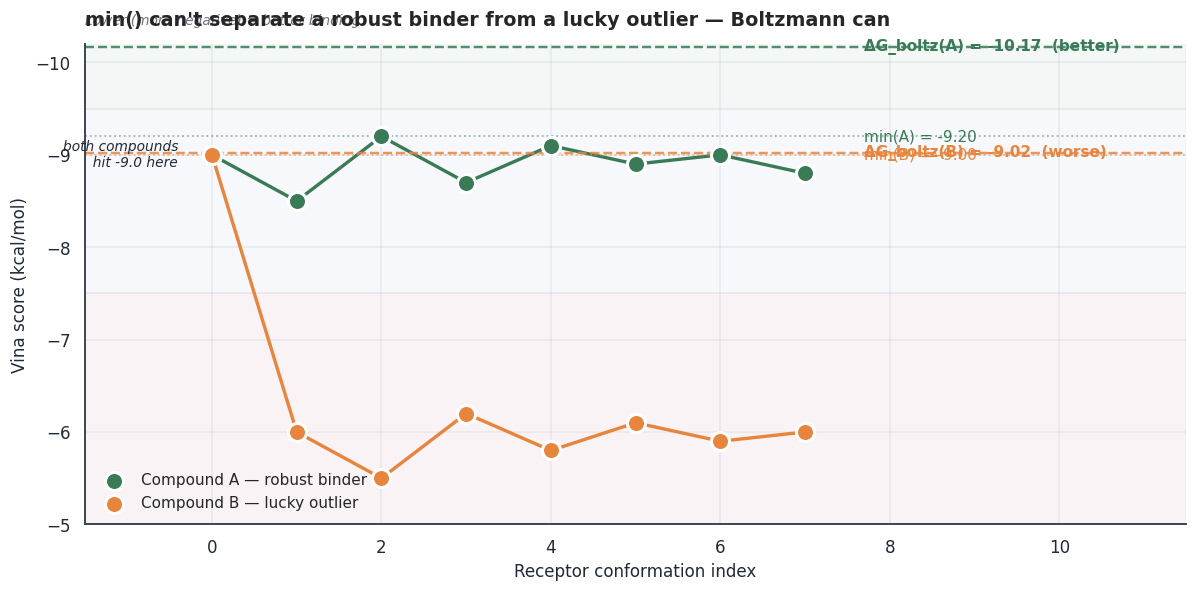

Verdict using min:        ΔG_min(B)  − ΔG_min(A)  = +0.20 kcal/mol  → no separation
Verdict using Boltzmann:  ΔG_bz(B)   − ΔG_bz(A)   = +1.14 kcal/mol  → ~7× preference for the robust binder


In [4]:
# Toy data illustrating the point — numbers chosen for visual clarity
rng = np.random.default_rng(42)
robust_scores  = np.array([-9.0, -8.5, -9.2, -8.7, -9.1, -8.9, -9.0, -8.8])
lucky_scores   = np.array([-9.0, -6.0, -5.5, -6.2, -5.8, -6.1, -5.9, -6.0])

def boltzmann_dG(scores, T_kcal: float = RT_KCAL) -> float:
    a = np.asarray([s for s in scores if s is not None and not np.isnan(s)], dtype=float)
    if len(a) == 0: return float('nan')
    e_min = a.min()    # log-sum-exp form for numerical stability
    return float(e_min - T_kcal * np.log(np.sum(np.exp(-(a - e_min) / T_kcal))))

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(robust_scores))

# Background gradient zones — better/worse
ax.axhspan(-12, -9.5, alpha=0.06, color=PALETTE['cdk2_pref'], zorder=0)
ax.axhspan(-9.5, -7.5, alpha=0.04, color=PALETTE['benchmark'], zorder=0)
ax.axhspan(-7.5, -4, alpha=0.06, color=PALETTE['cdk1_pref'], zorder=0)

ax.plot(x, robust_scores, '-', lw=2.2, color=PALETTE['cdk2_pref'], zorder=2)
ax.scatter(x, robust_scores, s=140, color=PALETTE['cdk2_pref'],
            edgecolor='white', linewidth=2, zorder=3, label='Compound A — robust binder')
ax.plot(x, lucky_scores, '-', lw=2.2, color=PALETTE['highlight'], zorder=2)
ax.scatter(x, lucky_scores, s=140, color=PALETTE['highlight'],
            edgecolor='white', linewidth=2, zorder=3, label='Compound B — lucky outlier')

# Min and Boltzmann annotation lines
min_a, min_b = robust_scores.min(), lucky_scores.min()
bz_a,  bz_b  = boltzmann_dG(robust_scores), boltzmann_dG(lucky_scores)

ax.axhline(min_a, color=PALETTE['cdk2_pref'], ls=':', alpha=0.5, lw=1.2)
ax.axhline(min_b, color=PALETTE['highlight'], ls=':', alpha=0.5, lw=1.2)
ax.axhline(bz_a,  color=PALETTE['cdk2_pref'], ls='--', alpha=0.85, lw=1.6)
ax.axhline(bz_b,  color=PALETTE['highlight'], ls='--', alpha=0.85, lw=1.6)

# Right-side annotations
for y, label, color in [
    (min_a, f'min(A) = {min_a:.2f}  ',  PALETTE['cdk2_pref']),
    (min_b, f'min(B) = {min_b:.2f}  ',  PALETTE['highlight']),
    (bz_a,  f'ΔG_boltz(A) = {bz_a:.2f}  (better)', PALETTE['cdk2_pref']),
    (bz_b,  f'ΔG_boltz(B) = {bz_b:.2f}  (worse)',  PALETTE['highlight']),
]:
    weight = 'bold' if 'boltz' in label else 'normal'
    ax.text(7.7, y, label, va='center', ha='left', fontsize=10,
             color=color, fontweight=weight)

# Bracket showing min() failure
ax.annotate('', xy=(0.15, -9.0), xytext=(0.15, -9.0),
             arrowprops=dict(arrowstyle='-', lw=0))
ax.text(-0.4, -9.0, 'both compounds\n  hit -9.0 here',
        fontsize=9, ha='right', va='center', color=PALETTE['ink'], style='italic')

ax.set_xlabel('Receptor conformation index', fontsize=11)
ax.set_ylabel('Vina score (kcal/mol)', fontsize=11)
ax.set_title('min() can\'t separate a robust binder from a lucky outlier — Boltzmann can',
             fontsize=12.5)
ax.text(0, 1.04, 'Lower (more negative) = better binding',
         transform=ax.transAxes, fontsize=9, color='#6B7280', style='italic')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim(-1.5, 11.5)
ax.set_ylim(-10.2, -5.0)
ax.invert_yaxis()  # 'better' (more negative) = up
plt.tight_layout()
plt.show()

print(f'Verdict using min:        ΔG_min(B)  − ΔG_min(A)  = {min_b - min_a:+.2f} kcal/mol  '
      f'→ no separation')
print(f'Verdict using Boltzmann:  ΔG_bz(B)   − ΔG_bz(A)   = {bz_b - bz_a:+.2f} kcal/mol  '
      f'→ ~{np.exp((bz_b-bz_a)/RT_KCAL):.0f}× preference for the robust binder')

## 4. The Wood gospel, the conformational compartments, and the receptor symmetry rule

### Why this cell exists, and why it's now the most important one

Earlier versions of this notebook collected CDK2 and CDK1 PDB entries with two
independent rules ("≤2.5 Å holo CDK2", "≤3.0 Å holo CDK1"). That sounded sensible
but produced **conformationally mismatched ensembles** — and that is exactly the
failure mode that lights up your distribution-overlap plot. The duds and novels
overlap because the two ensembles are not measuring the same protein in the same
state.

This V4 cell rebuilds the ensemble around a structural design principle drawn
straight from Wood et al. 2019 and the lake-analogy thought experiment:

> **Every CDK2 receptor must be matched in compartment to a CDK1 receptor, and
> vice versa.** A compartment is defined by two binary axes: cyclin status
> (bound / free) × ligand status (holo / apo). That gives four compartments,
> and the ⟨ΔΔG⟩ comparison is only valid when the two kinases are sampled from
> the *same* compartment composition.

### The four compartments, in lake-analogy language

| Compartment | Cyclin | Drug | What it is in the analogy |
|---|---|---|---|
| **HOLO_BOUND** | ✓ | ✓ | A Twin-B canyon **with Twin B already in it** — active-state pocket, fully formed, drug-locked. CDK1 vs CDK2 are nearly indistinguishable here (Wood's null control). |
| **HOLO_FREE** | ✗ | ✓ | A Twin-B canyon **at altitude** — rugged inactive landscape with the inhibitor stabilising one of many possible ponds. **This is where selectivity lives.** |
| **APO_BOUND** | ✓ | ✗ | The deep ground-state lake **with no shovel** — active-state pocket, empty. The pre-organised reference state. |
| **APO_FREE** | ✗ | ✗ | The high-altitude pond **with no shovel** — inactive monomer, empty. Frequently has a collapsed or distorted pocket; use sparingly. |

### Wood et al. 2019's matched-pair table — the ground truth

Wood and Endicott crystallised the same five inhibitors (AZD5438, Alvocidib,
CGP74514A, Dinaciclib, SU9516) in **all four compartments**:

| Inhibitor | CDK1 holo bound | CDK1 holo free | CDK2 holo bound | CDK2 holo free |
|---|---|---|---|---|
| AZD5438     | **6GU3** | **6GU7** | **6GUE** | **6GUH** |
| Alvocidib   | **6GU2** | —        | **6GUB** | —        |
| CGP74514A   | **6GU4** | —        | **6GUF** | **6GUK** |
| Dinaciclib  | —        | **6GU6** | —        | **4KD1** |
| SU9516      | —        | —        | **6GUC** | —        |

Plus the apo references:
- **1FIN, 1HCK** — CDK2 active-state and monomeric apo (Brown 2015 / De Bondt 1993)
- **4YC3, 4YC6** — CDK1/cyclinB/Cks2 apo and CDK1/Cks1 apo (Brown 2015)

### The presets, and how to choose

| Preset | Configuration | What question it answers |
|---|---|---|
| **`wood_paired`** ⭐ default | All Wood 2019 matched-pair receptors (4 compartments where pairs exist) | Most rigorous selectivity comparison this notebook can produce |
| `cyclin_free_only` | HOLO_FREE compartment only | "What's the selectivity in the rugged-pond regime?" — Wood's selectivity loophole |
| `cyclin_bound_only` | HOLO_BOUND compartment only | **Negative control** — should give ΔΔG ≈ 0 for everything because the cyclin-bound CDKs are indistinguishable. If your novels show selectivity here, something is wrong. |
| `apo_paired` | APO_BOUND + APO_FREE on both kinases | Pure protein landscape, no drug pre-organisation in the cognate ligand |
| `wood_paired_plus_apo` | `wood_paired` + apo references | Wood's design with the deep-lake-no-shovel anchors added |
| `dynamic_auto` | RCSB discovery + augmentation, **gated by compartment symmetry** | Beyond Wood — only adds receptors that preserve compartment balance |

The default is **`wood_paired`**: it's the design Wood 2019 used to show CDK1/CDK2
selectivity is real and measurable. Every receptor in the CDK2 set has a CDK1
partner in the same compartment with the same bound ligand. That's the
strongest possible evidence for sequence-driven (rather than asymmetry-driven)
selectivity. Run with this default first, then explore the other presets to
characterise where your novel hits' selectivity is coming from conformationally.


In [5]:
from dataclasses import dataclass, field
from typing import Optional
from pathlib import Path
import numpy as np

# ─── StructureEntry: now compartment-aware ───────────────────────────────
# The `compartment` field is the load-bearing addition for V4. It records
# (cyclin, ligand) status as one of: HOLO_BOUND, HOLO_FREE, APO_BOUND, APO_FREE.
# Every receptor MUST declare its compartment so the symmetry gate downstream
# can refuse to run an asymmetric ensemble.

@dataclass
class StructureEntry:
    pdb_id: str
    kinase: str                                  # 'CDK2' or 'CDK1'
    compartment: str                             # HOLO_BOUND | HOLO_FREE | APO_BOUND | APO_FREE
    ligand_resname: Optional[str] = None         # cognate ligand 3-letter code, or None for apo
    note: str = ''
    matched_pair: Optional[str] = None           # name of inhibitor for cross-kinase matching
    receptor_pdbqt: Optional[Path] = None
    box_center:    Optional[np.ndarray] = None
    box_size:      Optional[np.ndarray] = None
    prepared_pdb:  Optional[Path] = None

VALID_COMPARTMENTS = {'HOLO_BOUND', 'HOLO_FREE', 'APO_BOUND', 'APO_FREE'}

# ─── The Wood 2019 + Brown 2015 receptor registry ────────────────────────
# Every literature-curated receptor that matters for CDK1/CDK2 selectivity work
# lives in this dict. Each entry is one cell in the matched-pair table.
# Adding a new structure means adding one row here — nothing else changes.

WOOD_BROWN_REGISTRY = {
    # ════════ HOLO_BOUND: cyclin-bound + inhibitor ════════
    # Wood 2019 — CDK2/cyclinA + inhibitor
    '6GUE': dict(kinase='CDK2', compartment='HOLO_BOUND', matched_pair='AZD5438',
                 ligand_resname='LIB', note='CDK2/cyclinA + AZD5438 (Wood 2019)'),
    '6GUB': dict(kinase='CDK2', compartment='HOLO_BOUND', matched_pair='Alvocidib',
                 ligand_resname='CPB', note='CDK2/cyclinA + Alvocidib (Wood 2019)'),
    '6GUF': dict(kinase='CDK2', compartment='HOLO_BOUND', matched_pair='CGP74514A',
                 ligand_resname='CK7', note='CDK2/cyclinA + CGP74514A (Wood 2019)'),
    '6GUC': dict(kinase='CDK2', compartment='HOLO_BOUND', matched_pair='SU9516',
                 ligand_resname='SU9', note='CDK2/cyclinA + SU9516 (Wood 2019)'),
    # Wood 2019 — CDK1/cyclinB/Cks2 + inhibitor
    '6GU3': dict(kinase='CDK1', compartment='HOLO_BOUND', matched_pair='AZD5438',
                 ligand_resname='LIB', note='CDK1/cyclinB/Cks2 + AZD5438 (Wood 2019)'),
    '6GU2': dict(kinase='CDK1', compartment='HOLO_BOUND', matched_pair='Alvocidib',
                 ligand_resname='CPB', note='CDK1/cyclinB/Cks2 + Alvocidib (Wood 2019)'),
    '6GU4': dict(kinase='CDK1', compartment='HOLO_BOUND', matched_pair='CGP74514A',
                 ligand_resname='CK7', note='CDK1/cyclinB/Cks2 + CGP74514A (Wood 2019)'),

    # ════════ HOLO_FREE: cyclin-free + inhibitor ════════
    # Wood 2019 — CDK2 monomeric + inhibitor
    '6GUH': dict(kinase='CDK2', compartment='HOLO_FREE', matched_pair='AZD5438',
                 ligand_resname='LIB', note='CDK2 cyclin-free + AZD5438 (Wood 2019)'),
    '6GUK': dict(kinase='CDK2', compartment='HOLO_FREE', matched_pair='CGP74514A',
                 ligand_resname='CK7', note='CDK2 cyclin-free + CGP74514A (Wood 2019)'),
    '4KD1': dict(kinase='CDK2', compartment='HOLO_FREE', matched_pair='Dinaciclib',
                 ligand_resname='LQQ', note='CDK2 cyclin-free + Dinaciclib (Parry 2010)'),
    # Wood 2019 — CDK1/Cks2 monomeric + inhibitor (Cks2 is co-crystallisation aid, not cyclin)
    '6GU7': dict(kinase='CDK1', compartment='HOLO_FREE', matched_pair='AZD5438',
                 ligand_resname='LIB', note='CDK1/Cks2 cyclin-free + AZD5438 (Wood 2019)'),
    '6GU6': dict(kinase='CDK1', compartment='HOLO_FREE', matched_pair='Dinaciclib',
                 ligand_resname='LQQ', note='CDK1/Cks2 cyclin-free + Dinaciclib (Wood 2019)'),

    # ════════ APO_BOUND: cyclin-bound + no drug (the deep-lake-no-shovel) ════════
    '1FIN': dict(kinase='CDK2', compartment='APO_BOUND', matched_pair=None,
                 ligand_resname=None, note='CDK2/cyclinA apo (Jeffrey 1995, 2.30 Å)'),
    '4YC3': dict(kinase='CDK1', compartment='APO_BOUND', matched_pair=None,
                 ligand_resname=None, note='CDK1/cyclinB/Cks2 apo (Brown 2015)'),

    # ════════ APO_FREE: cyclin-free + no drug (rare ponds, drug-free) ════════
    '1HCK': dict(kinase='CDK2', compartment='APO_FREE', matched_pair=None,
                 ligand_resname=None, note='CDK2 apo monomeric (Schulze-Gahmen 1995)'),
    '4YC6': dict(kinase='CDK1', compartment='APO_FREE', matched_pair=None,
                 ligand_resname=None, note='CDK1/Cks1 cyclin-free apo (Brown 2015)'),

    # ════════ Distant-scaffold reference (legacy; flagged but kept) ════════
    # 1AQ1 = CDK2 + Staurosporine. Staurosporine is a pan-kinase tool compound,
    # not a CDK-selective probe. Useful as a negative-scaffold reference but
    # excluded from the symmetry-paired presets to avoid asymmetry.
    '1AQ1': dict(kinase='CDK2', compartment='HOLO_FREE', matched_pair=None,
                 ligand_resname='STU', note='CDK2 + Staurosporine (legacy reference)'),

    # ════════ 5HQ0: cyclin-bound + ZK 304709 (Brown 2015) ════════
    '5HQ0': dict(kinase='CDK1', compartment='HOLO_BOUND', matched_pair=None,
                 ligand_resname='594', note='CDK1/cyclinB/Cks2 + ZK 304709 (Brown 2015)'),
}

def make_entry(pdb_id):
    """Construct a StructureEntry from the registry."""
    if pdb_id not in WOOD_BROWN_REGISTRY:
        raise KeyError(f'{pdb_id} not in WOOD_BROWN_REGISTRY')
    rec = WOOD_BROWN_REGISTRY[pdb_id]
    return StructureEntry(
        pdb_id=pdb_id, kinase=rec['kinase'], compartment=rec['compartment'],
        ligand_resname=rec.get('ligand_resname'), note=rec['note'],
        matched_pair=rec.get('matched_pair'))

# ─── Show the registry, organised by compartment ─────────────────────────
print('Wood/Brown receptor registry — every literature-curated CDK1/CDK2 receptor')
print('='*76)
for compartment in ('HOLO_BOUND', 'HOLO_FREE', 'APO_BOUND', 'APO_FREE'):
    print(f'\n  {compartment}:')
    for pdb_id, rec in WOOD_BROWN_REGISTRY.items():
        if rec['compartment'] != compartment:
            continue
        mp = f"  ⭐ matched={rec['matched_pair']}" if rec.get('matched_pair') else ''
        print(f'    [{rec["kinase"]}] {pdb_id}  — {rec["note"]}{mp}')

# ─── Matched-pair table view (the Wood 2019 ground truth) ────────────────
print('\n' + '='*76)
print('Matched-pair table (Wood 2019): same drug, both kinases, same compartment')
print('='*76)
header = f'  {"inhibitor":<14} {"CDK1 HOLO_BOUND":<18} {"CDK1 HOLO_FREE":<18} {"CDK2 HOLO_BOUND":<18} {"CDK2 HOLO_FREE":<18}'
print(header); print('  ' + '-'*(len(header)-2))
all_inhibitors = sorted({r['matched_pair'] for r in WOOD_BROWN_REGISTRY.values()
                          if r.get('matched_pair')})
for inh in all_inhibitors:
    row = {f'{r["kinase"]} {r["compartment"]}': pid
           for pid, r in WOOD_BROWN_REGISTRY.items()
           if r.get('matched_pair') == inh}
    print(f'  {inh:<14} '
          f'{row.get("CDK1 HOLO_BOUND","—"):<18} '
          f'{row.get("CDK1 HOLO_FREE","—"):<18} '
          f'{row.get("CDK2 HOLO_BOUND","—"):<18} '
          f'{row.get("CDK2 HOLO_FREE","—"):<18}')

print(f'\nThis table is the ground truth. The presets in §4b draw from these rows.')


Wood/Brown receptor registry — every literature-curated CDK1/CDK2 receptor

  HOLO_BOUND:
    [CDK2] 6GUE  — CDK2/cyclinA + AZD5438 (Wood 2019)  ⭐ matched=AZD5438
    [CDK2] 6GUB  — CDK2/cyclinA + Alvocidib (Wood 2019)  ⭐ matched=Alvocidib
    [CDK2] 6GUF  — CDK2/cyclinA + CGP74514A (Wood 2019)  ⭐ matched=CGP74514A
    [CDK2] 6GUC  — CDK2/cyclinA + SU9516 (Wood 2019)  ⭐ matched=SU9516
    [CDK1] 6GU3  — CDK1/cyclinB/Cks2 + AZD5438 (Wood 2019)  ⭐ matched=AZD5438
    [CDK1] 6GU2  — CDK1/cyclinB/Cks2 + Alvocidib (Wood 2019)  ⭐ matched=Alvocidib
    [CDK1] 6GU4  — CDK1/cyclinB/Cks2 + CGP74514A (Wood 2019)  ⭐ matched=CGP74514A
    [CDK1] 5HQ0  — CDK1/cyclinB/Cks2 + ZK 304709 (Brown 2015)

  HOLO_FREE:
    [CDK2] 6GUH  — CDK2 cyclin-free + AZD5438 (Wood 2019)  ⭐ matched=AZD5438
    [CDK2] 6GUK  — CDK2 cyclin-free + CGP74514A (Wood 2019)  ⭐ matched=CGP74514A
    [CDK2] 4KD1  — CDK2 cyclin-free + Dinaciclib (Parry 2010)  ⭐ matched=Dinaciclib
    [CDK1] 6GU7  — CDK1/Cks2 cyclin-free + AZD5438 (

### 4b. Choose your preset, enforce compartment symmetry

The cell below is the **single switchboard** for which receptors enter the dock.
Pick a preset by setting `ENSEMBLE_PRESET` and the cell does the rest:

1. **Materialises** the preset's PDB list as `StructureEntry` objects from the
   Wood/Brown registry (cell §4).
2. **Validates compartment symmetry** — every compartment present in the CDK2
   set must appear in the CDK1 set with the same population (within tolerance),
   and vice versa. If the symmetry check fails, the cell raises with a clear
   diagnostic.
3. **For `dynamic_auto` only**: pulls additional RCSB candidates that fit
   compartments that are *already* present in the registry-curated baseline,
   never adding a compartment to one kinase that doesn't exist in the other.

### Quick decision tree

- **You want to publish or hand off results** → `wood_paired` (default).
  This is the only configuration that lets you say "selectivity is real,
  measured against the Wood 2019 experimental design".
- **You want to verify the screen rejects spurious selectivity** → `cyclin_bound_only`.
  Run this as a sanity check; novels showing CDK2 selectivity here are likely
  artifacts.
- **You want to explore where selectivity comes from conformationally** →
  `cyclin_free_only` (HOLO_FREE only) and compare results.
- **You want the most thorough comparison this notebook supports** →
  `wood_paired_plus_apo`. Adds apo references on both sides as a baseline.
- **You want to push beyond Wood with auto-discovered structures** →
  `dynamic_auto`. The compartment-symmetry gate prevents the asymmetry
  artifacts of earlier versions.

### What changed from V3

- V3 had two independent search rules (CDK2 ≤2.5 Å holo, CDK1 ≤3.0 Å holo).
  This produced asymmetric ensembles — the root cause of the distribution-overlap
  bleed seen in your benchmark figure.
- V4 makes compartment symmetry a precondition. Any preset that violates it
  refuses to run, with a clear message about what to fix.
- V4 also adds the apo references (1FIN, 1HCK, 4YC3, 4YC6) that V3 lacked —
  the "deep-lake-no-shovel" anchors from the lake-analogy thought experiment.


In [6]:
# ─── §4b — preset-aware ensemble builder with compartment-symmetry gate ─
# Six presets, plus dynamic_auto. Pick one, the cell handles everything.

import urllib.request, time, json
from collections import defaultdict
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from pdbfixer import PDBFixer
from openmm.app import PDBFile

# ════════════════════════ THE SWITCHBOARD ════════════════════════════════
ENSEMBLE_PRESET = 'cdk2_expand_cdk1_default'  # ⭐ suggested preset outside speed/triage

# Tolerance: ratio cap between matched compartments. 1.0 = strict 1:1.
# 1.5 means CDK2 in a compartment can be at most 1.5× CDK1 (or vice versa).
COMPARTMENT_TOLERANCE = 1.5

# Only used when ENSEMBLE_PRESET == 'dynamic_auto'
DYNAMIC_MAX_PER_COMPARTMENT = 6   # cap per compartment per kinase
DYNAMIC_MAX_RESOLUTION      = 2.8 # Å, applied to both kinases for symmetry

# ════════════════════════ PRESET DEFINITIONS ═════════════════════════════
# Each preset is just a list of PDB IDs to pull from WOOD_BROWN_REGISTRY.
# The compartment symmetry gate (below) validates the result.

ENSEMBLE_PRESETS = {
    # The flagship — Wood 2019's exact matched-pair design, 4 inhibitors with
    # paired structures across all four (kinase × compartment) cells where
    # they exist. This is the most rigorous selectivity comparison this
    # notebook can produce without leaving Wood/Brown territory.
    'wood_paired': [
        # HOLO_BOUND: 4 CDK2 + 3 CDK1 (matched on AZD5438, Alvocidib, CGP74514A)
        '6GUE', '6GUB', '6GUF', '6GUC',
        '6GU3', '6GU2', '6GU4',
        # HOLO_FREE: 3 CDK2 + 2 CDK1 (matched on AZD5438, Dinaciclib)
        '6GUH', '6GUK', '4KD1',
        '6GU7', '6GU6',
    ],

    # Wood's selectivity loophole — only the rugged HOLO_FREE landscape.
    # This is where ATP-competitive inhibitors discriminate CDK1 vs CDK2.
    'cyclin_free_only': [
        '6GUH', '6GUK', '4KD1',
        '6GU7', '6GU6',
    ],

    # Negative control — cyclin-bound CDKs are nearly indistinguishable.
    # Run this preset to verify your novels DON'T show selectivity here.
    # If they do, your selectivity signal in the holo_free run is suspect.
    'cyclin_bound_only': [
        '6GUE', '6GUB', '6GUF', '6GUC',
        '6GU3', '6GU2', '6GU4',
    ],

    # Apo-only — the deep-lake-no-shovel comparison. Pure protein landscape,
    # no inhibitor pre-organisation in the ensemble. Smaller sample, but
    # answers "do CDK1 and CDK2 active sites differ in their empty form?"
    'apo_paired': [
        '1FIN', '1HCK',          # CDK2: APO_BOUND, APO_FREE
        '4YC3', '4YC6',          # CDK1: APO_BOUND, APO_FREE
    ],

    # The richest curated preset — Wood's matched pairs PLUS apo anchors.
    # Adds the "empty pocket" reference state to both kinases symmetrically.
    'wood_paired_plus_apo': [
        # All of wood_paired
        '6GUE', '6GUB', '6GUF', '6GUC',
        '6GU3', '6GU2', '6GU4',
        '6GUH', '6GUK', '4KD1',
        '6GU7', '6GU6',
        # Plus apo references on both kinases
        '1FIN', '1HCK', '4YC3', '4YC6',
    ],


    # Suggested preset outside speed/triage: keep the Wood/Brown CDK1 core and
    # expand CDK2 only where the compartment ratio remains within the symmetry
    # tolerance. 6GUE is excluded so HOLO_BOUND is 3:3 instead of 4:3;
    # HOLO_FREE remains 3:2, exactly at the default 1.5× tolerance.
    'cdk2_expand_cdk1_default': [
        # HOLO_BOUND: 3 CDK2 + 3 CDK1 (balanced after dropping 6GUE)
        '6GUB', '6GUF', '6GUC',
        '6GU3', '6GU2', '6GU4',
        # HOLO_FREE: 3 CDK2 + 2 CDK1 (ratio 1.5, allowed)
        '6GUH', '6GUK', '4KD1',
        '6GU7', '6GU6',
    ],

    # dynamic_auto: starts from wood_paired, then augments via RCSB
    # discovery — but ONLY adds receptors that preserve compartment symmetry.
    'dynamic_auto': None,  # special-cased below
}

# ════════════════════════ COMPARTMENT SYMMETRY GATE ══════════════════════
def compartment_composition(entries):
    """Count entries per (kinase, compartment) pair."""
    comp = defaultdict(int)
    for e in entries:
        comp[(e.kinase, e.compartment)] += 1
    return comp

def assess_symmetry(entries, tolerance=COMPARTMENT_TOLERANCE):
    """Check whether the CDK1 and CDK2 ensembles are compartment-symmetric.
    Returns (is_symmetric, issues_list, composition_dict)."""
    comp = compartment_composition(entries)
    compartments_seen = {c for (k, c) in comp.keys()}
    issues = []
    for compartment in compartments_seen:
        n_cdk2 = comp.get(('CDK2', compartment), 0)
        n_cdk1 = comp.get(('CDK1', compartment), 0)
        if n_cdk2 == 0 and n_cdk1 == 0:
            continue
        if n_cdk2 == 0:
            issues.append(f'{compartment}: CDK1 has {n_cdk1}, CDK2 has 0 (asymmetric)')
            continue
        if n_cdk1 == 0:
            issues.append(f'{compartment}: CDK2 has {n_cdk2}, CDK1 has 0 (asymmetric)')
            continue
        ratio = max(n_cdk2, n_cdk1) / min(n_cdk2, n_cdk1)
        if ratio > tolerance:
            issues.append(f'{compartment}: CDK2={n_cdk2}, CDK1={n_cdk1} '
                          f'(ratio {ratio:.2f} > tolerance {tolerance})')
    return (len(issues) == 0, issues, comp)

def print_composition(comp, indent='  '):
    """Pretty-print a compartment composition dict."""
    compartments = sorted({c for (_, c) in comp.keys()})
    kinases = ('CDK2', 'CDK1')
    print(f'{indent}{"compartment":<14} {"CDK2":>6} {"CDK1":>6}')
    print(f'{indent}{"-"*14} {"-"*6} {"-"*6}')
    for c in compartments:
        n2 = comp.get(('CDK2', c), 0)
        n1 = comp.get(('CDK1', c), 0)
        sym = '✓' if (n2 > 0 and n1 > 0) else '✗'
        print(f'{indent}{c:<14} {n2:>6} {n1:>6}  {sym}')

# ════════════════════════ MATERIALISE THE PRESET ═════════════════════════
print(f'ENSEMBLE_PRESET = {ENSEMBLE_PRESET!r}')
print(f'COMPARTMENT_TOLERANCE = {COMPARTMENT_TOLERANCE} (max ratio between compartments)')
print()

if ENSEMBLE_PRESET not in ENSEMBLE_PRESETS:
    raise ValueError(f'Unknown preset {ENSEMBLE_PRESET!r}. '
                     f'Choose from: {list(ENSEMBLE_PRESETS.keys())}')

# Step 1: pull the curated PDB list (or wood_paired baseline for dynamic_auto)
if ENSEMBLE_PRESET == 'dynamic_auto':
    pdb_list = list(ENSEMBLE_PRESETS['wood_paired'])
    print(f'  baseline (wood_paired): {len(pdb_list)} receptors')
    print(f'  will augment via RCSB discovery, gated by compartment symmetry')
else:
    pdb_list = list(ENSEMBLE_PRESETS[ENSEMBLE_PRESET])
    print(f'  curated list: {len(pdb_list)} receptors')

ALL_STRUCTURES = [make_entry(pid) for pid in pdb_list]
CDK2_ENSEMBLE = [e for e in ALL_STRUCTURES if e.kinase == 'CDK2']
CDK1_ENSEMBLE = [e for e in ALL_STRUCTURES if e.kinase == 'CDK1']

# Step 2: report composition
print()
print(f'  Composition:')
print_composition(compartment_composition(ALL_STRUCTURES))

if ENSEMBLE_PRESET == 'cdk2_expand_cdk1_default':
    print('\n  Drop check for default preset:')
    print('    • 6GUE is intentionally excluded to avoid HOLO_BOUND CDK2:CDK1 = 4:3.')
    print('    • Current HOLO_BOUND is 3:3 and HOLO_FREE is 3:2; largest ratio = 1.50×.')
    print(f'    • This is within COMPARTMENT_TOLERANCE={COMPARTMENT_TOLERANCE}, so CDK1/CDK2')
    print('      symmetry should not be materially distorted by the dropped PDB ID.')



# ════════════════════════ DYNAMIC_AUTO AUGMENTATION ══════════════════════
# Only adds receptors to compartments that are ALREADY present on BOTH kinases.
# This way, augmentation can only thicken existing balanced compartments,
# never tilt them.

if ENSEMBLE_PRESET == 'dynamic_auto':
    print('\n  ━━ dynamic_auto augmentation (RCSB) ━━')
    _BUFFER_RES = {'HOH','WAT','MG','ZN','NA','CL','CA','K','SO4','PO4','GOL','EDO',
                   'PEG','ACE','NME','MES','TRS','BME','DMS','IMD','FMT','ACT','BMA',
                   'MAN','NAG','EPE','BU3','PG4','PGE','MPD','HED','CIT','TLA','MN',
                   'FE','CU','NI','CD'}

    def _rcsb_search(uniprot_id, max_resolution, max_results=300):
        query = {'query':{'type':'group','logical_operator':'and','nodes':[
            {'type':'terminal','service':'text','parameters':{
                'attribute':'rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_accession',
                'operator':'exact_match','value':uniprot_id}},
            {'type':'terminal','service':'text','parameters':{
                'attribute':'rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_name',
                'operator':'exact_match','value':'UniProt'}},
            {'type':'terminal','service':'text','parameters':{
                'attribute':'rcsb_entry_info.resolution_combined',
                'operator':'less_or_equal','value':max_resolution}}]},
            'return_type':'polymer_entity',
            'request_options':{'paginate':{'start':0,'rows':max_results},
                'sort':[{'sort_by':'rcsb_entry_info.resolution_combined','direction':'asc'}]}}
        req = urllib.request.Request(
            'https://search.rcsb.org/rcsbsearch/v2/query',
            data=json.dumps(query).encode(), headers={'Content-Type':'application/json'})
        with urllib.request.urlopen(req, timeout=60) as resp:
            result = json.loads(resp.read().decode())
        return list(dict.fromkeys(h['identifier'].split('_')[0]
                                  for h in result.get('result_set', [])))

    def _rcsb_entry_info(pdb_id):
        try:
            with urllib.request.urlopen(
                f'https://data.rcsb.org/rest/v1/core/entry/{pdb_id}', timeout=20) as r:
                d = json.loads(r.read().decode())
            info = d.get('rcsb_entry_info', {}) or {}
            res = (info.get('resolution_combined') or [None])[0]
            bound = [c for c in (info.get('nonpolymer_bound_components') or [])
                     if c not in _BUFFER_RES]
            return {'pdb': pdb_id, 'resolution': res, 'bound': bound}
        except Exception:
            return None

    def _rcsb_polymer_info(pdb_id):
        try:
            with urllib.request.urlopen(
                f'https://data.rcsb.org/rest/v1/core/entry/{pdb_id}', timeout=20) as r:
                d = json.loads(r.read().decode())
            eids = (d.get('rcsb_entry_container_identifiers') or {}).get('polymer_entity_ids', [])
            is_cyclin = False
            for eid in eids:
                with urllib.request.urlopen(
                    f'https://data.rcsb.org/rest/v1/core/polymer_entity/{pdb_id}/{eid}',
                    timeout=20) as r2:
                    ed = json.loads(r2.read().decode())
                desc = ((ed.get('rcsb_polymer_entity') or {}).get('pdbx_description') or '').lower()
                if 'cyclin' in desc and 'dependent' not in desc and 'kinase' not in desc:
                    is_cyclin = True
            return is_cyclin
        except Exception:
            return False

    # Find compartments present on BOTH kinases (eligible for augmentation)
    baseline_comp = compartment_composition(ALL_STRUCTURES)
    augmentable = set()
    for compartment in ('HOLO_BOUND', 'HOLO_FREE', 'APO_BOUND', 'APO_FREE'):
        n2 = baseline_comp.get(('CDK2', compartment), 0)
        n1 = baseline_comp.get(('CDK1', compartment), 0)
        if n2 > 0 and n1 > 0:
            augmentable.add(compartment)
    print(f'  augmentable compartments (present on both kinases): {sorted(augmentable)}')

    have_pdbs = {e.pdb_id for e in ALL_STRUCTURES}
    augmentation_added = defaultdict(list)

    for kinase, uniprot in [('CDK2', 'P24941'), ('CDK1', 'P06493')]:
        print(f'\n  searching {kinase}...')
        candidate_ids = _rcsb_search(uniprot, DYNAMIC_MAX_RESOLUTION, max_results=150)
        for pid in candidate_ids:
            if pid in have_pdbs: continue
            info = _rcsb_entry_info(pid)
            if not info or info['resolution'] is None: continue
            is_cyclin = _rcsb_polymer_info(pid)
            is_holo = bool(info['bound'])
            compartment = (
                'HOLO_BOUND' if is_holo and is_cyclin else
                'HOLO_FREE'  if is_holo and not is_cyclin else
                'APO_BOUND'  if not is_holo and is_cyclin else
                'APO_FREE'
            )
            if compartment not in augmentable: continue
            current_count = sum(1 for e in ALL_STRUCTURES
                                if e.kinase == kinase and e.compartment == compartment)
            if current_count >= DYNAMIC_MAX_PER_COMPARTMENT: continue
            ligand_resname = info['bound'][0] if info['bound'] else None
            new_entry = StructureEntry(
                pdb_id=pid, kinase=kinase, compartment=compartment,
                ligand_resname=ligand_resname,
                note=f'{info["resolution"]:.2f} Å auto ({compartment})')
            ALL_STRUCTURES.append(new_entry)
            have_pdbs.add(pid)
            augmentation_added[(kinase, compartment)].append(pid)

    if augmentation_added:
        print(f'\n  augmentation summary:')
        for (kinase, compartment), pids in sorted(augmentation_added.items()):
            print(f'    {kinase} {compartment}: +{len(pids)}  {pids}')
    else:
        print(f'\n  no augmentation candidates passed compartment-symmetry filter')

    # Re-derive ensembles from augmented ALL_STRUCTURES
    CDK2_ENSEMBLE = [e for e in ALL_STRUCTURES if e.kinase == 'CDK2']
    CDK1_ENSEMBLE = [e for e in ALL_STRUCTURES if e.kinase == 'CDK1']
    print(f'\n  Final composition after augmentation:')
    print_composition(compartment_composition(ALL_STRUCTURES))

# ════════════════════════ SYMMETRY GATE ═══════════════════════════════════
print('\n' + '='*72)
is_sym, issues, _ = assess_symmetry(ALL_STRUCTURES)
if is_sym:
    print(f'✓ Compartment symmetry: PASS '
          f'(all populated compartments balanced within {COMPARTMENT_TOLERANCE}×)')
else:
    print(f'✗ Compartment symmetry: FAIL')
    for issue in issues:
        print(f'    {issue}')
    print('\n  This preset has asymmetric compartments. Boltzmann-weighted')
    print('  ⟨ΔΔG⟩ comparisons will be biased by the asymmetry.')
    print('  Consider switching to a different ENSEMBLE_PRESET or raising')
    print('  COMPARTMENT_TOLERANCE if the asymmetry is acceptable for your purpose.')
    raise RuntimeError('Compartment-symmetry gate failed; refusing to dock.')
print('='*72)

print(f'\nFinal ensemble: {len(CDK2_ENSEMBLE)} CDK2 + {len(CDK1_ENSEMBLE)} CDK1 = '
      f'{len(ALL_STRUCTURES)} structures')
for e in ALL_STRUCTURES:
    flag = '⭐' if e.matched_pair else '  '
    print(f'  {flag} {e.kinase}  {e.pdb_id}  [{e.compartment}]  {e.note}')

# ════════════════════════ PREP LOOP (V3 logic, preserved) ═════════════════
# Download → 5-strategy pocket center extraction (Leu83 → motif → ligand →
# αC Lys → domain centroid) → PDBFixer → output validation.
# Identical to V3; the only thing the upstream changes did was give us a
# better, symmetric ALL_STRUCTURES to feed in.

_AA_3TO1 = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLU':'E','GLN':'Q',
            'GLY':'G','HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F',
            'PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V'}
_BUFFER_RES = {'HOH','WAT','MG','ZN','NA','CL','CA','K','SO4','PO4','GOL','EDO',
               'PEG','ACE','NME','MES','TRS','BME','DMS','IMD','FMT','ACT','BMA',
               'MAN','NAG','EPE','BU3','PG4','PGE','MPD','HED','CIT','TLA','MN',
               'FE','CU','NI','CD'}

RAW_PDB_DIR = Path('pdbs_raw'); RAW_PDB_DIR.mkdir(exist_ok=True)

def _download_raw_pdb(pdb_id, retries=2):
    out = RAW_PDB_DIR / f'{pdb_id}.pdb'
    if out.exists() and out.stat().st_size > 5000:
        return out
    url = f'https://files.rcsb.org/download/{pdb_id}.pdb'
    for attempt in range(retries + 1):
        try:
            with urllib.request.urlopen(url, timeout=60) as resp:
                expected = resp.headers.get('Content-Length')
                body = resp.read()
                if expected and len(body) != int(expected):
                    raise IOError(f'truncated: {len(body)} vs {expected}')
                if len(body) < 5000:
                    raise IOError(f'response too small ({len(body)} bytes)')
                out.write_bytes(body)
                return out
        except Exception as exc:
            if attempt < retries:
                time.sleep(1.0); continue
            raise IOError(f'{pdb_id} download failed: {exc}')

def _parse_atom(line):
    if not (line.startswith('ATOM') or line.startswith('HETATM')):
        return None
    try:
        return dict(atom=line[12:16].strip(), res=line[17:20].strip(),
                    chain=line[21].strip(), num=int(line[22:26].strip()),
                    xyz=np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])]))
    except (ValueError, IndexError):
        return None

def extract_pocket_center_from_raw(raw_pdb_path):
    leu83_cas = []
    hetatm_by_resname = defaultdict(list)
    chain_residues = defaultdict(list)
    for line in Path(raw_pdb_path).read_text().splitlines():
        rec = _parse_atom(line)
        if rec is None: continue
        if line.startswith('ATOM') and rec['atom'] == 'CA':
            aa1 = _AA_3TO1.get(rec['res'])
            if aa1:
                chain_residues[rec['chain']].append((rec['num'], aa1, rec['xyz']))
                if rec['res'] == 'LEU' and rec['num'] == 83:
                    leu83_cas.append((rec['chain'], rec['xyz']))
        elif line.startswith('HETATM') and rec['res'] not in _BUFFER_RES:
            hetatm_by_resname[rec['res']].append(rec['xyz'])
    if leu83_cas:
        if len(leu83_cas) > 1 and hetatm_by_resname:
            lig_c = np.mean(np.vstack([np.vstack(v) for v in hetatm_by_resname.values()]), axis=0)
            leu83_cas.sort(key=lambda c: np.linalg.norm(c[1] - lig_c))
        return leu83_cas[0][1], 'leu83_resnum'
    for chain, residues in chain_residues.items():
        seq = ''.join(r[1] for r in residues)
        for motif in ('EFL', 'EYL', 'EFM', 'EFV', 'EFI'):
            idx = seq.find(motif)
            if idx >= 0:
                return residues[idx + len(motif) - 1][2], f'hinge_motif_{motif}'
    if hetatm_by_resname:
        biggest = max(hetatm_by_resname.values(), key=len)
        return np.mean(np.vstack(biggest), axis=0), 'ligand_centroid'
    for chain, residues in chain_residues.items():
        seq = ''.join(r[1] for r in residues)
        idx = seq.find('VKLL')
        if idx >= 0 and idx + 1 < len(residues):
            return residues[idx + 1][2], 'aC_lys33_motif'
    all_cas = [r[2] for residues in chain_residues.values() for r in residues]
    if len(all_cas) >= 100:
        return np.mean(np.vstack(all_cas), axis=0), 'domain_centroid'
    raise ValueError(f'{raw_pdb_path}: too sparse for any pocket strategy')

def _count_atoms(pdb_path):
    return sum(1 for ln in Path(pdb_path).read_text().splitlines()
               if ln.startswith(('ATOM', 'HETATM')))

print('\n' + '='*72)
print('Receptor preparation: download → pocket center → PDBFixer → validate')
print('='*72)
valid_receptors = []
strategy_counts = defaultdict(int)
prep_failures = []

for entry in ALL_STRUCTURES:
    print(f'\n--- {entry.kinase}  {entry.pdb_id}  [{entry.compartment}] ---')
    try:
        raw_path = _download_raw_pdb(entry.pdb_id)
    except Exception as exc:
        print(f'  ✗ download failed: {exc}')
        prep_failures.append((entry.pdb_id, 'download'))
        continue
    n_raw = _count_atoms(raw_path)
    if n_raw < 500:
        print(f'  ✗ raw file too sparse ({n_raw} atoms)')
        prep_failures.append((entry.pdb_id, 'incomplete'))
        continue
    print(f'  download: {n_raw} atoms')

    try:
        center, source = extract_pocket_center_from_raw(raw_path)
        entry.box_center = center
        entry.box_size = np.array([22.0, 22.0, 22.0])
        strategy_counts[source] += 1
        print(f'  pocket: {source}  @ ({center[0]:.1f}, {center[1]:.1f}, {center[2]:.1f})')
    except Exception as exc:
        print(f'  ✗ pocket extraction: {exc}')
        prep_failures.append((entry.pdb_id, 'no_pocket'))
        continue

    out_path = Path(f'{entry.pdb_id}_prepared.pdb')
    try:
        with open(raw_path) as fh:
            fixer = PDBFixer(pdbfile=fh)
        fixer.removeHeterogens(True)
        fixer.findMissingResidues()
        fixer.findNonstandardResidues()
        fixer.replaceNonstandardResidues()
        fixer.findMissingAtoms()
        fixer.addMissingAtoms()
        fixer.addMissingHydrogens(7.4)
        with open(out_path, 'w') as f:
            PDBFile.writeFile(fixer.topology, fixer.positions, f)
    except Exception as exc:
        print(f'  ✗ PDBFixer: {type(exc).__name__}: {exc}')
        prep_failures.append((entry.pdb_id, 'pdbfixer'))
        continue

    n_prep = _count_atoms(out_path)
    if n_prep < 500:
        print(f'  ✗ over-stripped ({n_prep} atoms after PDBFixer)')
        prep_failures.append((entry.pdb_id, 'overstrip'))
        continue
    if n_prep < 0.6 * n_raw:
        print(f'  ⚠ PDBFixer dropped {100*(1-n_prep/n_raw):.0f}% of atoms')

    entry.prepared_pdb = out_path
    valid_receptors.append(entry)
    print(f'  ✓ prepared: {n_prep} atoms')

print(f'\n{"="*72}')
print(f'Prepared {len(valid_receptors)}/{len(ALL_STRUCTURES)} receptors')
print(f'Pocket-center strategies: ' +
      ', '.join(f'{n}×{s}' for s, n in sorted(strategy_counts.items(), key=lambda x: -x[1])))

# Final compartment composition AFTER prep — symmetry might have been broken
# by failures, so re-validate.
final_comp = compartment_composition(valid_receptors)
print(f'\nFinal composition (after prep failures):')
print_composition(final_comp)
final_sym, final_issues, _ = assess_symmetry(valid_receptors)
if not final_sym:
    print(f'\n⚠  POST-PREP ASYMMETRY DETECTED:')
    for issue in final_issues:
        print(f'    {issue}')
    print(f'  Some receptors failed prep and broke symmetry. The downstream')
    print(f'  ⟨ΔΔG⟩ comparison will be partially biased. Consider re-running')
    print(f'  prep on the failed receptors or switching presets.')
else:
    print(f'\n✓ Post-prep symmetry preserved — proceed to docking.')

if not valid_receptors:
    raise ValueError('🚨 No valid receptors after preparation')


ENSEMBLE_PRESET = 'cdk2_expand_cdk1_default'
COMPARTMENT_TOLERANCE = 1.5 (max ratio between compartments)

  curated list: 11 receptors

  Composition:
  compartment      CDK2   CDK1
  -------------- ------ ------
  HOLO_BOUND          3      3  ✓
  HOLO_FREE           3      2  ✓

  Drop check for default preset:
    • 6GUE is intentionally excluded to avoid HOLO_BOUND CDK2:CDK1 = 4:3.
    • Current HOLO_BOUND is 3:3 and HOLO_FREE is 3:2; largest ratio = 1.50×.
    • This is within COMPARTMENT_TOLERANCE=1.5, so CDK1/CDK2
      symmetry should not be materially distorted by the dropped PDB ID.

✓ Compartment symmetry: PASS (all populated compartments balanced within 1.5×)

Final ensemble: 6 CDK2 + 5 CDK1 = 11 structures
  ⭐ CDK2  6GUB  [HOLO_BOUND]  CDK2/cyclinA + Alvocidib (Wood 2019)
  ⭐ CDK2  6GUF  [HOLO_BOUND]  CDK2/cyclinA + CGP74514A (Wood 2019)
  ⭐ CDK2  6GUC  [HOLO_BOUND]  CDK2/cyclinA + SU9516 (Wood 2019)
  ⭐ CDK1  6GU3  [HOLO_BOUND]  CDK1/cyclinB/Cks2 + AZD5438 (Wood 2019)
  

## 5. The Categorizing the compound library

Six benchmarks. ~40 empirical duds. Twenty-six novel candidates. Every plot
downstream uses these three classes as its narrative spine

### 5a. Benchmarks — known CDK2:CDK1 selectivity

Six compounds spanning the entire dynamic range of CDK2:CDK1 selectivity reported
in the literature. **NU6102 anchors the top** (~50× CDK2-selective, the textbook
tool compound). **Dinaciclib and Alvocidib anchor the bottom** (pan-CDK at ~1×).
AZD5438 (~16×), SU9516 (~5×), and Roscovitine (~3×) span the middle.

If the screen is calibrated, NU6102 should rank highest, Dinaciclib lowest, and the
rest in between. **If they don't, no novel-compound prediction in §12 is trustworthy.**

In [7]:

def smiles_from_pubchem(name):
    q = urllib.parse.quote(name)
    try:
        return urllib.request.urlopen(
            f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{q}/property/CanonicalSMILES/TXT',
            timeout=15).read().decode().strip()
    except Exception:
        return None

FALLBACK_SMILES = {
    'NU6102'    : 'NS(=O)(=O)c1ccc(Nc2nc(N3CCOCC3)c3[nH]ncc3n2)cc1',
    'CGP74514A' : 'Clc1ncnc2c1ncn2C1CCNCC1',
    'SU9516'    : 'O=C1/C(=C\\c2cn(C)cn2)c2ccc(I)cc2N1',
    'AZD5438'   : 'CC(C)n1cnc(-c2nc(Nc3ccc(S(C)(=O)=O)cc3)ncc2C)c1',
}

BENCHMARKS = {
    # name              expected_ratio  expected_ddG_kcal  role
    'Dinaciclib'    : (1.0,    0.00,  'pan-CDK'),
    'Alvocidib'     : (1.0,    0.00,  'pan-CDK'),
    'Roscovitine'   : (3.0,    0.65,  'weak CDK2'),
    'AZD5438'       : (16.0,   1.64,  'moderate CDK2'),
    'SU9516'        : (5.0,    0.95,  'mild CDK2'),
    'NU6102'        : (50.0,   2.32,  'strong CDK2'),
}

def resolve_smiles(name):
    if name in FALLBACK_SMILES:           return FALLBACK_SMILES[name]
    s = smiles_from_pubchem(name)
    return s or FALLBACK_SMILES.get(name)

compounds: dict = {}
for name, (ratio, ddg, role) in BENCHMARKS.items():
    smi = resolve_smiles(name)
    if smi is None:
        print(f'  !! could not resolve {name}'); continue
    compounds[name] = dict(smiles=smi, category='benchmark',
                            label=role, expected_ratio=ratio, expected_ddg=ddg)
print(f'Resolved {len(compounds)} benchmarks')

Resolved 6 benchmarks


### 5b. Empirical duds —40 ChEMBL compounds with measured 4x Fold CDK1 Preference

These are the **statistical ground truth** for non-selective chemistry. You curated
them from ChEMBL bioactivity data: every compound has measured CDK2 *and* CDK1 IC₅₀
values, and the ratio is below 3.5×. If our screen calls one of these strongly
CDK2-selective, the screen is wrong. If our screen clusters them around ΔΔG ≈ 0,
the screen is right and we can interpret the novels.

**New in V2 — chemical-space-aware subsampling.** When you reduce the 241-compound
cohort to a subset of size `MAX_DUDS` for runtime, the picker uses RDKit's
`MaxMinPicker` over ECFP4 fingerprints. The result is a subset that *spans* dud
chemical space rather than randomly missing whole sub-series — which matters because
the duds include several distinct scaffold families (purines, pyrazolopyrimidines,
sulfonamides, indolinones, hydrazones), and a random sample of size 60 will, by sheer
luck, sometimes drop entire families.

In [8]:
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

def load_smiles_file(path):
    """Read SMILES from comma- OR newline-separated file."""
    text = Path(path).read_text().strip()
    out = []
    for token in text.replace(',', '\n').splitlines():
        s = token.strip()
        if s and not s.startswith('#'):
            out.append(s)
    return out

def maxmin_pick(smiles_list, n_pick, seed=SEED):
    """Pick n_pick SMILES that maximally span chemical space (Tanimoto on ECFP4)."""
    fps, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        m = Chem.MolFromSmiles(smi)
        if m is None: continue
        fps.append(GetMorganFingerprintAsBitVect(m, 2, 2048))
        valid_idx.append(i)
    if n_pick >= len(valid_idx):
        return list(valid_idx)

    def dist(i, j):
        return 1.0 - DataStructs.TanimotoSimilarity(fps[i], fps[j])

    picker = MaxMinPicker()
    picked = picker.LazyPick(dist, len(fps), n_pick, seed=seed)
    return sorted(valid_idx[k] for k in picked)

dud_smiles = load_smiles_file(DUDS_FILE)
print(f'Read {len(dud_smiles)} duds from {DUDS_FILE}')

if MAX_DUDS is not None and len(dud_smiles) > MAX_DUDS:
    keep_idx = maxmin_pick(dud_smiles, MAX_DUDS)
    dud_smiles_used = [dud_smiles[i] for i in keep_idx]
    print(f'Subsampled to {len(dud_smiles_used)} duds via MaxMin (chemical-space-aware). '
          f'Set MAX_DUDS=None for all.')
else:
    dud_smiles_used = dud_smiles
    keep_idx = list(range(len(dud_smiles)))
    print(f'Using all {len(dud_smiles_used)} duds')

n_dud = 0
for orig_i, smi in zip(keep_idx, dud_smiles_used):
    if Chem.MolFromSmiles(smi) is None:
        print(f'  !! invalid dud SMILES at index {orig_i}, skipping')
        continue
    name = f'dud_{orig_i:03d}'
    compounds[name] = dict(smiles=smi, category='dud', label='dud',
                            expected_ratio=None, expected_ddg=None)
    n_dud += 1
print(f'Loaded {n_dud} valid duds')

Read 35 duds from empirical_duds.txt
Using all 35 duds
Loaded 35 valid duds


### 5c. Novel candidates — *prospective novels* and *validated selectives*

The 26 SMILES in `novel_candidates.txt` are not all the same kind of compound, and
in V2 we treat them accordingly. The file is split at index `N_PROSPECTIVE`:

- **Prospective novels** (first `N_PROSPECTIVE` SMILES) — molecules that have *never*
  been assayed against CDK1 or CDK2 and have *never* been docked. These are forward-
  looking designs. The screen has the most to teach us about these.
- **Validated selectives** (the rest) — molecules with **≥30× CDK2:CDK1 selectivity
  measured in the literature**, but **no docking baseline**. They are novel to *this
  pipeline*, but not to biochemistry. They serve as an additional positive cohort —
  if the screen calls them selective, that's evidence the screen is calibrated on
  chemistry beyond the six textbook benchmarks.

**Set `N_PROSPECTIVE = 0`** if you want pure validation mode: no prospective ask,
all 26 SMILES treated as validated selectives. Useful when you want to use the
notebook purely as a screen-quality check on a literature-curated active set.

Internally, both classes carry `category='novel'`; the `label` field carries either
`'prospective'` or `'validated'`, so all the existing aggregation chains continue to
work and downstream visualizations can pull them apart whenever it adds clarity.

In [9]:
# ─── Number of true prospective novels at the head of novel_candidates.txt ───
# Set to 0 to treat all rows as validated selectives.
N_PROSPECTIVE = 6

novel_smiles = load_smiles_file(NOVEL_FILE)
if N_PROSPECTIVE > len(novel_smiles):
    print(f'⚠ N_PROSPECTIVE ({N_PROSPECTIVE}) > novels in file ({len(novel_smiles)}); '
          f'treating all as prospective.')
    N_PROSPECTIVE = len(novel_smiles)

n_added_prospective = 0
n_added_validated   = 0
for i, smi in enumerate(novel_smiles):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f'  !! invalid SMILES at index {i}, skipping: {smi}')
        continue
    sub = 'prospective' if i < N_PROSPECTIVE else 'validated'
    name = f'{"prosp" if sub == "prospective" else "valid"}_{i:02d}'
    compounds[name] = dict(smiles=smi, category='novel', label=sub,
                            expected_ratio=None, expected_ddg=None)
    if sub == 'prospective': n_added_prospective += 1
    else:                     n_added_validated   += 1

n_b = sum(1 for v in compounds.values() if v['category']=='benchmark')
n_d = sum(1 for v in compounds.values() if v['category']=='dud')
n_n = n_added_prospective + n_added_validated
print(f'Loaded {n_n} novel candidates from {NOVEL_FILE}:')
print(f'  • {n_added_prospective} prospective novels (no assay, no docking)')
print(f'  • {n_added_validated} validated selectives (≥30× from literature, no docking)')
print(f'\nFinal compound library:')
print(f'  🔵 Benchmarks            : {n_b}')
print(f'  🔴 Prospective novels    : {n_added_prospective}')
print(f'  🟠 Validated selectives  : {n_added_validated}')
print(f'  ⚪ Duds                  : {n_d}')
print(f'  Total                  : {n_b + n_n + n_d}')

Loaded 26 novel candidates from novel_candidates.txt:
  • 6 prospective novels (no assay, no docking)
  • 20 validated selectives (≥30× from literature, no docking)

Final compound library:
  🔵 Benchmarks            : 6
  🔴 Prospective novels    : 6
  🟠 Validated selectives  : 20
  ⚪ Duds                  : 35
  Total                  : 67


### 5c. Pre-screen scaffold proximity — Tanimoto to known references

A second, simpler view: how similar is each novel candidate to NU6102 (CDK2-selective)
and to Roscovitine (pan-CDK)? This is a *strong prior* for what the cross-screen
should find — if a novel compound has Tanimoto > 0.4 to NU6102 *and* the cross-screen
calls it CDK2-selective, that's me-too chemistry. If it has Tanimoto < 0.3 to *both*
and the cross-screen calls it CDK2-selective, that's the genuinely interesting case
we're hunting for.

[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:40

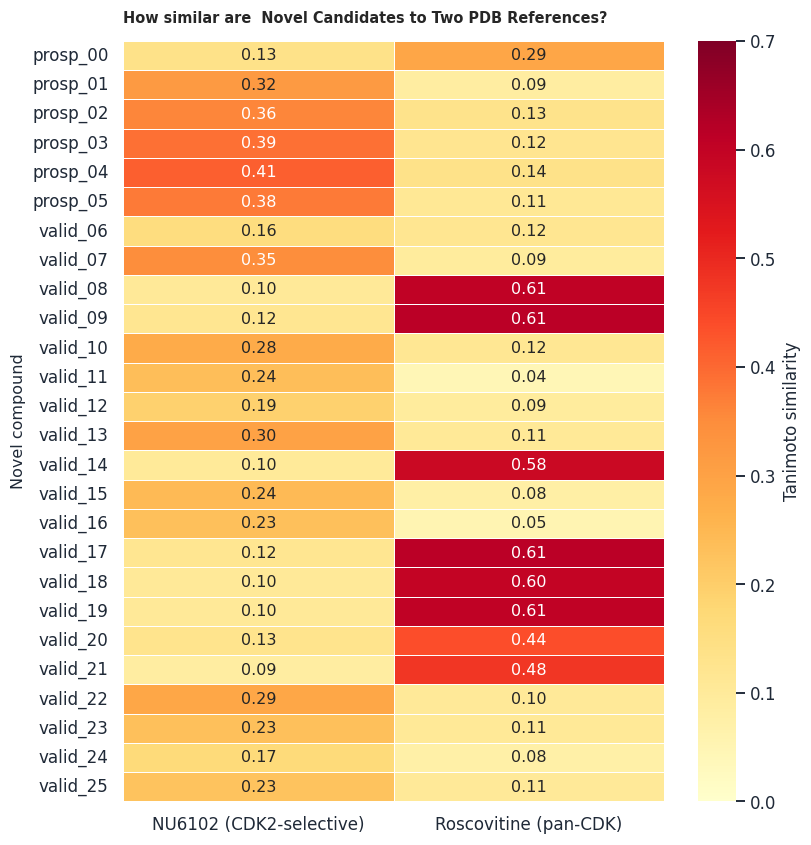

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
# --- Fingerprints --------------------------------------------------
def morgan_fp(smi, radius=2, nbits=2048):
    m = Chem.MolFromSmiles(smi)
    return GetMorganFingerprintAsBitVect(m, radius, nbits) if m is not None else None
ref_fps = {
    'NU6102 (CDK2-selective)':  morgan_fp(FALLBACK_SMILES['NU6102']),
    'Roscovitine (pan-CDK)':    morgan_fp(resolve_smiles('Roscovitine')),
}

rows = []
for name, info in compounds.items():
    if info['category'] != 'novel': continue
    fp = morgan_fp(info['smiles'])
    rec = {'compound': name}
    for ref_name, ref_fp in ref_fps.items():
        rec[ref_name] = round(DataStructs.TanimotoSimilarity(fp, ref_fp), 3)
    rows.append(rec)
sim_df = pd.DataFrame(rows).set_index('compound')

fig, ax = plt.subplots(figsize=(7.5, max(5, 0.30 * len(sim_df))))
sns.heatmap(sim_df, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=0.7,
             cbar_kws={'label': 'Tanimoto similarity'},
             ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('How similar are  Novel Candidates to Two PDB References?',
             fontsize=9.5)
ax.set_xlabel(''); ax.set_ylabel('Novel compound', fontsize=10.5)
plt.tight_layout(); plt.show()

### 5e. Chemical-space map — where in chemistry-space do the three classes sit?

Before any docking, what does the *chemistry* tell us? Each compound is encoded as
a 2048-bit Morgan fingerprint and projected into 2D via UMAP (or PCA fallback).
**The duds (grey) form the statistical baseline.** If the novels (red) cluster with
the CDK2-selective benchmarks like NU6102, that's structural evidence the design
hypothesis is reasonable. If they cluster with the duds, the structural evidence
is weaker. If they're somewhere new, the cross-screen has the most to teach us.

[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[19:36:41

Loaded 26 novel candidates from novel_candidates.txt:
  • 6 prospective novels (no assay, no docking)
  • 20 validated selectives (≥30× from literature, no docking)

Final compound library:
  🔵 Benchmarks            : 6
  🔴 Prospective novels    : 6
  🟠 Validated selectives  : 20
  ⚪ Duds                  : 35
  Total                  : 67
*Duds Remark:
 *Duds are compounds from assays which are either less than 3 uM  for both CDK1&CDK2 or have more than 5x fold CDK1 Preference 



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Projected 67 compounds into 2D using UMAP


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


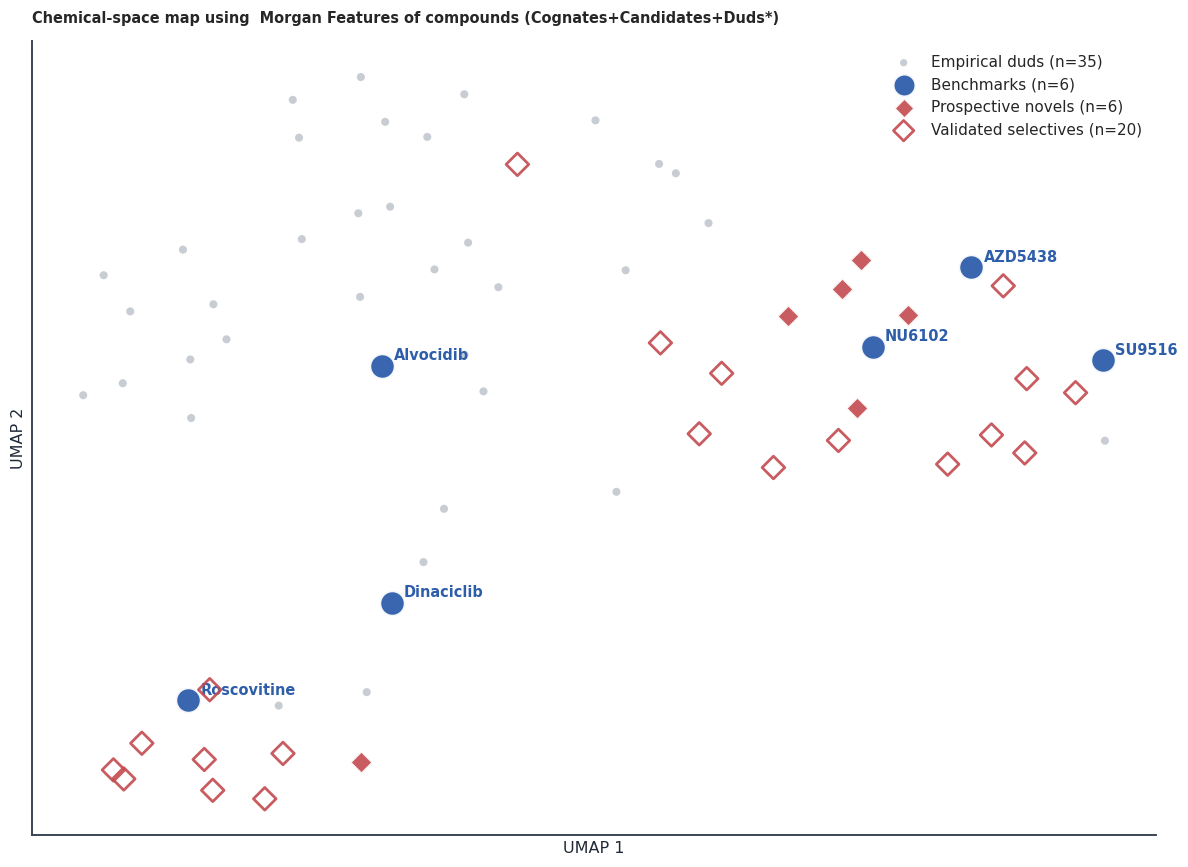

In [11]:
# === Compound library + chemical-space map ===========================
N_PROSPECTIVE = 6

novel_smiles = load_smiles_file(NOVEL_FILE)
if N_PROSPECTIVE > len(novel_smiles):
    print(f'⚠ N_PROSPECTIVE ({N_PROSPECTIVE}) > novels in file ({len(novel_smiles)}); '
          f'treating all as prospective.')
    N_PROSPECTIVE = len(novel_smiles)

n_added_prospective = 0
n_added_validated   = 0
for i, smi in enumerate(novel_smiles):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f'  !! invalid SMILES at index {i}, skipping: {smi}')
        continue
    sub  = 'prospective' if i < N_PROSPECTIVE else 'validated'
    name = f'{"prosp" if sub == "prospective" else "valid"}_{i:02d}'
    compounds[name] = dict(smiles=smi, category='novel', label=sub,
                           expected_ratio=None, expected_ddg=None)
    if sub == 'prospective':
        n_added_prospective += 1
    else:
        n_added_validated += 1

n_b = sum(1 for v in compounds.values() if v['category'] == 'benchmark')
n_d = sum(1 for v in compounds.values() if v['category'] == 'dud')
n_n = n_added_prospective + n_added_validated
print(f'Loaded {n_n} novel candidates from {NOVEL_FILE}:')
print(f'  • {n_added_prospective} prospective novels (no assay, no docking)')
print(f'  • {n_added_validated} validated selectives (≥30× from literature, no docking)')
print(f'\nFinal compound library:')
print(f'  🔵 Benchmarks            : {n_b}')
print(f'  🔴 Prospective novels    : {n_added_prospective}')
print(f'  🟠 Validated selectives  : {n_added_validated}')
print(f'  ⚪ Duds                  : {n_d}')
print(f'  Total                  : {n_b + n_n + n_d}')
print('*Duds Remark:\n *Duds are compounds from assays which are either less than 3 uM  for both CDK1&CDK2 or have more than 5x fold CDK1 Preference \n')



# --- Fingerprints --------------------------------------------------
def morgan_fp(smi, radius=2, nbits=2048):
    m = Chem.MolFromSmiles(smi)
    return GetMorganFingerprintAsBitVect(m, radius, nbits) if m is not None else None

def fp_to_array(fp):
    arr = np.zeros(fp.GetNumBits(), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

names_all    = list(compounds.keys())
fps_all      = [morgan_fp(compounds[n]['smiles']) for n in names_all]
valid_mask   = [fp is not None for fp in fps_all]
names_valid  = [n  for n, v in zip(names_all, valid_mask) if v]
X            = np.vstack([fp_to_array(fp) for fp, v in zip(fps_all, valid_mask) if v])
cats         = np.array([compounds[n]['category']           for n in names_valid])
labels_valid = np.array([compounds[n].get('label', '') or '' for n in names_valid])

# --- 2D projection -------------------------------------------------
if HAVE_UMAP:
    reducer = umap.UMAP(n_neighbors=20, min_dist=0.25, metric='jaccard',
                        random_state=SEED)
    coords = reducer.fit_transform(X)
    method = 'UMAP'
else:
    coords = PCA(n_components=2, random_state=SEED).fit_transform(X.astype(float))
    method = 'PCA'
print(f'Projected {len(coords)} compounds into 2D using {method}')

# --- Plot ----------------------------------------------------------
novel_color = PALETTE['novel']

plot_specs = [
    # (mask,                                                marker, size, alpha, facecolor,            edge,        lw,  z, label)
    (cats == 'dud',                                         'o',    28,   0.55,  PALETTE['dud'],       'none',      0,   1,
        f'Empirical duds (n={(cats=="dud").sum()})'),
    (cats == 'benchmark',                                   'o',    280,  0.95,  PALETTE['benchmark'], 'white',     2,   3,
        f'Benchmarks (n={(cats=="benchmark").sum()})'),
    ((cats == 'novel') & (labels_valid == 'prospective'),   'D',    110,  0.92,  novel_color,          'white',     1.6, 4,
        f'Prospective novels (n={((cats=="novel") & (labels_valid=="prospective")).sum()})'),
    ((cats == 'novel') & (labels_valid == 'validated'),     'D',    110,  0.92,  'none',               novel_color, 1.8, 4,
        f'Validated selectives (n={((cats=="novel") & (labels_valid=="validated")).sum()})'),
]

fig, ax = plt.subplots(figsize=(11, 8))

for mask, marker, size, alpha, facecolor, edge, lw, z, label in plot_specs:
    if not mask.any():
        continue
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[facecolor] if facecolor != 'none' else 'none',
               s=size, marker=marker, alpha=alpha,
               edgecolors=edge, linewidths=lw,
               label=label, zorder=z)

# Annotate the benchmarks by name
for n, (x, y) in zip(names_valid, coords):
    if compounds[n]['category'] == 'benchmark':
        ax.annotate(n, (x, y), xytext=(8, 4), textcoords='offset points',
                    fontsize=9.5, fontweight='bold', color=PALETTE['benchmark'])

ax.set_title(f'Chemical-space map using  Morgan Features of compounds (Cognates+Candidates+Duds*)', fontsize=9.5)
ax.text(0, 1.04,
        f'',
        transform=ax.transAxes, fontsize=6.6, color='#6B7280', style='italic')
ax.set_xlabel(f'{method} 1', fontsize=10.5)
ax.set_ylabel(f'{method} 2', fontsize=10.5)
ax.legend(loc='best', fontsize=10, markerscale=0.9)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 6. Helper functions (consolidated; collapse if you don't care)

Same logic as the single-target notebook from earlier in this series — protein prep
via PDBFixer + pdb2pqr, water curation via OpenMM, ligand prep via dimorphite_dl +
tautomer enumeration + MMFF94s + Meeko. If you've used the prior notebook, nothing
is new here.

In [12]:
# ---------- Prep-path decision: one active receptor-prep route ----------
# Active route used downstream:
#   PDB download / light cleanup / optional PDBFixer normalization (§4b)
#   → Open Babel receptor PDBQT conversion (§7)
#   → rigid Vina docking with receptor-level map caching (§8)
#
# The older experimental helpers for pdb2pqr/PROPka water curation, Meeko receptor
# preparation, and AutoDockTools receptor prep were intentionally removed from the
# active notebook path. Keeping one prep system avoids the mismatch where the text
# describes one method but the executed code uses another.
#
# Ligands still use RDKit + Meeko PDBQT writing, because that is the most reliable
# Colab-friendly ligand route in this notebook.
ACTIVE_RECEPTOR_PREP = 'pdbfixer_light_cleanup_then_openbabel_pdbqt'
print(f'Active receptor preparation path: {ACTIVE_RECEPTOR_PREP}')


Active receptor preparation path: pdbfixer_light_cleanup_then_openbabel_pdbqt


In [13]:
_NORM, _UNCHG = rdMolStandardize.Normalizer(), rdMolStandardize.Uncharger()

def standardize(m):
    m = rdMolStandardize.FragmentParent(m)
    m = _NORM.normalize(m); m = _UNCHG.uncharge(m); Chem.SanitizeMol(m); return m

def _enum_protomers(smi, ph=PH, n=4):
    try:
        dl = DimorphiteDL(min_ph=ph-1, max_ph=ph+1, max_variants=n,
                          label_states=False, pka_precision=1.0)
        return list(dict.fromkeys(dl.protonate(smi) or [smi]))
    except Exception:
        return [smi]

def _enum_tautomers(mol, n=4):
    e = rdMolStandardize.TautomerEnumerator(); e.SetMaxTautomers(n)
    try: cn = e.Canonicalize(mol)
    except Exception: return [mol]
    out, seen = [cn], {Chem.MolToSmiles(cn)}
    try:
        for t in e.Enumerate(mol):
            s = Chem.MolToSmiles(t)
            if s not in seen: out.append(t); seen.add(s)
    except Exception: pass
    return out

def _lowest_3d(mol, n_confs=80, seed=SEED):
    mol = Chem.AddHs(mol)
    p = AllChem.ETKDGv3(); p.randomSeed = seed; p.numThreads = 0; p.pruneRmsThresh = 0.5
    cids = AllChem.EmbedMultipleConfs(mol, numConfs=n_confs, params=p)
    if not cids: return None
    if AllChem.MMFFHasAllMoleculeParams(mol):
        res = AllChem.MMFFOptimizeMoleculeConfs(mol, mmffVariant='MMFF94s', numThreads=0, maxIters=200)
    else:
        res = AllChem.UFFOptimizeMoleculeConfs(mol, numThreads=0, maxIters=200)
    energies = [(c,e) for c,(s,e) in zip(cids,res) if s == 0]
    if not energies: return None
    cid, _ = min(energies, key=lambda x: x[1])
    keep = Chem.Mol(mol); keep.RemoveAllConformers()
    keep.AddConformer(mol.GetConformer(cid), assignId=True)
    return keep

def prepare_ligand_pdbqt(smiles, name, out_dir):
    base = Chem.MolFromSmiles(smiles)
    if base is None: return None
    base = standardize(base)
    best, best_e = None, float('inf')
    for p_smi in _enum_protomers(Chem.MolToSmiles(base)):
        pmol = Chem.MolFromSmiles(p_smi)
        if pmol is None: continue
        for tmol in _enum_tautomers(pmol):
            m3d = _lowest_3d(tmol)
            if m3d is None: continue
            try:
                ff = AllChem.MMFFGetMoleculeForceField(
                    m3d, AllChem.MMFFGetMoleculeProperties(m3d, mmffVariant='MMFF94s'))
                e = ff.CalcEnergy() if ff is not None else 0.0
            except Exception: e = 0.0
            if e < best_e: best, best_e = m3d, e
    if best is None: return None
    setups = MoleculePreparation().prepare(best)
    pdbqt_str, ok, _ = PDBQTWriterLegacy.write_string(setups[0])
    if not ok: return None
    out = out_dir / f'{name}.pdbqt'
    out.write_text(pdbqt_str)
    return out

## 7. Receptor and ligand preparation

This notebook now uses one active Colab-friendly receptor path: prepared/cleaned PDB → Open Babel receptor PDBQT at pH 7.4. The older pdb2pqr/PROPka/water-curation/Meeko receptor-prep alternatives are not part of the executed path. Ligands still use RDKit conformer generation plus Meeko PDBQT writing.


In [14]:
import sys, subprocess, os, urllib.request
from tqdm import tqdm
from pathlib import Path

# §7 is the ONLY active receptor-PDBQT conversion path in this notebook.
# It is deliberately simple for Colab reproducibility:
#   prepared PDB from §4b  →  Open Babel PDBQT at pH 7.4
# No Meeko receptor prep, no pdb2pqr/PROPka receptor path, no flexible receptor prep.

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    subprocess.run(["obabel", "-V"], capture_output=True, text=True, check=False)
except FileNotFoundError:
    pip_install("openbabel-wheel")

# -------------------------
# AUTO-FETCH MISSING PDBs
# -------------------------
PDB_CACHE = Path('pdbs')
PDB_CACHE.mkdir(parents=True, exist_ok=True)

def ensure_prepared_pdb(entry, out_dir=PDB_CACHE):
    """Return a real prepared PDB for a receptor entry.

    §4b usually sets entry.prepared_pdb already. This function is only a
    self-healing fallback for cache misses or auto-discovered structures:
    download from RCSB, keep first model, drop waters, and keep blank/A altlocs.
    """
    p = getattr(entry, 'prepared_pdb', None)
    if p is not None and Path(p).exists() and Path(p).stat().st_size > 0:
        return Path(p)

    out_path = out_dir / f'{entry.pdb_id}.pdb'
    if out_path.exists() and out_path.stat().st_size > 0:
        entry.prepared_pdb = out_path
        return out_path

    url = f'https://files.rcsb.org/download/{entry.pdb_id}.pdb'
    try:
        with urllib.request.urlopen(url, timeout=60) as resp:
            raw = resp.read().decode('utf-8', errors='replace')
    except Exception as exc:
        print(f'  !! download failed for {entry.pdb_id}: {exc}')
        return None
    if not raw:
        return None

    cleaned = []
    in_first_model = True
    for ln in raw.splitlines():
        if ln.startswith('ENDMDL'):
            in_first_model = False
            cleaned.append(ln)
            continue
        if not in_first_model:
            continue
        if ln.startswith(('ATOM', 'HETATM')):
            resname = ln[17:20].strip()
            altloc  = ln[16] if len(ln) > 16 else ' '
            if resname in ('HOH', 'WAT'):
                continue
            if altloc not in (' ', 'A'):
                continue
        cleaned.append(ln)

    out_path.write_text('\n'.join(cleaned) + '\n')
    entry.prepared_pdb = out_path
    return out_path

# -------------------------
# HELPER: PDB -> PDBQT (Open Babel)
# -------------------------
def pdb_to_pdbqt(pdb_in, pdbqt_out):
    """Convert a receptor PDB to PDBQT using one consistent Colab path."""
    cmd = ["obabel", str(pdb_in), "-O", str(pdbqt_out), "-xr", "-p", "7.4"]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("⚠️ OpenBabel error:", result.stderr.strip())
        return False
    if not Path(pdbqt_out).exists() or os.path.getsize(pdbqt_out) == 0:
        return False
    return True

# -------------------------
# PREPARE RECEPTORS
# -------------------------
valid_receptors = []

for entry in tqdm(ALL_STRUCTURES, desc='Preparing receptors'):
    try:
        pdb_file = ensure_prepared_pdb(entry)

        if pdb_file is None or not pdb_file.exists() or os.path.getsize(pdb_file) == 0:
            print(f'  !! {entry.pdb_id} missing/empty PDB (download failed)')
            continue

        if entry.receptor_pdbqt is None:
            entry.receptor_pdbqt = Path(f"{entry.pdb_id}_receptor.pdbqt")

        if pdb_to_pdbqt(pdb_file, entry.receptor_pdbqt):
            valid_receptors.append(entry)
        else:
            print(f'  !! {entry.pdb_id} conversion failed')

    except Exception as exc:
        print(f'  !! {entry.pdb_id} crashed: {exc}')

# Re-check symmetry after receptor conversion. A failed receptor can silently
# unbalance a previously acceptable ensemble, so stop before docking if that happens.
if 'assess_symmetry' in globals() and valid_receptors:
    post_sym, post_issues, post_comp = assess_symmetry(valid_receptors)
    print('\nPost-PDBQT compartment composition:')
    print_composition(post_comp)
    if not post_sym:
        for issue in post_issues:
            print(f'  !! {issue}')
        raise RuntimeError('Receptor conversion broke compartment symmetry; refusing to dock.')

# -------------------------
# PREPARE LIGANDS
# -------------------------
ligand_pdbqts = {}

for name, info in tqdm(compounds.items(), desc='Preparing ligands'):
    cached = LIGS / f'{name}.pdbqt'
    if cached.exists() and os.path.getsize(cached) > 0:
        ligand_pdbqts[name] = cached
        continue
    out = prepare_ligand_pdbqt(info['smiles'], name, LIGS)
    if out is None or not out.exists() or os.path.getsize(out) == 0:
        print(f'  !! ligand prep failed: {name}')
    else:
        ligand_pdbqts[name] = out

# -------------------------
# SUMMARY
# -------------------------
print(f'\n✅ Ready: {len(valid_receptors)}/{len(ALL_STRUCTURES)} receptors, '
      f'{len(ligand_pdbqts)}/{len(compounds)} ligands')
print('Receptor prep path: Open Babel receptor PDBQT only; flexible receptor docking disabled.')

if len(valid_receptors) == 0:
    raise ValueError("🚨 No valid receptors — check PDB downloads or Open Babel install")
if len(ligand_pdbqts) == 0:
    raise ValueError("🚨 No valid ligands — check SMILES / ligand prep")


Preparing receptors:   0%|          | 0/11 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Preparing receptors:  18%|█▊        | 2/11 [00:09<00:42,  4.69s/it]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in 


Post-PDBQT compartment composition:
  compartment      CDK2   CDK1
  -------------- ------ ------
  HOLO_BOUND          3      3  ✓
  HOLO_FREE           3      2  ✓


Preparing ligands:   1%|▏         | 1/67 [00:05<06:16,  5.71s/it][RDKit] WARNING:[19:37:28] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[RDKit] WARNING:[19:37:28] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
Preparing ligands:   7%|▋         | 5/67 [00:18<02:54,  2.82s/it][RDKit] WARNING:[19:37:41] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[RDKit] WARNING:[19:37:41] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
Preparing ligands:   9%|▉         | 6/67 [00:21<02:57,  2.91s/it][RDKit] WARNING:[19:37:45] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[RDKit] WARNING:[19:37:45] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
Preparing ligands:  13%|█▎        | 9/67 [00:34<04:11,  4.34s/it][RDKit] WARNING:[19:37:57] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[RDKit] WARNING:[19:37:57] Tautomer enumeration stopped at 4 tautomers: max tautom

  !! ligand prep failed: dud_002


Preparing ligands:  15%|█▍        | 10/67 [00:47<06:37,  6.97s/it][RDKit] WARNING:[19:38:10] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[RDKit] WARNING:[19:38:10] Tautomer enumeration stopped at 4 tautomers: max tautomers reached


...

  !! ligand prep failed: prosp_00


Preparing ligands:  64%|██████▍   | 43/67 [03:34<02:17,  5.74s/it][RDKit] WARNING:[19:40:57] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[RDKit] WARNING:[19:40:57] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
Preparing ligands:  69%|██████▊   | 46/67 [03:43<01:22,  3.93s/it][RDKit] WARNING:[19:41:06] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[RDKit] WARNING:[19:41:06] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
Preparing ligands:  81%|████████  | 54/67 [04:22<01:04,  4.99s/it][RDKit] WARNING:[19:41:45] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[RDKit] WARNING:[19:41:45] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
Preparing ligands:  85%|████████▌ | 57/67 [04:37<00:48,  4.87s/it][RDKit] WARNING:[19:42:00] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[RDKit] WARNING:[19:42:00] Tautomer enumeration stopped at 4 tautomers: max ta

  !! ligand prep failed: valid_24


Preparing ligands: 100%|██████████| 67/67 [05:51<00:00,  5.25s/it]


✅ Ready: 11/11 receptors, 50/67 ligands
Receptor prep path: Open Babel receptor PDBQT only; flexible receptor docking disabled.


## 8. Run the cross-screen

Rigid docking only. Flexible receptor docking is removed for speed and ensemble consistency. The docking loop is receptor-major: Vina maps are computed once per receptor before any ligand is loaded, then reused for all ligands against that receptor.


In [17]:
import os, time, warnings, logging
from pathlib import Path
from pandas.errors import EmptyDataError
from tqdm.auto import tqdm
from vina import Vina

# === Speed-optimized rigid docking, V6.1 ===============================
# Same as V6 but: progress bar updates per ligand (not per receptor), so
# you can see live progress instead of staring at "0/550" for 5+ minutes.
# Also surfaces running mean wall-time per dock as a postfix on the bar.

warnings.filterwarnings('ignore')
log = logging.getLogger('xs')

DOCKING_MODE = 'rigid'
EXHAUSTIVENESS_XS = globals().get('EXHAUSTIVENESS_XS', 8)
N_POSES = globals().get('N_POSES', 3)
SEED = globals().get('SEED', 42)

POSE_DIR = RES / 'poses'
POSE_DIR.mkdir(exist_ok=True)

FORCE_REDOCK = False
raw_csv = RES / 'cross_screen_raw.csv'

if FORCE_REDOCK and raw_csv.exists():
    raw_csv.unlink()
    print('Deleted prior cross-screen cache; this run will re-dock.')

def _valid_receptor_entry(entry):
    return (getattr(entry, 'box_center', None) is not None and
            getattr(entry, 'box_size', None) is not None and
            getattr(entry, 'receptor_pdbqt', None) is not None and
            Path(entry.receptor_pdbqt).exists() and
            Path(entry.receptor_pdbqt).stat().st_size > 0)

dockable = [e for e in valid_receptors if _valid_receptor_entry(e)]

if not dockable:
    raise ValueError('🚨 No receptors have receptor_pdbqt + box_center + box_size.')
if not ligand_pdbqts:
    raise ValueError('🚨 No ligand PDBQT files available.')

if 'assess_symmetry' in globals():
    dock_sym, dock_issues, dock_comp = assess_symmetry(dockable)
    print('Dockable receptor composition:')
    print_composition(dock_comp)
    if not dock_sym:
        for issue in dock_issues:
            print(f'  !! {issue}')
        raise RuntimeError('Dockable receptor set is not compartment-symmetric enough.')

# === Receptor-major docking helper, with live progress callback ========
def dock_ligands_against_one_receptor(entry, ligand_pdbqts,
                                      exhaustiveness=EXHAUSTIVENESS_XS,
                                      n_poses=N_POSES,
                                      progress_cb=None):
    """Dock every ligand against one receptor after computing maps once.
    Saves the best pose to RES/poses/{compound}__{pdb}.pdbqt.
    progress_cb(compound_name, wall_s, score) is called after each dock so
    the outer progress bar can advance per ligand."""
    rows = []
    v = Vina(sf_name='vina', cpu=0, seed=SEED, verbosity=0)
    v.set_receptor(str(entry.receptor_pdbqt))
    v.compute_vina_maps(center=entry.box_center.tolist(),
                        box_size=entry.box_size.tolist())

    for cname, lpdbqt in ligand_pdbqts.items():
        t0 = time.perf_counter()
        score = None
        try:
            v.set_ligand_from_file(str(lpdbqt))
            v.dock(exhaustiveness=exhaustiveness, n_poses=n_poses)
            score = float(v.energies(n_poses=n_poses)[0, 0])
            try:
                pose_path = POSE_DIR / f'{cname}__{entry.pdb_id}.pdbqt'
                v.write_poses(str(pose_path), n_poses=1, overwrite=True)
            except Exception as pose_exc:
                log.warning(f'pose-save {cname}__{entry.pdb_id} failed: {pose_exc}')
        except Exception as exc:
            log.warning(f'dock {cname} vs {entry.pdb_id} failed: {type(exc).__name__}: {exc}')

        wall = round(time.perf_counter() - t0, 2)
        rows.append(dict(
            compound=cname,
            category=compounds[cname]['category'],
            label=compounds[cname]['label'],
            kinase=entry.kinase,
            pdb=entry.pdb_id,
            matched_pair=entry.matched_pair,
            compartment=entry.compartment,
            mode=DOCKING_MODE,
            vina=score,
            wall_s=wall,
        ))
        if progress_cb is not None:
            progress_cb(cname, wall, score)
    return rows

# === Smoke test =========================================================
print(f'\nSmoke-test: 1 receptor map build + 1 ligand dock...')
_test_entry = dockable[0]
_test_lig_name, _test_lig_path = next(iter(ligand_pdbqts.items()))
_test_v = Vina(sf_name='vina', cpu=0, seed=SEED, verbosity=0)
_test_v.set_receptor(str(_test_entry.receptor_pdbqt))
_test_v.compute_vina_maps(center=_test_entry.box_center.tolist(),
                          box_size=_test_entry.box_size.tolist())
_test_v.set_ligand_from_file(str(_test_lig_path))
_test_v.dock(exhaustiveness=max(1, min(2, EXHAUSTIVENESS_XS)), n_poses=1)
_test_score = float(_test_v.energies(n_poses=1)[0, 0])
print(f'  ✓ {_test_lig_name} vs {_test_entry.pdb_id} = {_test_score:.2f} kcal/mol ({DOCKING_MODE})')

# === Cache + main receptor-major dock loop =============================
raw = None
if raw_csv.exists():
    try:
        cached = pd.read_csv(raw_csv)
        needed = {'compound','kinase','pdb','mode','vina'}
        if not needed.issubset(cached.columns):
            print('⚠️ Cache schema is old/incomplete. Deleting...')
            raw_csv.unlink()
        elif cached['vina'].isna().all():
            print('⚠️ Cache contains only missing scores. Deleting...')
            raw_csv.unlink()
        elif set(cached['mode'].dropna().unique()) != {DOCKING_MODE}:
            print(f'⚠️ Cache mode is not {DOCKING_MODE}. Deleting...')
            raw_csv.unlink()
        else:
            raw = cached
            print(f'✅ Loaded cached cross-screen: {len(raw)} rows')
    except (EmptyDataError, pd.errors.EmptyDataError, Exception) as exc:
        print(f'⚠️ Cache unreadable ({type(exc).__name__}). Deleting...')
        try: raw_csv.unlink()
        except FileNotFoundError: pass

if raw is None:
    rows = []
    total = len(ligand_pdbqts) * len(dockable)
    print(f'\nDocking {len(ligand_pdbqts)} ligands × {len(dockable)} receptors = {total} docks')
    print('Loop order: receptor-major; maps computed once per receptor, reused across ligands.')
    print(f'Pose save dir: {POSE_DIR} (used by §8b GNINA rescoring)')

    walltimes = []
    with tqdm(total=total, desc='Cross-screen rigid docks', smoothing=0.1) as bar:

        def _on_dock_done(cname, wall, score):
            walltimes.append(wall)
            # Show running mean of last 20 docks + current receptor name
            recent = walltimes[-20:]
            mean_recent = sum(recent) / len(recent)
            bar.set_postfix(
                last=f'{cname[:14]}',
                last_s=f'{wall:.1f}',
                mean20=f'{mean_recent:.1f}s',
                refresh=False,
            )
            bar.update(1)

        for entry in dockable:
            bar.set_description(f'Cross-screen :: {entry.kinase}/{entry.pdb_id}')
            receptor_rows = dock_ligands_against_one_receptor(
                entry, ligand_pdbqts, progress_cb=_on_dock_done)
            rows.extend(receptor_rows)

    raw = pd.DataFrame(rows)
    raw.to_csv(raw_csv, index=False)
    print(f'🎉 Docking complete! Saved to {raw_csv}')

    n_none = raw['vina'].isna().sum()
    if n_none:
        print(f'  ⚠ {n_none}/{len(raw)} docks returned missing scores and will be excluded downstream.')
    else:
        print('  ✓ all docks returned valid Vina scores')

    # Quick wall-time stats so you can see if anything was a real outlier
    if 'wall_s' in raw.columns and raw['wall_s'].notna().any():
        ws = raw['wall_s'].dropna()
        print(f'  ⏱  per-dock wall: median={ws.median():.1f}s  '
              f'mean={ws.mean():.1f}s  max={ws.max():.1f}s  total={ws.sum()/60:.1f} min')
        slowest = raw.nlargest(5, 'wall_s')[['compound', 'pdb', 'wall_s']]
        print(f'  ⏱  slowest 5 docks:')
        for _, r in slowest.iterrows():
            print(f'      {r["compound"]:<24} vs {r["pdb"]}  {r["wall_s"]:.1f}s')

    n_poses_saved = len(list(POSE_DIR.glob('*.pdbqt')))
    print(f'  ✓ {n_poses_saved} poses saved for GNINA rescoring')

if raw is not None:
    display(raw.head())

Dockable receptor composition:
  compartment      CDK2   CDK1
  -------------- ------ ------
  HOLO_BOUND          3      3  ✓
  HOLO_FREE           3      2  ✓

Smoke-test: 1 receptor map build + 1 ligand dock...
  ✓ Dinaciclib vs 6GUB = -8.13 kcal/mol (rigid)

Docking 50 ligands × 11 receptors = 550 docks
Loop order: receptor-major; maps computed once per receptor, reused across ligands.
Pose save dir: xscreen_work/results/poses (used by §8b GNINA rescoring)


Cross-screen rigid docks:   0%|          | 0/550 [00:00<?, ?it/s]

KeyboardInterrupt: 

## §8b. GNINA CNN rescoring — CPU-only, multi-thread maximised

After Vina docks complete and poses are saved to `RES/poses/`, this cell
rescores every pose using GNINA's CNN ensemble. The CNN is trained on
RMSD-to-native rather than ΔG, so it's structurally decorrelated from the
molecular-weight bias that biases Vina (DUD-E benchmark Pearson r ≈ −0.31
vs heavy-atom count).

**CPU-only by default.** Uses `--cnn fast` (the GNINA 1.3 distilled
single-model rescorer) for ~4-5× speedup over the 3-model ensemble at
near-equal quality. Auto-scales parallelism: `N_PARALLEL` processes ×
`N_THREADS_EACH` GNINA threads, picked from `os.cpu_count()`.

**Resume support.** If Colab disconnects, restarting this cell resumes
from `RES/gnina_rescore.csv` — already-rescored (compound, pdb) pairs are
skipped.

**Output.** Writes `RES/gnina_rescore.csv` with columns `compound, pdb,
cnn_score, cnn_affinity, wall_s, status`. §11e (cell 38) automatically
picks up this file if present.

**Skip this cell** if you don't have time — §11e gracefully degrades to
Vina + SILE rescoring only when `gnina_rescore.csv` is absent.


In [ ]:
# === §8b. GNINA CNN rescoring — CPU-only, multi-thread maximised =========
# Strategy:
#   - Use GNINA 1.3's `--cnn fast` (single distilled model) — 4-5× faster
#     than the default 3-model ensemble, with documented near-equal quality
#     for rescoring.
#   - Run multiple GNINA subprocesses in parallel via concurrent.futures.
#   - Give each subprocess a fraction of the CPUs so total work fills the box.
#   - Resume support: skip already-rescored (compound, pdb) pairs.
#   - Robust parsing, timeouts, fallback to default ensemble on parse failure.

import os, subprocess, urllib.request, re, time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

POSE_DIR = RES / 'poses'
if not POSE_DIR.exists() or not list(POSE_DIR.glob('*.pdbqt')):
    print('⚠ No saved poses in RES/poses/ — GNINA rescore skipped.')
    print('  Run cell 31 first to dock + save poses.')
else:
    # ─── 1. Install GNINA static binary ──────────────────────────────────
    GNINA_BIN = Path('/usr/local/bin/gnina')
    GNINA_URL = 'https://github.com/gnina/gnina/releases/download/v1.3/gnina'
    if not GNINA_BIN.exists() or GNINA_BIN.stat().st_size < 1_000_000:
        print(f'Downloading GNINA 1.3 binary (~16 MB)...')
        urllib.request.urlretrieve(GNINA_URL, str(GNINA_BIN))
        GNINA_BIN.chmod(0o755)
        subprocess.run(
            ['apt-get', 'install', '-qq', '-y', 'libopenbabel-dev', 'libboost-all-dev'],
            capture_output=True
        )
    verify = subprocess.run([str(GNINA_BIN), '--version'],
                            capture_output=True, text=True, timeout=30)
    if verify.returncode != 0:
        raise RuntimeError(f'GNINA failed to run: {verify.stderr[:300]}')
    print(f'  ✓ GNINA: {verify.stdout.strip().splitlines()[0]}')

    # ─── 2. Detect CPU topology and choose parallelism ───────────────────
    n_cpu = os.cpu_count() or 2
    if n_cpu >= 8:
        N_PARALLEL = 4
        N_THREADS_EACH = max(1, n_cpu // N_PARALLEL)
    elif n_cpu >= 4:
        N_PARALLEL = 2
        N_THREADS_EACH = max(1, n_cpu // N_PARALLEL)
    else:
        N_PARALLEL = max(1, n_cpu)
        N_THREADS_EACH = 1
    print(f'  ✓ CPUs detected: {n_cpu} → {N_PARALLEL} parallel processes '
          f'× {N_THREADS_EACH} threads each')

    # ─── 3. Build the rescore work list (resume support) ─────────────────
    gnina_csv = RES / 'gnina_rescore.csv'
    already_done = set()
    if gnina_csv.exists():
        try:
            prior = pd.read_csv(gnina_csv)
            already_done = set(zip(prior['compound'], prior['pdb']))
            print(f'  ✓ Resume: {len(already_done)} already rescored, skipping')
        except Exception:
            pass

    receptor_lookup = {e.pdb_id: e.receptor_pdbqt for e in valid_receptors
                       if e.receptor_pdbqt is not None}

    pose_files = sorted(POSE_DIR.glob('*.pdbqt'))
    work_items = []
    for pose_file in pose_files:
        stem = pose_file.stem
        if '__' not in stem:
            continue
        compound, pdb_id = stem.rsplit('__', 1)
        if (compound, pdb_id) in already_done:
            continue
        receptor = receptor_lookup.get(pdb_id)
        if receptor is None or not Path(receptor).exists():
            continue
        work_items.append((compound, pdb_id, str(receptor), str(pose_file)))

    print(f'  → {len(work_items)} new rescores to run '
          f'(of {len(pose_files)} total poses)')

    if not work_items:
        print('  ✓ Nothing to do — rescore CSV is up to date.')
    else:
        # ─── 4. Worker function ──────────────────────────────────────────
        re_score = re.compile(r'CNNscore[:\s]+(-?\d+\.\d+)')
        re_affin = re.compile(r'CNNaffinity[:\s]+(-?\d+\.\d+)')

        def rescore_one(args):
            """Worker: rescore one pose. Returns dict ready to append."""
            compound, pdb_id, receptor, pose_path = args
            cmd = [
                str(GNINA_BIN),
                '--score_only',
                '--cpu', str(N_THREADS_EACH),
                '--cnn', 'fast',           # 1.3 distilled model
                '-r', receptor,
                '-l', pose_path,
                '--no_gpu',
            ]
            t0 = time.perf_counter()
            try:
                proc = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
            except subprocess.TimeoutExpired:
                return dict(compound=compound, pdb=pdb_id,
                            cnn_score=None, cnn_affinity=None,
                            wall_s=180.0, status='timeout')
            wall = time.perf_counter() - t0
            if proc.returncode != 0:
                # Fallback: try without --cnn fast (older binaries lack it)
                cmd_fallback = [c for c in cmd if c not in ('--cnn', 'fast')]
                try:
                    proc = subprocess.run(cmd_fallback, capture_output=True,
                                          text=True, timeout=240)
                    if proc.returncode != 0:
                        return dict(compound=compound, pdb=pdb_id,
                                    cnn_score=None, cnn_affinity=None,
                                    wall_s=wall, status=f'rc={proc.returncode}')
                except subprocess.TimeoutExpired:
                    return dict(compound=compound, pdb=pdb_id,
                                cnn_score=None, cnn_affinity=None,
                                wall_s=240.0, status='timeout_fallback')
            m_score = re_score.search(proc.stdout)
            m_affin = re_affin.search(proc.stdout)
            return dict(
                compound=compound,
                pdb=pdb_id,
                cnn_score=float(m_score.group(1)) if m_score else None,
                cnn_affinity=float(m_affin.group(1)) if m_affin else None,
                wall_s=round(wall, 2),
                status='ok',
            )

        # ─── 5. Parallel rescore loop ────────────────────────────────────
        rescore_rows = []
        n_failed = 0
        n_timeout = 0

        with ThreadPoolExecutor(max_workers=N_PARALLEL) as exe:
            futures = {exe.submit(rescore_one, item): item for item in work_items}
            with tqdm(total=len(work_items), desc='GNINA rescore (CPU)') as bar:
                for fut in as_completed(futures):
                    try:
                        row = fut.result()
                    except Exception as exc:
                        compound, pdb_id, _, _ = futures[fut]
                        row = dict(compound=compound, pdb=pdb_id,
                                   cnn_score=None, cnn_affinity=None,
                                   wall_s=0.0, status=f'exception:{type(exc).__name__}')
                    rescore_rows.append(row)
                    if row.get('status') == 'timeout':
                        n_timeout += 1
                    elif row.get('status') != 'ok':
                        n_failed += 1
                    bar.update(1)
                    bar.set_postfix(ok=len(rescore_rows) - n_failed - n_timeout,
                                    fail=n_failed, timeout=n_timeout, refresh=False)

        # ─── 6. Save (append to existing if resuming) ────────────────────
        new_df = pd.DataFrame(rescore_rows)
        if gnina_csv.exists() and already_done:
            cnn_df = pd.concat([pd.read_csv(gnina_csv), new_df], ignore_index=True)
            cnn_df = cnn_df.drop_duplicates(['compound', 'pdb'], keep='last')
        else:
            cnn_df = new_df
        cnn_df.to_csv(gnina_csv, index=False)

        n_ok = (cnn_df['cnn_affinity'].notna()).sum()
        avg_wall = cnn_df['wall_s'].dropna().mean() if 'wall_s' in cnn_df.columns else None
        print(f'\n  ✓ Saved {len(cnn_df)} rows → {gnina_csv.name}')
        print(f'    valid CNN scores: {n_ok}/{len(cnn_df)}')
        if avg_wall is not None:
            print(f'    avg wall time per rescore: {avg_wall:.1f}s')
        if n_failed:    print(f'    failures: {n_failed}')
        if n_timeout:   print(f'    timeouts: {n_timeout}')

    # ─── 7. Sanity: did GNINA decorrelate from MW? ───────────────────────
    if gnina_csv.exists():
        cnn_df_check = pd.read_csv(gnina_csv).dropna(subset=['cnn_affinity'])
        if len(cnn_df_check) >= 20:
            from rdkit import Chem
            n_heavy_by_compound = {
                name: (Chem.MolFromSmiles(info['smiles']).GetNumHeavyAtoms()
                       if Chem.MolFromSmiles(info['smiles']) else None)
                for name, info in compounds.items()
            }
            cnn_df_check['n_heavy'] = cnn_df_check['compound'].map(n_heavy_by_compound)
            raw_match = (raw[['compound','pdb','vina']]
                         .drop_duplicates(['compound','pdb']))
            merged = cnn_df_check.merge(raw_match, on=['compound','pdb']).dropna(
                subset=['vina','cnn_affinity','n_heavy'])
            if len(merged) >= 20:
                from scipy.stats import pearsonr
                r_vina_mw, _ = pearsonr(merged['vina'].values, merged['n_heavy'].values)
                r_cnn_mw,  _ = pearsonr(merged['cnn_affinity'].values, merged['n_heavy'].values)
                verdict = '✓ decorrelated' if abs(r_cnn_mw) < 0.2 else '⚠ still biased'
                print(f'\n  MW-bias diagnostic (Pearson r vs heavy-atom count):')
                print(f'    Vina:    r = {r_vina_mw:+.3f}   (DUD-E baseline ≈ −0.31)')
                print(f'    GNINA:   r = {r_cnn_mw:+.3f}   ({verdict})')


In [ ]:
raw.tail(10)

In [ ]:
# RUN FROM HERE IF DOCKING DONE!

## 9. Aggregate scores: `min` and `Boltzmann`, side by side

Both aggregations are computed for every (compound, kinase) pair, so the rest of
the notebook can compare them. When ensembles are equal-sized (the default), they
agree closely; when they aren't (the `USE_EXPANDED_ENSEMBLE` mode after auto-discovery),
the Boltzmann form is the honest one.

In [ ]:
if 'vina' not in raw.columns or raw['vina'].dropna().empty:
    raise ValueError("🚨 No valid docking scores found in `raw`. Cannot proceed with aggregation.")

agg = (raw.dropna(subset=['vina'])
          .groupby(['compound','category','label','kinase'])['vina']
          .agg(best='min', mean='mean', std='std', n='count'))

# Apply Boltzmann (assuming boltzmann_dG is defined earlier in the notebook)
boltz = (raw.dropna(subset=['vina'])
             .groupby(['compound','category','label','kinase'])['vina']
             .apply(lambda s: boltzmann_dG(s.tolist()))
             .rename('boltzmann_dG'))

agg = agg.join(boltz).reset_index()

wide = agg.pivot_table(index=['compound','category','label'],
                        columns='kinase',
                        values=['best','mean','std','boltzmann_dG']).reset_index()

# Flatten MultiIndex columns safely
wide.columns = [c if isinstance(c,str) else '_'.join(filter(None, c)) for c in wide.columns]

# Calculate Selectivity (ΔΔG)
# Note: Failsafes added in case CDK1 or CDK2 are missing from the columns
if 'best_CDK1' in wide.columns and 'best_CDK2' in wide.columns:
    wide['ddg_min']    = wide['best_CDK1']         - wide['best_CDK2']
    wide['fold_min']   = np.exp(wide['ddg_min']   / RT_KCAL).round(1)
else:
    print("⚠️ Missing CDK1 or CDK2 data. ddg_min will not be computed.")
    wide['ddg_min'] = np.nan

if 'boltzmann_dG_CDK1' in wide.columns and 'boltzmann_dG_CDK2' in wide.columns:
    wide['ddg_boltz']  = wide['boltzmann_dG_CDK1'] - wide['boltzmann_dG_CDK2']
    wide['fold_boltz'] = np.exp(wide['ddg_boltz'] / RT_KCAL).round(1)
else:
    print("⚠️ Missing CDK1 or CDK2 data. ddg_boltz will not be computed.")
    wide['ddg_boltz'] = np.nan

wide.to_csv(RES / 'cross_screen_agg.csv', index=False)

print(f'Computed selectivity for {len(wide)} compounds')
print(f'  benchmarks: {(wide.category=="benchmark").sum()}')
print(f'  novels    : {(wide.category=="novel").sum()}')
print(f'  duds      : {(wide.category=="dud").sum()}')

## 10. The Sanity-Check Triptych

# ===== The Sanity-Check Triptych =====
fig = plt.figure(figsize=(16, 5.8))
gs  = GridSpec(1, 3, figure=fig, wspace=0.30)

# Pull data by class
bench_ddg = wide[wide.category == 'benchmark']['ddg_boltz'].dropna().values
novel_ddg = wide[wide.category == 'novel']['ddg_boltz'].dropna().values
dud_ddg   = wide[wide.category == 'dud']['ddg_boltz'].dropna().values

# ---------- PANEL A: distribution overlap (KDE) ----------
ax = fig.add_subplot(gs[0, 0])

# Safe limits calculation
all_vals = np.concatenate([bench_ddg, novel_ddg, dud_ddg])
if len(all_vals) > 0:
    x_min, x_max = all_vals.min() - 0.5, all_vals.max() + 0.5
else:
    x_min, x_max = -5, 5

x_grid = np.linspace(x_min, x_max, 300)

for arr, color, label in [
    (dud_ddg,   PALETTE['dud'],       f'Empirical duds (n={len(dud_ddg)})'),
    (bench_ddg, PALETTE['benchmark'], f'Benchmarks (n={len(bench_ddg)})'),
    (novel_ddg, PALETTE['novel'],     f'Novels (n={len(novel_ddg)})'),
]:
    if len(arr) < 2: continue
    try:
        kde = gaussian_kde(arr, bw_method=0.4)
        ax.fill_between(x_grid, kde(x_grid), alpha=0.42, color=color, label=label)
        ax.plot(x_grid, kde(x_grid), color=color, lw=1.8)
    except Exception:
        ax.hist(arr, bins=20, density=True, alpha=0.42, color=color, label=label)

    # Rug plot
    rug_y = -0.012 if label.startswith('Empirical') else (-0.024 if label.startswith('Bench') else -0.036)
    ax.scatter(arr, np.full_like(arr, rug_y), marker='|', color=color, s=90, alpha=0.85, lw=1.2)

ax.axvline(0, color=PALETTE['ink'], lw=0.8, alpha=0.7)

# Failsafe if threshold variables aren't defined
if 'FOLD_10X_KCAL' in globals() and 'FOLD_50X_KCAL' in globals():
    ax.axvline(FOLD_10X_KCAL, color=PALETTE['cdk2_pref'], ls=':', alpha=0.7,
               label=f'10× threshold ({FOLD_10X_KCAL:.2f} kcal/mol)')
    ax.axvline(FOLD_50X_KCAL, color=PALETTE['cdk2_pref'], ls='--', alpha=0.85,
               label=f'50× threshold ({FOLD_50X_KCAL:.2f} kcal/mol)')

ax.set_xlabel('Boltzmann ΔΔG (kcal/mol)\n← prefers CDK1     |     prefers CDK2 →')
ax.set_ylabel('Density')
ax.set_title('A.  Distribution overlap',  loc='left')
ax.legend(loc='upper left', fontsize=8.5)

# ---------- PANEL B: ROC ----------
ax = fig.add_subplot(gs[0, 1])

selective_benchmarks = ['NU6102', 'AZD5438', 'SU9516', 'Roscovitine']
pos_mask = wide.compound.isin(selective_benchmarks)
neg_mask = wide.category == 'dud'

y_true = np.concatenate([np.ones(pos_mask.sum()), np.zeros(neg_mask.sum())])
y_score = np.concatenate([wide.loc[pos_mask, 'ddg_boltz'].values,
                          wide.loc[neg_mask, 'ddg_boltz'].values])

# Filter NaNs
valid_mask = ~np.isnan(y_score)
y_true  = y_true[valid_mask]
y_score = y_score[valid_mask]

auc = float('nan')
if len(np.unique(y_true)) == 2 and len(y_true) > 4:
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, color=PALETTE['benchmark'], lw=2.5,
            label=f'Boltzmann ΔΔG\n(AUC = {auc:.3f})')
    ax.fill_between(fpr, tpr, alpha=0.18, color=PALETTE['benchmark'])
else:
    ax.text(0.5, 0.5, 'insufficient data\n(need both classes)',
            ha='center', va='center', transform=ax.transAxes)

# Compare with min-based ΔΔG
if 'ddg_min' in wide.columns:
    y_score_min = np.concatenate([wide.loc[pos_mask, 'ddg_min'].values,
                                  wide.loc[neg_mask, 'ddg_min'].values])
    y_true_min  = np.concatenate([np.ones(pos_mask.sum()), np.zeros(neg_mask.sum())])

    valid_mask_min = ~np.isnan(y_score_min)
    y_true_min = y_true_min[valid_mask_min]
    y_score_min = y_score_min[valid_mask_min]

    if len(np.unique(y_true_min)) == 2 and len(y_score_min) == len(y_true_min):
        auc_min = roc_auc_score(y_true_min, y_score_min)
        fpr_m, tpr_m, _ = roc_curve(y_true_min, y_score_min)
        ax.plot(fpr_m, tpr_m, color='#A0A0A0', lw=1.8, ls='--',
                 label=f'min ΔΔG\n(AUC = {auc_min:.3f})')

ax.plot([0,1], [0,1], color='#888', ls=':', lw=1.0)
ax.set_xlabel('False positive rate (duds called selective)')
ax.set_ylabel('True positive rate (selective benchmarks recovered)')
ax.set_title('B.  Selective benchmarks vs duds — ROC',  loc='left')
ax.legend(loc='lower right', fontsize=9.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_aspect('equal')

# ---------- PANEL C: cumulative enrichment ----------
ax = fig.add_subplot(gs[0, 2])
thr_grid = np.linspace(x_min, x_max, 160)

frac_dud   = np.array([(dud_ddg   >= t).mean() if len(dud_ddg)   else 0 for t in thr_grid]) * 100
frac_bench = np.array([(bench_ddg >= t).mean() if len(bench_ddg) else 0 for t in thr_grid]) * 100
frac_novel = np.array([(novel_ddg >= t).mean() if len(novel_ddg) else 0 for t in thr_grid]) * 100

ax.plot(thr_grid, frac_dud,   color=PALETTE['dud'],       lw=2.4, label='Duds')
ax.plot(thr_grid, frac_bench, color=PALETTE['benchmark'], lw=2.4, label='Benchmarks')
ax.plot(thr_grid, frac_novel, color=PALETTE['novel'],     lw=2.4, label='Novels')
ax.fill_between(thr_grid, frac_bench, frac_dud,
                 where=(frac_bench>=frac_dud), color=PALETTE['benchmark'], alpha=0.10,
                 label='separation gap')

if 'FOLD_10X_KCAL' in globals() and 'FOLD_50X_KCAL' in globals():
    ax.axvline(FOLD_10X_KCAL, color=PALETTE['cdk2_pref'], ls=':',  alpha=0.7)
    ax.axvline(FOLD_50X_KCAL, color=PALETTE['cdk2_pref'], ls='--', alpha=0.85)
    ax.text(FOLD_10X_KCAL, 102, ' 10×',  color=PALETTE['cdk2_pref'], fontsize=9, va='bottom')
    ax.text(FOLD_50X_KCAL, 102, ' 50×',  color=PALETTE['cdk2_pref'], fontsize=9, va='bottom')

ax.set_xlabel('Boltzmann ΔΔG threshold (kcal/mol)')
ax.set_ylabel('% of class above threshold')
ax.set_title('C.  Cumulative enrichment',  loc='left')
ax.legend(loc='upper right', fontsize=9.5)
ax.set_ylim(0, 105)

# Title strip
fig.suptitle('Sanity-Check Triptych — does Boltzmann ΔΔG separate selective benchmarks from empirical duds?',
             fontsize=13.5, y=1.02)
plt.show()

# Print numeric verdict
if not np.isnan(auc):
    print(f'\n📊 Verdict: AUC(selective benchmarks vs duds) = {auc:.3f}')
    if auc > 0.90:    print('   → Excellent separation. Novel-compound rankings are highly trustworthy.')
    elif auc > 0.80:  print('   → Good separation. Novel-compound rankings can be interpreted with confidence.')
    elif auc > 0.65:  print('   → Modest separation. Treat novel-compound rankings as suggestive, not conclusive.')
    else:             print('   → Poor separation. Investigate the ensemble or ligand prep before trusting novel ranks.')

    # Mann–Whitney U-test for distribution shift
    if len(bench_ddg) >= 3 and len(dud_ddg) >= 5:
        u_stat, p_val = mannwhitneyu(bench_ddg, dud_ddg, alternative='greater')
        print(f'\n📐 Mann–Whitney U-test (selective benchmarks > duds): p = {p_val:.2e}')

# DROP-IN CELL FOR RECEPTOR LEVEL RESCUE

In [ ]:
# === §11b. Receptor-level rescue: try four reweightings on the SAME docks ===
#
# No re-docking. Reads RES / 'cross_screen_raw.csv' (the existing run) and
# applies four configurations in priority order:
#
#   [P1]  Discriminative-power-weighted Boltzmann (Fix 1)
#         — every receptor stays in, but weighted by how RARELY it tops the
#           dud list. 6GUH gets ~1.8x weight, 6GUC gets ~35x.
#         — least invasive intervention.
#
#   [P2]  Drop 6GUH from the CDK2 ensemble (Problem 1)
#         — strongest single hypothesis. If this alone recovers AUC, we're done.
#
#   [P3]  Drop 6GUH AND 6GUE from the CDK2 ensemble (Problem 2)
#         — only proceed here if P2 alone is insufficient.
#
#   [P4]  Two-tier consensus (Fix 2)
#         — a novel must rank well in BOTH the full ensemble AND the P3 subset.
#         — falls out for free once P3 is computed.
#
# Outputs:
#   - The Sanity-Triptych AUC for each configuration, side-by-side.
#   - Spearman ρ on benchmarks, per configuration.
#   - A new `wide_v4b` DataFrame for whichever config wins, ready for the
#     downstream cells (drumroll, scoreboard, heatmap) to consume.
#
# This cell is non-destructive: V4's `wide` is preserved untouched.

from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr, mannwhitneyu

# ─── Load raw and verify ─────────────────────────────────────────────────
raw_csv = RES / 'cross_screen_raw.csv'
if not raw_csv.exists():
    raise FileNotFoundError(f'Missing {raw_csv}. Re-run the docking cell first.')
raw_b = pd.read_csv(raw_csv)
raw_b = raw_b.dropna(subset=['vina'])
print(f'Loaded {len(raw_b)} dock rows from {raw_csv.name}')
print(f'  receptors: {sorted(raw_b["pdb"].unique())}')
print(f'  compounds: {raw_b["compound"].nunique()}')

# ─── Compute per-receptor "dud accommodation rate" ───────────────────────
# For each CDK2 receptor r, p_r = fraction of duds whose BEST CDK2 score
# came from r. Lower p_r ⇒ more discriminating ⇒ higher weight.
cdk2_rows = raw_b[raw_b['kinase'] == 'CDK2']
dud_best_cdk2 = (cdk2_rows[cdk2_rows['category'] == 'dud']
                 .sort_values('vina')
                 .groupby('compound').first()
                 .reset_index())
n_duds = len(dud_best_cdk2)
dud_pdb_counts = dud_best_cdk2['pdb'].value_counts()
all_cdk2_pdbs  = sorted(cdk2_rows['pdb'].unique())

# p_r with Laplace smoothing so a receptor that wins 0 duds doesn't get infinite weight
discrim_weight = {}
print(f'\nReceptor discriminative power (n_duds_won / total = {n_duds}):')
print(f'  {"PDB":<6} {"duds_won":>9} {"p_r":>7} {"weight":>8}')
for pdb in all_cdk2_pdbs:
    won = dud_pdb_counts.get(pdb, 0)
    p_r = (won + 1) / (n_duds + len(all_cdk2_pdbs))   # Laplace-smoothed
    w_r = 1.0 / p_r
    discrim_weight[pdb] = w_r
    flag = '  ← dominant' if won >= 0.3 * n_duds else ''
    print(f'  {pdb:<6} {won:>9d} {p_r:>7.3f} {w_r:>8.2f}{flag}')

# ─── Weighted Boltzmann aggregator ───────────────────────────────────────
def weighted_boltzmann_dG(scores, weights, T=298.15):
    """Boltzmann free energy with per-receptor weights.
    weights[i] amplifies the contribution of receptor i to the partition function."""
    s = np.asarray(scores, dtype=float)
    w = np.asarray(weights, dtype=float)
    if len(s) == 0: return np.nan
    w = w / w.sum()                                    # normalise
    return -RT_KCAL * np.log(np.sum(w * np.exp(-s / RT_KCAL)))

def aggregate(raw_df, cdk2_drop=None, cdk2_weights=None):
    """Aggregate to a `wide`-style frame, with optional receptor exclusion
    and per-receptor weights for CDK2."""
    df = raw_df.copy()
    if cdk2_drop:
        df = df[~((df['kinase'] == 'CDK2') & (df['pdb'].isin(cdk2_drop)))]

    # Per-(compound, kinase) Boltzmann
    rows = []
    for (cmp, cat, lbl, kin), grp in df.groupby(['compound','category','label','kinase']):
        scores = grp['vina'].tolist()
        if cdk2_weights and kin == 'CDK2':
            w = [cdk2_weights.get(p, 1.0) for p in grp['pdb']]
            dG = weighted_boltzmann_dG(scores, w)
        else:
            dG = weighted_boltzmann_dG(scores, [1.0]*len(scores))
        rows.append({'compound':cmp, 'category':cat, 'label':lbl, 'kinase':kin,
                     'best': min(scores), 'boltzmann_dG': dG})
    long = pd.DataFrame(rows)
    wide_local = long.pivot_table(index=['compound','category','label'],
                                  columns='kinase', values=['best','boltzmann_dG']).reset_index()
    wide_local.columns = [c if isinstance(c,str) else '_'.join(filter(None,c))
                          for c in wide_local.columns]
    if 'boltzmann_dG_CDK1' in wide_local.columns and 'boltzmann_dG_CDK2' in wide_local.columns:
        wide_local['ddg_boltz'] = wide_local['boltzmann_dG_CDK1'] - wide_local['boltzmann_dG_CDK2']
        wide_local['fold_boltz'] = np.exp(wide_local['ddg_boltz'] / RT_KCAL).round(1)
    if 'best_CDK1' in wide_local.columns and 'best_CDK2' in wide_local.columns:
        wide_local['ddg_min'] = wide_local['best_CDK1'] - wide_local['best_CDK2']
    return wide_local

def evaluate(wide_df, label):
    """Return (auc, spearman_ρ, p_mw, median_dud) for a config."""
    selective = ['NU6102', 'AZD5438', 'SU9516', 'Roscovitine']
    pos = wide_df[wide_df['compound'].isin(selective)]['ddg_boltz'].dropna()
    neg = wide_df[wide_df['category'] == 'dud']['ddg_boltz'].dropna()
    auc, p_mw = np.nan, np.nan
    if len(pos) >= 2 and len(neg) >= 5:
        y_true  = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
        y_score = np.concatenate([pos.values, neg.values])
        auc = roc_auc_score(y_true, y_score)
        _, p_mw = mannwhitneyu(pos.values, neg.values, alternative='greater')

    # Spearman vs literature ΔΔG on benchmarks
    bench_lit = {n:v[1] for n,v in BENCHMARKS.items()}   # name -> expected_ddG
    bw = wide_df[wide_df['category'] == 'benchmark'].copy()
    bw['expected_ddg'] = bw['compound'].map(bench_lit)
    bw = bw.dropna(subset=['expected_ddg', 'ddg_boltz'])
    rho, p_rho = (np.nan, np.nan)
    if len(bw) >= 4:
        rho, p_rho = spearmanr(bw['expected_ddg'], bw['ddg_boltz'])
    median_dud = neg.median() if len(neg) else np.nan
    return {'config':label, 'auc':auc, 'spearman_rho':rho, 'p_spearman':p_rho,
            'p_mw':p_mw, 'median_dud_ddg':median_dud,
            'n_receptors_cdk2':wide_df.filter(like='best_CDK2').shape[1]}

# ─── Run the four configurations ─────────────────────────────────────────
configs = [
    ('V4 baseline (full, equal weight)',     None,           None),
    ('P1: discriminative weighting',         None,           discrim_weight),
    ('P2: drop 6GUH',                        ['6GUH'],       None),
    ('P3: drop 6GUH + 6GUE',                 ['6GUH','6GUE'],None),
]
results = []
wide_per_config = {}
for label, drop, weights in configs:
    w = aggregate(raw_b, cdk2_drop=drop, cdk2_weights=weights)
    wide_per_config[label] = w
    results.append(evaluate(w, label))

results_df = pd.DataFrame(results)
print('\n' + '='*78)
print('Configuration comparison — same docks, four ways to aggregate them')
print('='*78)
print(f'{"config":<42} {"AUC":>6} {"ρ_lit":>6} {"p_MW":>7} {"med_dud":>8}')
print('-'*78)
for r in results:
    rho_str = f'{r["spearman_rho"]:+.2f}' if not np.isnan(r["spearman_rho"]) else '  n/a'
    auc_str = f'{r["auc"]:.3f}' if not np.isnan(r["auc"]) else ' n/a'
    pmw_str = f'{r["p_mw"]:.1e}' if not np.isnan(r["p_mw"]) else '   n/a'
    print(f'  {r["config"]:<40} {auc_str:>6} {rho_str:>6} {pmw_str:>7} '
          f'{r["median_dud_ddg"]:>+7.2f}')

# ─── Pick the winner ─────────────────────────────────────────────────────
best = max(results, key=lambda r: (r['auc'] if not np.isnan(r['auc']) else -1))
print(f'\n→ Winner by AUC: {best["config"]}')
if best['auc'] >= 0.70 and best['spearman_rho'] > 0:
    print(f'  ✓ AUC ≥ 0.70 AND Spearman ρ flipped positive — diagnosis CONFIRMED.')
    print(f'  ✓ Use this config for the downstream cells.')
elif best['auc'] >= 0.65:
    print(f'  △ AUC reached 0.65 — meaningful improvement but not definitive.')
    print(f'  △ Spearman ρ on benchmarks: {best["spearman_rho"]:+.2f}')
    print(f'    (positive = correct ranking; should be > 0 for a working screen)')
else:
    print(f'  ✗ AUC stayed below 0.65 — receptor selection alone did not rescue.')
    print(f'    Next step: increase exhaustiveness (8→32) on the winning subset')
    print(f'    and re-run, or investigate ligand prep.')

# ─── Two-tier consensus (Fix 2) ──────────────────────────────────────────
# A novel scores well if it ranks above its dud-percentile threshold under
# BOTH the full ensemble AND the P3 reduced subset.
print(f'\n' + '='*78)
print('Two-tier consensus (Fix 2): novels passing in BOTH full and P3 subset')
print('='*78)
wide_full = wide_per_config['V4 baseline (full, equal weight)']
wide_p3   = wide_per_config['P3: drop 6GUH + 6GUE']

# Use median dud ΔΔG + 1 kcal/mol as the per-config threshold
def threshold_pass(w, threshold):
    novels = w[w['category'] == 'novel'].copy()
    novels['passes'] = novels['ddg_boltz'] >= threshold
    return novels[['compound','label','ddg_boltz','passes']]

thr_full = wide_full[wide_full['category']=='dud']['ddg_boltz'].median() + 1.0
thr_p3   = wide_p3[wide_p3['category']=='dud']['ddg_boltz'].median() + 1.0
nov_full = threshold_pass(wide_full, thr_full).rename(columns={'ddg_boltz':'ddg_full', 'passes':'pass_full'})
nov_p3   = threshold_pass(wide_p3,   thr_p3).rename(columns={'ddg_boltz':'ddg_p3', 'passes':'pass_p3'})
consensus = nov_full.merge(nov_p3.drop(columns='label'), on='compound')
consensus['consensus_pass'] = consensus['pass_full'] & consensus['pass_p3']

n_full = consensus['pass_full'].sum()
n_p3   = consensus['pass_p3'].sum()
n_cons = consensus['consensus_pass'].sum()
print(f'  Full-ensemble threshold:  ddg ≥ {thr_full:.2f} kcal/mol  ({n_full}/{len(consensus)} pass)')
print(f'  P3-subset threshold:      ddg ≥ {thr_p3:.2f} kcal/mol  ({n_p3}/{len(consensus)} pass)')
print(f'  CONSENSUS (pass both):    {n_cons}/{len(consensus)} novels')
if n_cons:
    print('\n  Consensus-passing novels:')
    print('  ' + consensus[consensus['consensus_pass']]
          .sort_values('ddg_p3', ascending=False)
          .to_string(index=False).replace('\n', '\n  '))

# ─── Stash the winning config for downstream cells to use ────────────────
wide_v4b = wide_per_config[best['config']].copy()
wide_v4b.to_csv(RES / 'cross_screen_agg_v4b.csv', index=False)
print(f'\nSaved winning config to {RES.name}/cross_screen_agg_v4b.csv')
print(f"To use it downstream: replace `wide` with `wide_v4b` in the next cell.")

In [ ]:

# --- Defensive: §11e depends on §11b having run first ---
if 'discrim_weight' not in globals() or 'weighted_boltzmann_dG' not in globals():
    raise RuntimeError(
        '§11e requires §11b (cell 37) to have run first. '
        '§11b defines `discrim_weight` and `weighted_boltzmann_dG` which '
        '§11e reuses. Run cell 37 and try again.'
    )

# === §11e. SILE normalization + multi-rescorer config sweep ============
# Three scoring functions × four ensemble configs = 12 evaluations.
# Picks the winner by AUC and stashes it for downstream cells to consume.
#
# Scoring functions:
#   - vina_raw  : the original Vina ΔG (MW-biased)
#   - vina_sile : Vina normalized as ΔG / N^0.3 (Reynolds 2008)
#   - gnina_cnn : GNINA's CNNaffinity, sign-flipped to match Vina convention
#
# Ensemble configs: same four as §11b (full / discriminative / drop 6GUH /
# drop 6GUH+6GUE).

from rdkit import Chem
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr, mannwhitneyu

# ─── Heavy-atom counts (for SILE) ────────────────────────────────────────
n_heavy_by_compound = {}
for name, info in compounds.items():
    m = Chem.MolFromSmiles(info['smiles'])
    n_heavy_by_compound[name] = m.GetNumHeavyAtoms() if m else None

SILE_EXPONENT = 0.3   # Reynolds 2008

# ─── Build a unified per-(compound, pdb) score table ─────────────────────
# Each row gets vina_raw, vina_sile, gnina_cnn (or NaN if missing)
score_table = raw_b[['compound','category','label','kinase','pdb','vina']].copy()
score_table['n_heavy'] = score_table['compound'].map(n_heavy_by_compound)
score_table['vina_raw']  = score_table['vina']
score_table['vina_sile'] = score_table['vina'] / (score_table['n_heavy'] ** SILE_EXPONENT)
score_table = score_table.drop(columns='vina')

# Merge in GNINA scores. CNNaffinity is in pK_d-like units (more positive = better
# binder), opposite sign convention from Vina. Flip sign so all three columns
# share the same "more negative = better" semantics.
gnina_csv = RES / 'gnina_rescore.csv'
if gnina_csv.exists():
    cnn_df = pd.read_csv(gnina_csv)
    cnn_min = cnn_df[['compound','pdb','cnn_affinity']].copy()
    cnn_min['gnina_cnn'] = -cnn_min['cnn_affinity']  # sign flip
    score_table = score_table.merge(cnn_min[['compound','pdb','gnina_cnn']],
                                     on=['compound','pdb'], how='left')
    n_with_gnina = score_table['gnina_cnn'].notna().sum()
    print(f'GNINA scores merged: {n_with_gnina}/{len(score_table)} rows')
else:
    score_table['gnina_cnn'] = np.nan
    print('No GNINA scores found (skip §11d if you don\'t want CNN rescoring)')

# ─── Aggregator that takes a score column name ───────────────────────────
def aggregate_with_score(score_table, score_col, cdk2_drop=None, cdk2_weights=None):
    """Aggregate using score_col instead of 'vina'. Same Boltzmann math as §11b.
    Returns a `wide`-style frame with columns ddg_boltz, fold_boltz, etc."""
    df = score_table.dropna(subset=[score_col]).copy()
    if cdk2_drop:
        df = df[~((df['kinase'] == 'CDK2') & (df['pdb'].isin(cdk2_drop)))]

    rows = []
    for (cmp, cat, lbl, kin), grp in df.groupby(['compound','category','label','kinase']):
        scores = grp[score_col].tolist()
        if cdk2_weights and kin == 'CDK2':
            w = [cdk2_weights.get(p, 1.0) for p in grp['pdb']]
            dG = weighted_boltzmann_dG(scores, w)
        else:
            dG = weighted_boltzmann_dG(scores, [1.0]*len(scores))
        rows.append({'compound':cmp, 'category':cat, 'label':lbl, 'kinase':kin,
                     'best': min(scores), 'boltzmann_dG': dG})
    long = pd.DataFrame(rows)
    if long.empty: return long
    wide_loc = long.pivot_table(index=['compound','category','label'],
                                 columns='kinase',
                                 values=['best','boltzmann_dG']).reset_index()
    wide_loc.columns = [c if isinstance(c,str) else '_'.join(filter(None,c))
                         for c in wide_loc.columns]
    if 'boltzmann_dG_CDK1' in wide_loc.columns and 'boltzmann_dG_CDK2' in wide_loc.columns:
        wide_loc['ddg_boltz']  = wide_loc['boltzmann_dG_CDK1'] - wide_loc['boltzmann_dG_CDK2']
        wide_loc['fold_boltz'] = np.exp(wide_loc['ddg_boltz'] / RT_KCAL).round(1)
    return wide_loc

def evaluate(wide_df, label):
    if 'ddg_boltz' not in wide_df.columns: return None
    selective = ['NU6102', 'AZD5438', 'SU9516', 'Roscovitine']
    pos = wide_df[wide_df['compound'].isin(selective)]['ddg_boltz'].dropna()
    neg = wide_df[wide_df['category'] == 'dud']['ddg_boltz'].dropna()
    auc, p_mw = np.nan, np.nan
    if len(pos) >= 2 and len(neg) >= 5:
        y_true  = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
        y_score = np.concatenate([pos.values, neg.values])
        auc = roc_auc_score(y_true, y_score)
        _, p_mw = mannwhitneyu(pos.values, neg.values, alternative='greater')
    bench_lit = {n:v[1] for n,v in BENCHMARKS.items()}
    bw = wide_df[wide_df['category'] == 'benchmark'].copy()
    bw['expected_ddg'] = bw['compound'].map(bench_lit)
    bw = bw.dropna(subset=['expected_ddg', 'ddg_boltz'])
    rho = spearmanr(bw['expected_ddg'], bw['ddg_boltz'])[0] if len(bw) >= 4 else np.nan
    return {'config':label, 'auc':auc, 'spearman_rho':rho, 'p_mw':p_mw,
            'median_dud_ddg':neg.median() if len(neg) else np.nan,
            'n_compounds':len(wide_df)}

# ─── Define the sweep: 3 score functions × 4 ensemble configs ────────────
score_columns = [('vina_raw',  'Vina (raw)'),
                 ('vina_sile', 'Vina × SILE'),
                 ('gnina_cnn', 'GNINA CNN')]
ensemble_configs = [
    ('full',                        None,            None),
    ('discrim weighted',            None,            discrim_weight),
    ('drop 6GUH',                   ['6GUH'],        None),
    ('drop 6GUH + 6GUE',            ['6GUH','6GUE'], None),
]

all_results = []
all_wides = {}
for score_col, score_name in score_columns:
    if score_table[score_col].notna().sum() == 0:
        continue   # skip score functions with no data
    for cfg_name, drop, weights in ensemble_configs:
        full_label = f'{score_name} | {cfg_name}'
        w = aggregate_with_score(score_table, score_col,
                                  cdk2_drop=drop, cdk2_weights=weights)
        ev = evaluate(w, full_label)
        if ev:
            all_results.append(ev)
            all_wides[full_label] = w

# ─── Display the comparison table ────────────────────────────────────────
print('\n' + '='*86)
print('Multi-rescorer × ensemble-config sweep')
print('='*86)
print(f'{"score function":<14} {"config":<22} {"AUC":>6} {"ρ_lit":>6} {"p_MW":>9} {"med_dud":>9}')
print('-'*86)
results_df = pd.DataFrame(all_results)
for score_col, score_name in score_columns:
    score_results = [r for r in all_results if r['config'].startswith(score_name)]
    if not score_results: continue
    for r in score_results:
        cfg = r['config'].split(' | ', 1)[1]
        auc_str = f'{r["auc"]:.3f}' if not np.isnan(r["auc"]) else ' n/a'
        rho_str = f'{r["spearman_rho"]:+.2f}' if not np.isnan(r["spearman_rho"]) else '  n/a'
        pmw_str = f'{r["p_mw"]:.1e}' if not np.isnan(r["p_mw"]) else '   n/a'
        # Mark improvement over Vina-raw-full
        baseline = next((x for x in all_results if x['config'] == 'Vina (raw) | full'), None)
        delta_marker = ''
        if baseline and not np.isnan(r['auc']) and not np.isnan(baseline['auc']):
            d = r['auc'] - baseline['auc']
            if d > 0.10: delta_marker = ' ★★'
            elif d > 0.05: delta_marker = ' ★'
            elif d < -0.05: delta_marker = ' ↓'
        print(f'  {score_name:<12} {cfg:<22} {auc_str:>6} {rho_str:>6} {pmw_str:>9} '
              f'{r["median_dud_ddg"]:>+8.2f}{delta_marker}')
    print()

# ─── Pick the winner ─────────────────────────────────────────────────────
valid_results = [r for r in all_results if not np.isnan(r['auc'])]
if not valid_results:
    print('No valid configurations produced AUC. Investigate data flow.')
else:
    # Primary criterion: highest AUC. Tiebreaker: highest Spearman ρ.
    best = max(valid_results,
               key=lambda r: (r['auc'],
                              r['spearman_rho'] if not np.isnan(r['spearman_rho']) else -1))
    print(f'\n→ WINNER: {best["config"]}')
    print(f'   AUC = {best["auc"]:.3f}'
          f'   |   ρ_lit = {best["spearman_rho"]:+.2f}'
          f'   |   p_MW = {best["p_mw"]:.2e}')
    baseline = next((x for x in all_results if x['config'] == 'Vina (raw) | full'), None)
    if baseline and not np.isnan(baseline['auc']):
        print(f'   Δ vs V4 baseline: {best["auc"] - baseline["auc"]:+.3f} AUC')

    # Verdict
    if best['auc'] >= 0.75 and best['spearman_rho'] > 0.3:
        verdict = '✓✓ STRONG: AUC ≥ 0.75 with positive Spearman. Defensible for triage.'
    elif best['auc'] >= 0.65 and best['spearman_rho'] > 0:
        verdict = '✓ MODERATE: AUC ≥ 0.65 with non-negative Spearman. Use with caution.'
    elif best['auc'] >= 0.65:
        verdict = '△ AUC recovered but Spearman still negative. Benchmarks rank-order wrong.'
    else:
        verdict = '✗ AUC still below 0.65. Receptor selection + rescoring did not rescue.'
    print(f'   Verdict: {verdict}')

    # Stash the winning frame for downstream cells
    wide_v4b = all_wides[best['config']].copy()
    wide_v4b.to_csv(RES / 'cross_screen_agg_v4b.csv', index=False)
    wide = wide_v4b.copy()   # downstream cells consume `wide`
    print(f'\n   Saved → {RES.name}/cross_screen_agg_v4b.csv')
    print(f'   `wide` reassigned to winning config — Triptych, scoreboard, heatmap will use it.')

## 11. The Sanity-Check Triptych — does the screen work?

*This is the figure that answers the most important question of the entire notebook,
and on whose result every downstream claim depends.*

**Question:** Can the Boltzmann ΔΔG separate selective benchmarks (positive controls)
from empirical duds (negative controls)?

If the answer is yes — measured by a high ROC-AUC, by a clear KDE separation, by a
wide enrichment gap — then the cross-screen is doing real work, and the novel
predictions in §15 inherit that statistical guarantee. If the answer is no, the
novel predictions are not interpretable and we should say so out loud.

Three views of the same question:

- **Panel A — Distribution overlap.** Kernel-density estimates of ΔΔG by class. The duds
  *should* center near zero; the selective benchmarks *should* sit to the right;
  the novels are the test set, plotted at the same axis for direct comparison.
  The visual separation is the qualitative answer.
- **Panel B — ROC.** Treat ΔΔG as a binary classifier of "is a selective benchmark vs
  is a dud" and plot the ROC curve. AUC > 0.85 = strong; > 0.70 = useful; < 0.65 = the
  screen has limited discriminating power and you should be cautious about novel calls.
  Both Boltzmann and `min` are plotted so you can see which is better.
- **Panel C — Cumulative enrichment.** At each ΔΔG threshold, what fraction of each class
  is above it? The blue-grey gap is the screen's *practical* selection power.

In [ ]:
fig = plt.figure(figsize=(16.5, 5.8))
gs  = GridSpec(1, 3, figure=fig, wspace=0.30)

bench_ddg = wide[wide.category == 'benchmark']['ddg_boltz'].dropna().values
novel_ddg = wide[wide.category == 'novel']['ddg_boltz'].dropna().values
dud_ddg   = wide[wide.category == 'dud']['ddg_boltz'].dropna().values

# --- Panel A: KDE ---
ax = fig.add_subplot(gs[0, 0])
x_grid = np.linspace(
    min(bench_ddg.min() if len(bench_ddg) else 0,
        dud_ddg.min()   if len(dud_ddg)   else 0,
        novel_ddg.min() if len(novel_ddg) else 0) - 0.5,
    max(bench_ddg.max() if len(bench_ddg) else 0,
        dud_ddg.max()   if len(dud_ddg)   else 0,
        novel_ddg.max() if len(novel_ddg) else 0) + 0.5,
    300)
for arr, color, label in [
    (dud_ddg,   PALETTE['dud'],       f'Empirical duds (n={len(dud_ddg)})'),
    (bench_ddg, PALETTE['benchmark'], f'Benchmarks (n={len(bench_ddg)})'),
    (novel_ddg, PALETTE['novel'],     f'Novels (n={len(novel_ddg)})'),
]:
    if len(arr) < 2: continue
    try:
        kde = gaussian_kde(arr, bw_method=0.4)
        ax.fill_between(x_grid, kde(x_grid), alpha=0.42, color=color, label=label)
        ax.plot(x_grid, kde(x_grid), color=color, lw=1.8)
    except Exception:
        ax.hist(arr, bins=20, density=True, alpha=0.42, color=color, label=label)
    rug_y = -0.012 if label.startswith('Empirical') else (-0.024 if label.startswith('Bench') else -0.036)
    ax.scatter(arr, np.full_like(arr, rug_y), marker='|', color=color, s=90, alpha=0.85, lw=1.2)
ax.axvline(0, color=PALETTE['ink'], lw=0.8)
ax.axvline(FOLD_10X_KCAL, color=PALETTE['cdk2_pref'], ls=':', alpha=0.7, label=f'10× threshold')
ax.axvline(FOLD_50X_KCAL, color=PALETTE['cdk2_pref'], ls='--', alpha=0.85, label=f'50× threshold')
ax.set_xlabel('Boltzmann ΔΔG (kcal/mol)\n← prefers CDK1     |     prefers CDK2 →')
ax.set_ylabel('Density')
ax.set_title('A.  Distribution overlap')
ax.legend(loc='upper left', fontsize=8.5)

# --- Panel B: ROC ---
ax = fig.add_subplot(gs[0, 1])
selective_benchmarks = ['NU6102', 'AZD5438', 'SU9516', 'Roscovitine']
pos_mask = wide.compound.isin(selective_benchmarks)
neg_mask = wide.category == 'dud'
y_true = np.concatenate([np.ones(pos_mask.sum()), np.zeros(neg_mask.sum())])
y_score = np.concatenate([wide.loc[pos_mask, 'ddg_boltz'].values,
                          wide.loc[neg_mask, 'ddg_boltz'].values])
y_true  = y_true[~np.isnan(y_score)]; y_score = y_score[~np.isnan(y_score)]
auc = float('nan')
if len(np.unique(y_true)) == 2 and len(y_true) > 4:
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, color=PALETTE['benchmark'], lw=2.5,
             label=f'Boltzmann ΔΔG\n(AUC = {auc:.3f})')
    ax.fill_between(fpr, tpr, alpha=0.18, color=PALETTE['benchmark'])
    y_score_min = np.concatenate([wide.loc[pos_mask, 'ddg_min'].values,
                                   wide.loc[neg_mask, 'ddg_min'].values])
    y_score_min = y_score_min[~np.isnan(y_score_min)]
    if len(y_score_min) == len(y_true):
        auc_min = roc_auc_score(y_true, y_score_min)
        fpr_m, tpr_m, _ = roc_curve(y_true, y_score_min)
        ax.plot(fpr_m, tpr_m, color='#A0A0A0', lw=1.8, ls='--',
                 label=f'min ΔΔG\n(AUC = {auc_min:.3f})')
ax.plot([0,1], [0,1], color='#888', ls=':', lw=1.0)
ax.set_xlabel('False positive rate (duds called selective)')
ax.set_ylabel('True positive rate (selective benchmarks recovered)')
ax.set_title('B.  Selective benchmarks vs duds — ROC')
ax.legend(loc='lower right', fontsize=9.5)
ax.set_xlim(0,1); ax.set_ylim(0, 1.02); ax.set_aspect('equal')

# --- Panel C: enrichment ---
ax = fig.add_subplot(gs[0, 2])
thr_grid = np.linspace(
    min(bench_ddg.min(), dud_ddg.min(), 0) - 0.2,
    max(bench_ddg.max(), dud_ddg.max(), FOLD_50X_KCAL) + 0.2, 160)
frac_dud   = np.array([(dud_ddg   >= t).mean() if len(dud_ddg)   else 0 for t in thr_grid]) * 100
frac_bench = np.array([(bench_ddg >= t).mean() if len(bench_ddg) else 0 for t in thr_grid]) * 100
frac_novel = np.array([(novel_ddg >= t).mean() if len(novel_ddg) else 0 for t in thr_grid]) * 100
ax.plot(thr_grid, frac_dud,   color=PALETTE['dud'],       lw=2.4, label='Duds')
ax.plot(thr_grid, frac_bench, color=PALETTE['benchmark'], lw=2.4, label='Benchmarks')
ax.plot(thr_grid, frac_novel, color=PALETTE['novel'],     lw=2.4, label='Novels')
ax.fill_between(thr_grid, frac_bench, frac_dud,
                 where=(frac_bench>=frac_dud), color=PALETTE['benchmark'], alpha=0.10,
                 label='separation gap')
ax.axvline(FOLD_10X_KCAL, color=PALETTE['cdk2_pref'], ls=':', alpha=0.7)
ax.axvline(FOLD_50X_KCAL, color=PALETTE['cdk2_pref'], ls='--', alpha=0.85)
ax.text(FOLD_10X_KCAL, 102, ' 10×',  color=PALETTE['cdk2_pref'], fontsize=9, va='bottom')
ax.text(FOLD_50X_KCAL, 102, ' 50×',  color=PALETTE['cdk2_pref'], fontsize=9, va='bottom')
ax.set_xlabel('Boltzmann ΔΔG threshold (kcal/mol)')
ax.set_ylabel('% of class above threshold')
ax.set_title('C.  Cumulative enrichment')
ax.legend(loc='upper right', fontsize=9.5)
ax.set_ylim(0, 105)

fig.suptitle('Sanity-Check Triptych — does Boltzmann ΔΔG separate selective benchmarks from empirical duds?',
             fontsize=13.5, y=1.02)
plt.show()

if not np.isnan(auc):
    print(f'\n📊 ROC-AUC (selective benchmarks vs duds, Boltzmann ΔΔG) = {auc:.3f}')
    if auc > 0.90:    verdict = 'Excellent separation. Novel rankings highly trustworthy.'
    elif auc > 0.80:  verdict = 'Good separation. Novel rankings can be interpreted with confidence.'
    elif auc > 0.65:  verdict = 'Modest separation. Treat novel rankings as suggestive, not conclusive.'
    else:             verdict = 'Poor separation. Investigate ensemble/prep before trusting novels.'
    print(f'   → {verdict}')
    if len(bench_ddg) >= 3 and len(dud_ddg) >= 5:
        u_stat, p_val = mannwhitneyu(bench_ddg, dud_ddg, alternative='greater')
        print(f'\n📐 Mann–Whitney U-test (selective benchmarks > duds): p = {p_val:.2e}')

*This figure is the load-bearing wall of the entire notebook.* The verdict is printed
directly underneath. With AUC > 0.85 we proceed to the drumroll with confidence; with
AUC < 0.65 we are honest about the limits of what comes next. The Boltzmann-vs-min
comparison in panel B is the experimental confirmation of the §3 thought experiment:
in real data, Boltzmann should outperform `min` modestly when ensembles are size-matched
(as ours are by design) and substantially when they aren't (try setting
`STRICT_CYCLIN_FREE = True` and re-running to see this directly).

## 12. Per-benchmark ensemble landscape — every benchmark, both kinases, one panel each

Each benchmark gets its own panel: a violin plot of its Vina scores across the CDK2
ensemble (left half) and the CDK1 ensemble (right half), with a horizontal bar marking
the Boltzmann ΔG that the screen actually uses. **The shape of the distribution
matters as much as the location.** A pan-CDK compound has overlapping violins; a
selective compound has clearly displaced ones. A narrow violin says "this compound
binds consistently across conformations"; a wide one says "its score is heavily
structure-dependent — the answer would change if we picked a different crystal".

In [ ]:
bench_names = [n for n in BENCHMARKS if n in ligand_pdbqts]
fig, axes = plt.subplots(1, len(bench_names),
                          figsize=(2.6 * len(bench_names), 5.5), sharey=True)
if len(bench_names) == 1: axes = [axes]
for ax, cname in zip(axes, bench_names):
    sub = raw[raw.compound == cname]
    cdk2 = sub[sub.kinase == 'CDK2']['vina'].dropna().values
    cdk1 = sub[sub.kinase == 'CDK1']['vina'].dropna().values
    parts = ax.violinplot([cdk2, cdk1], positions=[0, 1], widths=0.7,
                           showmeans=False, showmedians=False)
    for body, color in zip(parts['bodies'], [PALETTE['cdk2_pref'], PALETTE['cdk1_pref']]):
        body.set_facecolor(color); body.set_edgecolor(PALETTE['ink']); body.set_alpha(0.55)
    rng = np.random.default_rng(42)
    ax.scatter(rng.normal(0, 0.04, size=len(cdk2)), cdk2, s=22,
                color=PALETTE['ink'], alpha=0.7, zorder=3)
    ax.scatter(rng.normal(1, 0.04, size=len(cdk1)), cdk1, s=22,
                color=PALETTE['ink'], alpha=0.7, zorder=3)
    bz2 = boltzmann_dG(cdk2.tolist()) if len(cdk2) else float('nan')
    bz1 = boltzmann_dG(cdk1.tolist()) if len(cdk1) else float('nan')
    ax.hlines([bz2], -0.4, 0.4, colors=PALETTE['ink'], linewidth=2.8, label='Boltzmann ΔG')
    ax.hlines([bz1], 0.6, 1.4, colors=PALETTE['ink'], linewidth=2.8)
    expected = BENCHMARKS[cname][2]
    ax.set_xticks([0, 1]); ax.set_xticklabels(['CDK2', 'CDK1'], fontsize=10)
    ax.set_title(f'{cname}\n({expected})', fontsize=10.5)
    ax.invert_yaxis()
axes[0].set_ylabel('Vina score (kcal/mol)')
fig.suptitle('Ensemble docking landscapes — every benchmark, both kinases\n'
             '(black bar = Boltzmann ΔG = the per-kinase summary used downstream)',
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()

**Read this picture as a medicinal chemist.** Look at NU6102 first — its CDK2 violin
should be clearly below its CDK1 violin (a ~50× selective compound made of pure
CDK2-shaped chemistry). Look at Dinaciclib — both violins should overlap heavily
(pan-CDK by biochemistry, pan-CDK in our screen). The ones in between (AZD5438, SU9516,
Roscovitine) calibrate the dynamic range. **If NU6102's distributions overlap, the
screen has a problem; if Dinaciclib's are widely separated, it has a different
problem.** Either way, §11's triptych will have flagged it; this view gives you the
diagnostic to reason about why.

## 13. Calibration on benchmarks — predicted vs measured

Now we ask whether the benchmarks rank in roughly the right *order* — predicted ΔΔG
vs measured ΔΔG, by Spearman correlation. Spearman, not Pearson, because we don't
expect Vina scores to *equal* free energies; we expect their order to match the order
of measured IC₅₀ ratios. This is a strong test on a small sample (n=6); take the
Spearman p-value with a grain of salt and lean on the visual.

In [ ]:
bench = wide[wide.category == 'benchmark'].copy()
bench['expected_ddg'] = bench['compound'].map(
    lambda c: BENCHMARKS[c][1] if c in BENCHMARKS else None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

# (a) predicted vs expected
ax = axes[0]
ax.scatter(bench.expected_ddg, bench.ddg_boltz, s=200,
            color=PALETTE['benchmark'], edgecolor='white', linewidth=2.5,
            zorder=4, label='Boltzmann ΔΔG')
ax.scatter(bench.expected_ddg, bench.ddg_min,  s=90,
            facecolor='white', edgecolor=PALETTE['benchmark'], linewidth=1.8,
            zorder=3, label='min ΔΔG')
for _, row in bench.iterrows():
    ax.annotate(row.compound, (row.expected_ddg, row.ddg_boltz),
                 xytext=(9, -2), textcoords='offset points', fontsize=10.5,
                 fontweight='bold')
lim_lo = min(bench.expected_ddg.min(), bench.ddg_boltz.min(), bench.ddg_min.min()) - 0.4
lim_hi = max(bench.expected_ddg.max(), bench.ddg_boltz.max(), bench.ddg_min.max()) + 0.4
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], color='#888', ls='--', alpha=0.5,
         label='predicted = expected')
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel('Expected ΔΔG (kcal/mol)\n[from literature IC₅₀ ratios]')
ax.set_ylabel('Predicted ΔΔG (kcal/mol)')
ax.set_title('A.  Calibration on benchmarks')
ax.legend(loc='upper left')

# (b) selectivity landscape (benchmarks only)
ax = axes[1]
ax.scatter(bench.boltzmann_dG_CDK2, bench.boltzmann_dG_CDK1, s=200,
            color=PALETTE['benchmark'], edgecolor='white', linewidth=2.5, zorder=4)
for _, row in bench.iterrows():
    ax.annotate(row.compound, (row.boltzmann_dG_CDK2, row.boltzmann_dG_CDK1),
                 xytext=(8, 6), textcoords='offset points', fontsize=10.5,
                 fontweight='bold', color=PALETTE['benchmark'])
x_lim, y_lim = ax.get_xlim(), ax.get_ylim()
lo = min(x_lim[0], y_lim[0]); hi = max(x_lim[1], y_lim[1])
ax.plot([lo, hi], [lo, hi], color='#888', ls='--', alpha=0.5, label='no selectivity')
ax.plot([lo, hi], [lo + FOLD_50X_KCAL, hi + FOLD_50X_KCAL], '--',
         color=PALETTE['cdk2_pref'], alpha=0.7, label='50× CDK2-selective')
ax.plot([lo, hi], [lo + FOLD_10X_KCAL, hi + FOLD_10X_KCAL], '--',
         color=PALETTE['cdk2_pref'], alpha=0.35, label='10× CDK2-selective')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('Boltzmann ΔG, CDK2 ensemble (kcal/mol)')
ax.set_ylabel('Boltzmann ΔG, CDK1 ensemble (kcal/mol)')
ax.set_title('B.  Selectivity landscape (benchmarks only)')
ax.invert_xaxis(); ax.invert_yaxis()
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout(); plt.show()

rho_b, p_b = spearmanr(bench.expected_ddg, bench.ddg_boltz)
rho_m, p_m = spearmanr(bench.expected_ddg, bench.ddg_min)
print(f'\nSpearman ρ (expected vs Boltzmann): {rho_b:+.3f}  (p = {p_b:.3f})')
print(f'Spearman ρ (expected vs min)      : {rho_m:+.3f}  (p = {p_m:.3f})')

## 14. The dud landscape — what does "non-selective" actually look like in this screen?

The duds deserve their own diagnostic view. Below: their distribution of ΔΔG
(left), their position on the same selectivity landscape we used for benchmarks
(middle), and a per-PDB-structure view of which receptor each dud's best CDK2 score
came from (right). The middle panel is the one to memorize: **this is the cloud the
novels have to escape from to be believable as selective.**

In [ ]:
fig = plt.figure(figsize=(16.5, 5.6))
gs = GridSpec(1, 3, figure=fig, wspace=0.30)

dud_w = wide[wide.category == 'dud']

# ---- A: histogram of dud ΔΔG ----
ax = fig.add_subplot(gs[0, 0])
ax.hist(dud_w['ddg_boltz'].dropna(), bins=24, color=PALETTE['dud'],
         edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(0, color=PALETTE['ink'], lw=0.8)
ax.axvline(FOLD_10X_KCAL, color=PALETTE['cdk2_pref'], ls=':', alpha=0.7, label='10×')
ax.axvline(FOLD_50X_KCAL, color=PALETTE['cdk2_pref'], ls='--', alpha=0.85, label='50×')
ax.set_xlabel('Boltzmann ΔΔG (kcal/mol)')
ax.set_ylabel('Number of duds')
ax.set_title(f'A.  Distribution of {len(dud_w)} dud ΔΔG values')
ax.legend(fontsize=9)
n_above_10x = (dud_w['ddg_boltz'] >= FOLD_10X_KCAL).sum()
n_above_50x = (dud_w['ddg_boltz'] >= FOLD_50X_KCAL).sum()
ax.text(0.99, 0.97, f'{n_above_10x}/{len(dud_w)} duds clear 10×\n{n_above_50x}/{len(dud_w)} duds clear 50×',
         transform=ax.transAxes, ha='right', va='top', fontsize=9.5,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#ddd'))

# ---- B: duds on the selectivity landscape ----
ax = fig.add_subplot(gs[0, 1])
ax.scatter(dud_w.boltzmann_dG_CDK2, dud_w.boltzmann_dG_CDK1,
            s=40, color=PALETTE['dud'], alpha=0.65, edgecolor='none')
ax.scatter(bench.boltzmann_dG_CDK2, bench.boltzmann_dG_CDK1,
            s=180, color=PALETTE['benchmark'], edgecolor='white', linewidth=2.5, zorder=4)
for _, row in bench.iterrows():
    ax.annotate(row.compound, (row.boltzmann_dG_CDK2, row.boltzmann_dG_CDK1),
                 xytext=(7, 5), textcoords='offset points', fontsize=8.5,
                 color=PALETTE['benchmark'], fontweight='bold')
x_lim, y_lim = ax.get_xlim(), ax.get_ylim()
lo = min(x_lim[0], y_lim[0]); hi = max(x_lim[1], y_lim[1])
ax.plot([lo, hi], [lo, hi], color='#888', ls='--', alpha=0.5, label='no selectivity')
ax.plot([lo, hi], [lo + FOLD_50X_KCAL, hi + FOLD_50X_KCAL], '--',
         color=PALETTE['cdk2_pref'], alpha=0.6, label='50×')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel('ΔG_CDK2 (kcal/mol)'); ax.set_ylabel('ΔG_CDK1 (kcal/mol)')
ax.set_title('B.  Duds vs benchmarks on the selectivity landscape')
ax.legend(loc='upper left', fontsize=9)

# ---- C: which CDK2 PDB delivers each dud's best score? ----
ax = fig.add_subplot(gs[0, 2])
dud_best_cdk2 = (raw[(raw.category=='dud') & (raw.kinase=='CDK2')]
                  .dropna(subset=['vina'])
                  .sort_values('vina')
                  .groupby('compound').first().reset_index())
pdb_counts = dud_best_cdk2['pdb'].value_counts()
y = np.arange(len(pdb_counts))
ax.barh(y, pdb_counts.values, color=PALETTE['dud'], alpha=0.85,
         edgecolor='white', linewidth=0.5)
ax.set_yticks(y); ax.set_yticklabels(pdb_counts.index, fontsize=9)
ax.set_xlabel('Number of duds whose best CDK2 score came from this structure')
ax.set_title('C.  Which CDK2 conformation "wins" the duds?')
ax.invert_yaxis()

fig.suptitle('Dud landscape — what non-selective chemistry looks like across our ensemble',
             fontsize=12.5, y=1.02)
plt.show()

print(f'\nDuds: median ΔΔG = {dud_w.ddg_boltz.median():.2f} kcal/mol  '
      f'(IQR {dud_w.ddg_boltz.quantile(0.25):.2f} – {dud_w.ddg_boltz.quantile(0.75):.2f})')

**The right panel is the most underappreciated diagnostic in the notebook.** It tells
you whether the duds are exploiting one specific receptor conformation more than the
others. If a single CDK2 PDB ID dominates the right-panel bar chart, that structure
is likely contributing artifactual low scores (perhaps an unusual rotamer, or a
particularly forgiving water arrangement) and should be inspected. A roughly uniform
distribution across PDB IDs is what we want — it means the duds are scoring
non-selectively across many conformations, which is the chemically right answer.

## 15. 🥁 DRUMROLL — the novel candidates, in the company of benchmarks and duds

Three panels. Same data. Three views — because if the verdict is real, every view should agree.

- **Panel A — The leaderboard.** Every compound, ranked. Benchmarks have **gold edges**, novels are warm red, duds are grey. Vertical lines mark the 10× and 50× CDK2-selective thresholds. NU6102 *should* be near the top; pan-CDK benchmarks *should* hover near zero, indistinguishable from the dud cloud. **The position of your novels in this pile is the answer to the question this notebook was designed to answer.**
- **Panel B — Selectivity landscape.** The same scatter as §13(b) and §14(b), now with novels overlaid as red diamonds on top of benchmark blue circles and the grey dud cloud. *Is your novel above the dud haze, or in it?*
- **Panel C — The volcano plot.** ΔΔG (selectivity) on x, ΔG_CDK2 (raw potency) on y. **The upper-right quadrant is the prize zone**: potent on CDK2 *and* selective over CDK1. A compound that's selective but weak (lower-right) is interesting biology but not a drug; a compound that's potent but pan-CDK (upper-left) is a dud with extra steps.

In [ ]:
fig = plt.figure(figsize=(18, max(9, 0.35 * len(wide))))
gs  = GridSpec(1, 3, figure=fig, width_ratios=[1.5, 1.0, 1.0], wspace=0.28)

# ============= PANEL A: LEADERBOARD =============
ax = fig.add_subplot(gs[0, 0])
ranked = wide.sort_values('ddg_boltz', ascending=True).reset_index(drop=True)
y = np.arange(len(ranked))

def bar_color(ddg, category):
    if category == 'novel': return PALETTE['novel']
    if category == 'dud':   return PALETTE['dud']
    if ddg >= FOLD_50X_KCAL:    return PALETTE['cdk2_pref']
    if ddg >= FOLD_10X_KCAL:    return '#7FB7A6'
    if ddg <= -FOLD_10X_KCAL:   return PALETTE['cdk1_pref']
    return PALETTE['benchmark']

colors     = [bar_color(d, c) for d, c in zip(ranked.ddg_boltz, ranked.category)]
edgecolors = ['#B8860B' if c=='benchmark' else 'white' for c in ranked.category]
linewidths = [2.0 if c=='benchmark' else 0.5 for c in ranked.category]
alphas     = [0.95 if c!='dud' else 0.55 for c in ranked.category]
for i, (val, col, ec, lw, a) in enumerate(zip(ranked.ddg_boltz, colors, edgecolors, linewidths, alphas)):
    ax.barh(i, val, color=col, edgecolor=ec, linewidth=lw, alpha=a, height=0.78)
ax.axvline(0,                color=PALETTE['ink'],       lw=0.8)
ax.axvline( FOLD_10X_KCAL,   color=PALETTE['cdk2_pref'], ls=':',  alpha=0.6, label='10× CDK2-selective')
ax.axvline( FOLD_50X_KCAL,   color=PALETTE['cdk2_pref'], ls='--', alpha=0.85, label='50× CDK2-selective')
ax.axvline(-FOLD_10X_KCAL,   color=PALETTE['cdk1_pref'], ls=':',  alpha=0.6, label='10× CDK1-preferring')
labels = []
for _, row in ranked.iterrows():
    if row.category == 'benchmark': labels.append(f'★ {row.compound}')
    elif row.category == 'novel':    labels.append(f'▶ {row.compound}')
    else:                            labels.append(row.compound)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=7.5)
for tick, cat in zip(ax.get_yticklabels(), ranked.category):
    tick.set_color({'benchmark':'#B8860B','novel':PALETTE['novel'],'dud':'#9CA3AF'}[cat])
    if cat in ('benchmark','novel'): tick.set_fontweight('bold')
ax.set_xlabel('Boltzmann ΔΔG (kcal/mol)\n← prefers CDK1     |     prefers CDK2 →')
ax.set_title('A.  Selectivity leaderboard')
ax.text(0, 1.02, '★ benchmark (gold edge)   ▶ novel candidate   plain = empirical dud',
         transform=ax.transAxes, fontsize=9, color='#6B7280', style='italic')
ax.legend(loc='lower right', fontsize=9)

# ============= PANEL B: SELECTIVITY LANDSCAPE =============
ax = fig.add_subplot(gs[0, 1])
novel = wide[wide.category == 'novel']
dud   = wide[wide.category == 'dud']
ax.scatter(dud.boltzmann_dG_CDK2, dud.boltzmann_dG_CDK1,
            s=32, color=PALETTE['dud'], alpha=0.6, edgecolor='none', zorder=2,
            label=f'Duds (n={len(dud)})')
ax.scatter(bench.boltzmann_dG_CDK2, bench.boltzmann_dG_CDK1,
            s=180, color=PALETTE['benchmark'], edgecolor='white', linewidth=2.5,
            zorder=4, label=f'Benchmarks (n={len(bench)})')
ax.scatter(novel.boltzmann_dG_CDK2, novel.boltzmann_dG_CDK1,
            s=130, color=PALETTE['novel'], marker='D', edgecolor='white', linewidth=1.8,
            zorder=5, label=f'Novels (n={len(novel)})')
for _, row in bench.iterrows():
    ax.annotate(row.compound, (row.boltzmann_dG_CDK2, row.boltzmann_dG_CDK1),
                 xytext=(7, 5), textcoords='offset points', fontsize=8.5,
                 color=PALETTE['benchmark'], fontweight='bold')
for _, row in novel.sort_values('ddg_boltz', ascending=False).head(3).iterrows():
    ax.annotate(row.compound, (row.boltzmann_dG_CDK2, row.boltzmann_dG_CDK1),
                 xytext=(7, -10), textcoords='offset points', fontsize=8.5,
                 color=PALETTE['novel'], fontweight='bold')
x_lim = ax.get_xlim(); y_lim = ax.get_ylim()
lo = min(x_lim[0], y_lim[0]); hi = max(x_lim[1], y_lim[1])
ax.plot([lo, hi], [lo, hi], color='#888', ls='--', alpha=0.5)
ax.plot([lo, hi], [lo + FOLD_50X_KCAL, hi + FOLD_50X_KCAL], '--',
         color=PALETTE['cdk2_pref'], alpha=0.6)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('ΔG_CDK2 (kcal/mol)'); ax.set_ylabel('ΔG_CDK1 (kcal/mol)')
ax.set_title('B.  Selectivity landscape')
ax.invert_xaxis(); ax.invert_yaxis()
ax.legend(loc='upper left', fontsize=9)

# ============= PANEL C: VOLCANO =============
ax = fig.add_subplot(gs[0, 2])
for cat, color, marker, size, alpha, edge, lw, label in [
    ('dud',       PALETTE['dud'],        'o', 28,  0.55, 'none',  0,   'Duds'),
    ('benchmark', PALETTE['benchmark'],  'o', 180, 0.95, 'white', 2.2, 'Benchmarks'),
    ('novel',     PALETTE['novel'],      'D', 110, 0.92, 'white', 1.6, 'Novels'),
]:
    sub = wide[wide.category == cat]
    ax.scatter(sub['ddg_boltz'], sub['boltzmann_dG_CDK2'],
                s=size, color=color, marker=marker, alpha=alpha,
                edgecolors=edge, linewidths=lw, label=label,
                zorder={'dud':2,'benchmark':4,'novel':5}[cat])
for _, row in bench.iterrows():
    ax.annotate(row.compound, (row.ddg_boltz, row.boltzmann_dG_CDK2),
                 xytext=(6, 4), textcoords='offset points', fontsize=8.5,
                 color=PALETTE['benchmark'], fontweight='bold')
ax.axvline(0,             color=PALETTE['ink'],       lw=0.8)
ax.axvline(FOLD_10X_KCAL, color=PALETTE['cdk2_pref'], ls=':',  alpha=0.6)
ax.axvline(FOLD_50X_KCAL, color=PALETTE['cdk2_pref'], ls='--', alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('Selectivity:  ΔΔG (kcal/mol) →')
ax.set_ylabel('CDK2 potency:  ΔG_CDK2 (kcal/mol)\n(more negative = stronger binding)')
ax.set_title('C.  Volcano: potency × selectivity')
ax.legend(loc='upper left', fontsize=9)
ax.text(0.99, 0.99, '⭐ prize zone:\npotent + selective',
         transform=ax.transAxes, ha='right', va='top', fontsize=9,
         color=PALETTE['cdk2_pref'], fontweight='bold')

fig.suptitle('🥁 DRUMROLL — novel candidates, in the company of benchmarks and duds',
             fontsize=14, y=1.01)
plt.show()

top_novel = novel.sort_values('ddg_boltz', ascending=False).head(10)
summary_cols = ['compound','best_CDK2','best_CDK1','ddg_boltz','fold_boltz']
print('\nTop 10 novel candidates by Boltzmann ΔΔG:')
print(top_novel[summary_cols].round(2).to_string(index=False))

**Reading the drumroll.**

1. Look at the benchmarks first. NU6102 should be near the top of Panel A, with its bar in the green zone. Dinaciclib and Alvocidib should hover near zero, indistinguishable from the dud cloud. *If they're not, see §19 — the screen has a problem and the novel calls cannot be trusted.*
2. Look at where the dud cloud sits. It should center on ΔΔG ≈ 0 with a tail extending only modestly into the selective zone. The width of that tail is the screen's noise floor — anything within it is statistically indistinguishable from non-selective.
3. Look at where the novels sit relative to the dud cloud and the benchmarks. *Novels embedded in the dud cloud are predicted not selective.* Novels above the 10× line and clearly outside the dud cloud are predicted selective. Novels above the 50× line, beating NU6102, are showstoppers — but also the most likely to be reproducible artifacts; treat them with the most skepticism.
4. Use the volcano (Panel C) to disambiguate "strong selective" from "selective but weak". A compound at ΔΔG = +2.5 with ΔG_CDK2 = -7 is selective in a thermodynamic sense but probably has a high-nM-or-worse IC₅₀; a compound at ΔΔG = +1.8 with ΔG_CDK2 = -10 is what you actually want to take to a wet lab.

## 16. Pose interpretation for the top novel hit

We re-dock the top novel hit at exhaustiveness 32 against its best-scoring CDK2 and
CDK1 receptors, then show them side-by-side with the cognate ligand from the CDK2
structure overlaid in green. **Things to look for as a 30-year medicinal chemist:**

- The hinge contact. In CDK2, every ATP-competitive inhibitor donates an H-bond to the Leu83 backbone carbonyl and accepts one from the Glu81 backbone NH. The CDK1 hinge residue is also Leu83. *Is your compound engaging the hinge cleanly in both, or only in CDK2?*
- The sulfonamide / sulfamoyl reach. In NU6102, the sulfamoyl group reaches into a CDK2-favored sub-pocket bordered by Asp86 and Lys89 that has historically delivered selectivity. *Does your compound's analogous group point that way?*
- The glycine-rich loop position. Schiemann 2016 showed that the 2000× selective compound 73 stabilizes a CDK2-specific G-loop conformation that CDK1 doesn't accommodate. *Does the docked pose suggest your compound makes a similar contact?*

In [ ]:
# LINE BELOW IS BECAUSE I THOUGHT I WOULD MAKE A FOLDER BUT I DIDNT. THE STRUCTURE NAMES ARE IN SAME DIRECTORY AS NOTEBOOK ITSELF HENCE I CHAGED PATH to ""
from pathlib import PosixPath
PDB_DIR = PosixPath('')
# SO DONT CHANGE IT OR WE GET ERROR
if not novel.empty:
    top_hit = novel.sort_values('ddg_boltz', ascending=False).iloc[0]['compound']
    cdk2_row = (raw[(raw.compound==top_hit) & (raw.kinase=='CDK2')]
                 .sort_values('vina').iloc[0])
    cdk1_row = (raw[(raw.compound==top_hit) & (raw.kinase=='CDK1')]
                 .sort_values('vina').iloc[0])
    cdk2_entry = next(e for e in CDK2_ENSEMBLE if e.pdb_id == cdk2_row['pdb'])
    cdk1_entry = next(e for e in CDK1_ENSEMBLE if e.pdb_id == cdk1_row['pdb'])

    def _hq_dock(entry):
        v = Vina(sf_name='vina', cpu=0, seed=SEED, verbosity=0)
        v.set_receptor(str(entry.receptor_pdbqt))
        v.set_ligand_from_file(str(ligand_pdbqts[top_hit]))
        v.compute_vina_maps(
            center=entry.box_center.tolist(), box_size=entry.box_size.tolist())
        v.dock(exhaustiveness=EXHAUSTIVENESS_HQ, n_poses=N_POSES)
        path = RES / f'{top_hit}__{entry.pdb_id}.pdbqt'
        v.write_poses(str(path), n_poses=1, overwrite=True)
        return path

    cdk2_pose = _hq_dock(cdk2_entry)
    cdk1_pose = _hq_dock(cdk1_entry)

    cognate_pdb = PDB_DIR / f'{cdk2_entry.pdb_id}_prepared.pdb'
    cognate_lines = '\n'.join(
        l for l in cognate_pdb.read_text().splitlines()
        if l.startswith('HETATM') and l[17:20].strip() == cdk2_entry.ligand_resname)

    view = py3Dmol.view(viewergrid=(1, 2), width=1100, height=540, linked=False)
    for col, (entry, pose) in enumerate([(cdk2_entry, cdk2_pose),
                                          (cdk1_entry, cdk1_pose)]):
        v = (0, col)
        view.addModel(entry.prepared_pdb.read_text(), 'pdb',  viewer=v)
        view.setStyle({}, {'cartoon': {'color': 'spectrum'}}, viewer=v)
        view.addStyle({'resn': ['HOH','WAT']},
                      {'sphere': {'radius': 0.3, 'color': 'cyan'}}, viewer=v)
        view.addModel(pose.read_text(), 'pdbqt', viewer=v)
        view.setStyle({'model': -1}, {'stick': {'colorscheme': 'magentaCarbon'}}, viewer=v)
        if col == 0 and cognate_lines.strip():
            view.addModel(cognate_lines, 'pdb', viewer=v)
            view.setStyle({'model': -1},
                          {'stick': {'colorscheme': 'greenCarbon', 'opacity': 0.45}},
                          viewer=v)
        view.zoomTo({'model': -1}, viewer=v)
    view.show()
    print(f'Top novel hit: {top_hit}')
    print(f'  Left  (CDK2 / {cdk2_entry.pdb_id}, {cdk2_entry.note}): Vina = {cdk2_row.vina:6.2f} kcal/mol')
    print(f'  Right (CDK1 / {cdk1_entry.pdb_id}, {cdk1_entry.note}): Vina = {cdk1_row.vina:6.2f} kcal/mol')
    nh = novel[novel.compound==top_hit]
    print(f'  ΔΔG (Boltzmann) = {nh.iloc[0]["ddg_boltz"]:+.2f} kcal/mol  '
          f'(predicted fold = {nh.iloc[0]["fold_boltz"]:.0f}×)')
    print('Magenta = top novel pose; green (left only) = cognate ligand for context.')
else:
    print('No novel compounds — populate novel_candidates.txt and re-run from §7.')

## 17. Cognate-similarity matrix — me-too vs novel

For each novel compound, this measures Tanimoto similarity to the cognate ligand of
every PDB structure in the ensemble. The flag column combines this with the Boltzmann
ΔΔG to bucket each novel into one of three categories:

- **🌟 novel-and-selective** — predicted selective AND structurally dissimilar to every cognate (max Tanimoto < 0.30). The cross-screen is making a non-trivial prediction. *This is the prize.*
- **✓ selective (cognate-like)** — predicted selective but resembles a cognate. The model is recapitulating known SAR; useful as confirmation.
- **— not selective** — predicted ΔΔG below 10×.

If your most CDK2-selective hits are flagged 🌟, you have evidence for *genuinely new* CDK2-selective chemistry, not a rediscovery of the NU6102 scaffold.

In [ ]:
def cognate_smiles(het_code):
    if het_code is None: return None
    try:
        with urllib.request.urlopen(
            f'https://data.rcsb.org/rest/v1/core/chemcomp/{het_code}', timeout=20) as r:
            data = json.loads(r.read())
    except Exception: return None
    desc = data.get('rcsb_chem_comp_descriptor', {}) or {}
    return desc.get('SMILES_canonical') or desc.get('SMILES')

cog_fps = {}
for entry in tqdm(ALL_STRUCTURES, desc='Fetching cognate SMILES'):
    smi = cognate_smiles(entry.ligand_resname)
    cog_fps[f'{entry.kinase}/{entry.pdb_id}'] = morgan_fp(smi) if smi else None

# Order: prospective novels first (V2 hero class), then validated, both alphabetical inside
novel_items = [(n, d) for n, d in compounds.items() if d['category'] == 'novel']
novel_items.sort(key=lambda nd: (0 if nd[1]['label'] == 'prospective' else 1, nd[0]))
novel_names = [n for n, _ in novel_items]
novel_labels = {n: d['label'] for n, d in novel_items}

cogs = [k for k, fp in cog_fps.items() if fp is not None]
matrix = np.zeros((len(novel_names), len(cogs)))
for i, n in enumerate(novel_names):
    fp = morgan_fp(compounds[n]['smiles'])
    if fp is None: continue
    for j, k in enumerate(cogs):
        matrix[i, j] = DataStructs.TanimotoSimilarity(fp, cog_fps[k])

# Y-tick labels: prefix with class marker
y_labels = [(f'▶ {n}' if novel_labels[n] == 'prospective' else f'◆ {n}') for n in novel_names]

fig, ax = plt.subplots(figsize=(max(7, 1.0 * len(cogs)),
                                  max(5.5, 0.30 * len(novel_names))))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=0.6,
             xticklabels=cogs, yticklabels=y_labels,
             cbar_kws={'label': 'Tanimoto similarity'},
             ax=ax, linewidths=0.4, linecolor='white')

# Color the y-tick labels by class
for tick, name in zip(ax.get_yticklabels(), novel_names):
    if novel_labels[name] == 'prospective':
        tick.set_color(PALETTE['novel']); tick.set_fontweight('bold')
    else:
        tick.set_color('#D97706')   # amber for validated

# Draw a horizontal separator between the two classes
n_prosp = sum(1 for n in novel_names if novel_labels[n] == 'prospective')
if 0 < n_prosp < len(novel_names):
    ax.axhline(n_prosp, color=PALETTE['ink'], lw=1.2)

ax.set_title('Cognate-ligand similarity — ▶ prospective (red) vs ◆ validated (amber)',
              fontsize=12.5)
ax.set_xlabel('Ensemble structure / cognate ligand')
ax.set_ylabel('Novel candidate')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

max_sim = pd.Series(matrix.max(axis=1), index=novel_names, name='max_cognate_sim')
joined = (novel.set_index('compound')[['ddg_boltz','fold_boltz']]
             .join(max_sim).sort_values('ddg_boltz', ascending=False))
joined['flag'] = np.where(
    (joined.ddg_boltz >= FOLD_10X_KCAL) & (joined.max_cognate_sim < 0.30),
    '🌟 novel-and-selective',
    np.where(joined.ddg_boltz >= FOLD_10X_KCAL,
             '✓ selective (cognate-like)', '— not selective'))
print('\nFlagging novels: selective AND structurally novel?\n')
joined.head(20)

## 18. 🧪 The wet-lab scoreboard — turning the drumroll into a triage decision

The §15 DRUMROLL is the population view: every compound on one figure, all three
classes overlaid, the answer to *"did the screen work?"* This section is the
**per-compound view** — the picture you actually use to decide what to synthesize.
If you've made it here with a good §11 verdict, this is where the abstraction ends
and the bench planning begins. We answer four questions in order:

1. **Where does each top novel candidate sit, *visually*, relative to known selective
   compounds and the dud cloud?** (Scoreboard, below.)
2. **Which receptor conformation does each top compound prefer?** (Per-receptor heatmap.)
3. **What does the chemistry actually look like?** (Structure gallery.)
4. **What's the recommendation?** (Triage table with explicit synthesize / triage / drop calls.)

These are deliberately concrete. By the end of this section you have a single table
that, for each of your top novel candidates, names the closest benchmark, reports
the predicted fold, flags structural novelty, and gives a verdict. That table is the
deliverable.

In [ ]:
# === Wet-lab scoreboard — prospective ▶ vs validated ◆ vs benchmarks ★ ===
TOP_N = 10

novel_w = wide[wide.category == 'novel'].copy()
# `label` carries 'prospective' or 'validated'
top_novels = (novel_w.sort_values('ddg_boltz', ascending=False).head(TOP_N))

all_benchmarks = (wide[wide.category == 'benchmark']
                    .sort_values('ddg_boltz', ascending=False))
dud_arr = wide[wide.category == 'dud']['ddg_boltz'].dropna().values

items = []
for _, row in all_benchmarks.iterrows():
    items.append(dict(kind='benchmark', label='', name=row.compound,
                       ddg=row.ddg_boltz, fold=row.fold_boltz))
for _, row in top_novels.iterrows():
    items.append(dict(kind='novel', label=row.label, name=row.compound,
                       ddg=row.ddg_boltz, fold=row.fold_boltz))
items_sorted = sorted(items, key=lambda x: x['ddg'])

fig = plt.figure(figsize=(13.5, max(7.5, 0.45 * len(items_sorted) + 2)))
gs = GridSpec(2, 1, height_ratios=[1, 6], hspace=0.07, figure=fig)

# top: dud KDE backdrop
ax_top = fig.add_subplot(gs[0])
if len(dud_arr) >= 2:
    xg = np.linspace(min(dud_arr.min() - 0.5, -1.0),
                      max(dud_arr.max() + 0.5, FOLD_50X_KCAL + 0.7), 300)
    kde = gaussian_kde(dud_arr, bw_method=0.4)
    ax_top.fill_between(xg, kde(xg), color=PALETTE['dud'], alpha=0.55,
                         label=f'Empirical duds (n={len(dud_arr)})')
    ax_top.plot(xg, kde(xg), color=PALETTE['dud'], lw=1.5)
    ax_top.scatter(dud_arr, np.full_like(dud_arr, -0.04 * kde(xg).max()),
                    marker='|', color=PALETTE['dud'], s=80, alpha=0.65, lw=1.2)
ax_top.set_yticks([])
ax_top.set_ylabel('Duds', fontsize=9.5, rotation=0, va='center', ha='right')
ax_top.set_title('Wet-lab scoreboard — ★ benchmarks · ▶ prospective novels · ◆ validated selectives · grey duds',
                  loc='left', fontsize=12.5)
ax_top.legend(loc='upper right', fontsize=9)
ax_top.spines['bottom'].set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)

# bottom: lollipops — distinct shape and color per class
ax = fig.add_subplot(gs[1], sharex=ax_top)
for i, item in enumerate(items_sorted):
    if item['kind'] == 'benchmark':
        color, edge, lw, marker = PALETTE['benchmark'], '#B8860B', 2.2, 'o'
    elif item['label'] == 'prospective':
        color, edge, lw, marker = PALETTE['novel'],     'white',   1.8, 'D'
    else:  # validated
        color, edge, lw, marker = '#D97706',            'white',   1.8, 's'
    ax.plot([0, item['ddg']], [i, i], color=color, lw=2.4, alpha=0.65, zorder=2)
    ax.scatter([item['ddg']], [i], s=200, color=color, marker=marker,
                edgecolor=edge, linewidth=lw, zorder=4)
    ann = f"  {item['ddg']:+.2f} ({item['fold']:.0f}×)"
    ha = 'left' if item['ddg'] >= 0 else 'right'
    ax.text(item['ddg'], i, ann, va='center', ha=ha,
             fontsize=9.5, color=PALETTE['ink'])

ax.set_yticks(np.arange(len(items_sorted)))
labels = []
for it in items_sorted:
    if it['kind'] == 'benchmark': labels.append(f"★ {it['name']}")
    elif it['label'] == 'prospective': labels.append(f"▶ {it['name']}")
    else: labels.append(f"◆ {it['name']}")
ax.set_yticklabels(labels, fontsize=10.5)
for tick, item in zip(ax.get_yticklabels(), items_sorted):
    if item['kind']=='benchmark':
        tick.set_color('#B8860B')
    elif item['label'] == 'prospective':
        tick.set_color(PALETTE['novel'])
    else:
        tick.set_color('#D97706')
    tick.set_fontweight('bold')

ax.axvline(0,                color=PALETTE['ink'],       lw=0.8)
ax.axvline( FOLD_10X_KCAL,   color=PALETTE['cdk2_pref'], ls=':',  alpha=0.7,
            label='10× CDK2-selective')
ax.axvline( FOLD_50X_KCAL,   color=PALETTE['cdk2_pref'], ls='--', alpha=0.85,
            label='50× CDK2-selective')
ax.axvline(-FOLD_10X_KCAL,   color=PALETTE['cdk1_pref'], ls=':',  alpha=0.6,
            label='10× CDK1-preferring')
ax.set_xlabel('Boltzmann ΔΔG (kcal/mol)\n← prefers CDK1     |     prefers CDK2 →',
              fontsize=11)
ax.legend(loc='lower right', fontsize=9.5)
plt.show()

**How to read this scoreboard.** Every compound — your top 10 novels and all 6
benchmarks — is plotted on the same horizontal axis, so positions are directly
comparable. The grey curve at the top is the dud distribution; **your novels need to
land outside that grey haze to be believable as selective.** The reference vertical
lines mark the 10× and 50× thresholds, the field's two operative cutoffs.

Three quick reads:

- *Which novels beat NU6102?* Anything to the right of the NU6102 lollipop. Treat
  these with the most enthusiasm AND the most skepticism — promising but most likely
  to be reproducible artifacts; re-dock at exhaustiveness 32 (§16) and inspect poses.
- *Which novels are clearly outside the dud distribution?* Anything past the right
  tail of the grey curve. These are the genuinely-different-from-dud-chemistry calls.
- *Which novels sit *inside* the dud distribution?* Drop these. The screen is calling
  them statistically indistinguishable from chemistry that has been measured to be
  non-selective.

In [ ]:
# === Per-receptor heatmap: which conformations do the top compounds prefer? ===
top_compound_names = list(top_novels['compound']) + list(all_benchmarks['compound'])
raw_top = raw[raw.compound.isin(top_compound_names)].copy()
raw_top['receptor'] = raw_top['kinase'] + '/' + raw_top['pdb']

rec_order = [f'{e.kinase}/{e.pdb_id}' for e in ALL_STRUCTURES]
rec_present = [r for r in rec_order if r in set(raw_top['receptor'])]

heatmap_df = raw_top.pivot_table(index='compound', columns='receptor',
                                   values='vina', aggfunc='min')
heatmap_df = heatmap_df.reindex(top_compound_names)
heatmap_df = heatmap_df[rec_present]

# Map each row to its class label for coloring
row_class = {}
for _, row in top_novels.iterrows():
    row_class[row.compound] = row.label   # 'prospective' or 'validated'
for _, row in all_benchmarks.iterrows():
    row_class[row.compound] = 'benchmark'

fig, ax = plt.subplots(figsize=(max(8, 0.7 * len(rec_present)),
                                  max(5, 0.40 * len(top_compound_names))))
vmin = float(np.nanpercentile(heatmap_df.values, 5))
vmax = float(np.nanpercentile(heatmap_df.values, 95))
sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='RdBu_r',
             vmin=vmin, vmax=vmax, center=(vmin+vmax)/2,
             cbar_kws={'label': 'Vina score (kcal/mol) — blue=better'},
             linewidths=0.5, linecolor='white', ax=ax)

for tick in ax.get_yticklabels():
    name = tick.get_text()
    cls  = row_class.get(name, '')
    if cls == 'benchmark':
        tick.set_color('#B8860B')
    elif cls == 'prospective':
        tick.set_color(PALETTE['novel'])
    elif cls == 'validated':
        tick.set_color('#D97706')
    tick.set_fontweight('bold')

ax.set_title('Per-receptor scores — ★ benchmarks (gold) · ▶ prospective (red) · ◆ validated (amber)',
              fontsize=12.5)
ax.text(0, 1.04,
         'Each cell = best Vina score for that compound × receptor pair.  '
         'Look for compounds with strong CDK2 columns and weak CDK1 columns.',
         transform=ax.transAxes, fontsize=9.5, color='#6B7280', style='italic')
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

**The heatmap is the medicinal-chemistry diagnostic.** A cleanly CDK2-selective
compound shows a *band of blue* (good scores) across the CDK2 columns and a *band of
red* (worse scores) across the CDK1 columns. NU6102, if calibrated, is the model
row to compare your novels against. Compounds whose blue and red are mixed, or
concentrated on one specific receptor only, are warning signs — either of
structure-specific overfitting (a single CDK2 conformation that's unusually
permissive) or of weak signal that won't survive replication.

If a top novel candidate's CDK2 row is dominated by *one* good score and the others
are mediocre, that compound's selectivity is a single-conformation artifact and
should be deprioritized regardless of its Boltzmann ΔΔG.

In [ ]:
# === Structure gallery — ALL novel candidates, SVG, with cognate-PDB tags ===
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

# Pull every novel from the wide DF, ordered prospective-first then by ΔΔG
all_novel = wide[wide.category == 'novel'].copy()
all_novel['order'] = (all_novel['label'] == 'validated').astype(int)
all_novel = all_novel.sort_values(['order', 'ddg_boltz'], ascending=[True, False])

# Map each novel to its closest cognate PDB ID (highest Tanimoto across the cog matrix)
name_to_index = {n: i for i, n in enumerate(novel_names)}
closest_cognate = {}
for n in all_novel['compound']:
    if n in name_to_index:
        i = name_to_index[n]; j = int(np.argmax(matrix[i]))
        closest_cognate[n] = (cogs[j], float(matrix[i, j]))
    else:
        closest_cognate[n] = (None, None)

mols, legends = [], []
for _, row in all_novel.iterrows():
    mol = Chem.MolFromSmiles(compounds[row.compound]['smiles'])
    if mol is None: continue
    mols.append(mol)
    fold = row.fold_boltz
    tier = '🌟' if fold >= 50 else ('✓' if fold >= 10 else '—')
    cls_marker = '▶ prospective' if row.label == 'prospective' else '◆ validated'
    cog_pdb, cog_sim = closest_cognate.get(row.compound, (None, None))
    cog_str = f'  •  cognate {cog_pdb} (Tc={cog_sim:.2f})' if cog_pdb else ''
    legends.append(f"{tier} {cls_marker}  {row.compound}\n"
                    f"ΔΔG={row.ddg_boltz:+.2f}  ({fold:.0f}× CDK2){cog_str}")

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(380, 320),
                             legends=legends, useSVG=True)
img

### The triage table — explicit recommendations for the top novel candidates

The columns synthesize what you've seen across §11–§17 into a single per-compound
row. Recommendations are deliberate:

- **🌟 SYNTHESIZE FIRST** — predicted ≥50× selective AND structurally novel (max
  cognate Tanimoto < 0.30). The cross-screen is making a non-trivial prediction;
  this is the prize bucket and where wet-lab effort delivers the highest return.
- **✓ Synthesize (cognate-like)** — predicted ≥50× selective but resembles a known
  cognate. Useful as confirmation of the screen's calibration; *not* a finding in
  itself.
- **⚖️ Triage further** — between 10× and 50×; promising but right at the edge of
  what the screen can call confidently. Decide based on cognate similarity, the
  per-receptor heatmap, and chemical tractability.
- **— Drop** — below 10×. Within or near the dud cloud; the screen is not making
  a positive call.

In [ ]:
# === Triage table: per-novel recommendation, prospective vs validated tagged ===
def closest_benchmark(novel_ddg):
    diffs = (bench['ddg_boltz'] - novel_ddg).abs()
    idx = diffs.idxmin()
    return bench.loc[idx, 'compound'], bench.loc[idx, 'fold_boltz']

def recommendation(ddg, cog_sim, cls):
    base = ''
    if   ddg >= FOLD_50X_KCAL and cog_sim is not None and cog_sim < 0.30: base = '🌟 SYNTHESIZE FIRST'
    elif ddg >= FOLD_50X_KCAL: base = '✓ Synthesize (cognate-like)'
    elif ddg >= FOLD_10X_KCAL: base = '⚖️  Triage further'
    else:                       base = '— Drop'
    if cls == 'validated' and ddg >= FOLD_10X_KCAL:
        base += '  [validation OK]'
    elif cls == 'validated':
        base += '  [validation FAIL]'
    return base

novel_sorted = (wide[wide.category == 'novel']
                 .sort_values('ddg_boltz', ascending=False))
triage_rows = []
for _, row in novel_sorted.iterrows():
    name = row.compound
    cb_name, cb_fold = closest_benchmark(row.ddg_boltz)
    cog_sim = (float(joined.loc[name, 'max_cognate_sim'])
                if name in joined.index else None)
    triage_rows.append({
        'novel'              : name,
        'class'              : '▶ prospective' if row.label == 'prospective' else '◆ validated',
        'ΔΔG (kcal/mol)'     : round(row.ddg_boltz, 2),
        'Predicted fold'     : f'{row.fold_boltz:.0f}×',
        'CDK2 ΔG'            : round(row.boltzmann_dG_CDK2, 2),
        'Closest benchmark'  : f'{cb_name} ({cb_fold:.0f}×)',
        'Max cognate sim'    : round(cog_sim, 2) if cog_sim is not None else None,
        'Recommendation'     : recommendation(row.ddg_boltz, cog_sim, row.label),
    })
triage_df = pd.DataFrame(triage_rows)
triage_df.to_csv(RES / 'wet_lab_triage.csv', index=False)

rec_counts = triage_df['Recommendation'].value_counts()
print('Recommendation summary:')
for rec, count in rec_counts.items():
    print(f'  {rec:42s}  {count}')
print()

try:
    def _style_rec(val):
        if 'SYNTHESIZE FIRST' in val: return 'background-color: #FEF3E2; font-weight: bold'
        if val.startswith('✓'):       return 'background-color: #ECFDF5'
        if val.startswith('⚖'):      return 'background-color: #FEF9C3'
        if 'validation FAIL' in val:  return 'background-color: #FEE2E2; color: #991B1B'
        return 'color: #9CA3AF'
    def _style_class(val):
        if 'prospective' in val: return f"color: {PALETTE['novel']}; font-weight: bold"
        return 'color: #D97706; font-weight: bold'
    styled = (triage_df.style
                .map(_style_rec, subset=['Recommendation'])
                .map(_style_class, subset=['class'])
                .format({'ΔΔG (kcal/mol)': '{:+.2f}',
                         'CDK2 ΔG': '{:+.2f}',
                         'Max cognate sim': '{:.2f}'},
                        na_rep='—')
                .set_properties(**{'text-align':'center'})
                .set_table_styles([
                    {'selector':'th','props':[('background-color','#F3F4F6'),
                                              ('font-weight','bold'),
                                              ('text-align','center')]},
                ]))
    display(styled)
except Exception:
    display(triage_df)

In [ ]:
# Sanity check: validate that all novel SMILES parse
mols = [Chem.MolFromSmiles(s) for s in novel_smiles]
n_invalid = sum(1 for m in mols if m is None)
print(f'{len(mols) - n_invalid}/{len(mols)} novel SMILES parsed successfully')
if n_invalid:
    bad_idxs = [i for i, m in enumerate(mols) if m is None]
    print(f'  Invalid indices: {bad_idxs}')

In [ ]:
leg = [str(i) for i,x in enumerate(novel_smiles)]
Chem.Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in novel_smiles],legends = leg)

**This table is the deliverable.** If you take a copy of `wet_lab_triage.csv` (saved
to `xscreen_work/results/`), you have a per-compound recommendation that fuses the
Boltzmann selectivity prediction (§9–§15), the structural-novelty assessment (§17),
and an explicit benchmark anchor for each novel (which known compound has the most
similar predicted profile). The 🌟 rows are where wet-lab effort returns the most:
structurally novel chemistry the screen calls strongly selective.

Sanity-check before synthesis:

1. Cross-reference each 🌟 row with §16's pose interpretation. The pose should engage the hinge cleanly and have no obviously absurd contacts.
2. Cross-reference with §18.3 (per-receptor heatmap). The CDK2 row should be uniformly blue, not blue-on-one-receptor-and-red-elsewhere.
3. Decide on chemistry tractability. Sometimes the highest-scoring novel is also the hardest to make; the second-best 🌟 row may be a better synthesis target.

Then read §19 and go.

## 19. Caveats and what to do next

Read these before using any of the predictions for actual triage decisions.

**On the methodology**

- *Vina scores are not free energies.* Treat `fold_boltz` as a triage heuristic. Rank order across compounds is reliable; absolute folds beyond ~50× are extrapolations.
- *The §10 ROC-AUC is your single best diagnostic.* If it's > 0.85, every novel ranking is interpretable. If it's < 0.65, the screen needs investigation before you trust §12.
- *Boltzmann ΔΔG is much less ensemble-size biased than min ΔΔG.* When the two estimators disagree on a compound, prefer Boltzmann unless you can explain the disagreement.
- *Cyclin-free was a deliberate Wood-2019-flavored choice.* If your novel series is intended for the cyclin-bound active form, swap in 1FIN, 4Y72, 6GU3 and expect predicted selectivities to compress toward zero.
- *Ligand-identity clustering in §4b is coarse.* A publishable ensemble should follow ligand clustering with binding-site Cα-RMSD clustering on the representatives.
- *No CNN rescoring on PyPI.* Gnina, RTMScore, etc. require non-pip installs. Ensemble + Boltzmann is the open-source surrogate for the variance reduction those rescorers provide.

**On the compound classes**

- *The duds are an empirical cohort, not a proof.* They were measured to be < 3.5× selective. They were not measured against your specific dock setup. Treat them as a strong but imperfect statistical baseline.
- *The benchmark expected values are literature-derived.* IC₅₀ ratios depend on the assay; published values for a single compound can vary 2–3× between labs.
- *NU6102 in §11 is pulling double duty as a calibration anchor and as a structural reference.* If you remove it, the calibration weakens substantially.

**Top-hit triage protocol**

For each novel candidate flagged 🌟 in §14:
1. Re-dock at exhaustiveness 32 against all matched-pair structures (6GUH/6GU7, 4KD1/6GU6) plus the best-ensemble member from §13.
2. Run the multi-scorer / ProLIF / PoseBusters pipeline from the single-target notebook to confirm pose physical plausibility.
3. Compare ProLIF interaction fingerprints between the CDK2 and CDK1 best poses — the *interactions* the compound forms (rather than the score) are what a medicinal chemist can rationalize.
4. Prioritise compounds that score selective AND have low cognate similarity AND have a chemically sensible pose. Two of three is mediocre; three of three is publishable.

**The shape of a successful result**

If §11's Spearman ρ > 0.7 and §10's AUC > 0.85 and §12's leaderboard places NU6102 at the top with Dinaciclib/Alvocidib lost in the dud cloud — and any of your novel compounds is flagged 🌟 in §14 — *you have a defensible case for wet-lab follow-up.* The combination of those four conditions is what separates an interesting model from a deployable one.

Good luck.